
# Detecção de Fraude em Pagamentos Digitais

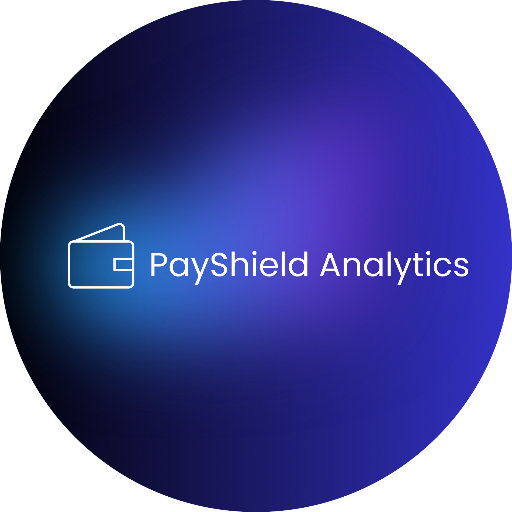




O dataset **Digital Payment Fraud Detection** contém informações sobre transações digitais, incluindo valores, tipos de pagamento e indicadores de fraude (`fraud_label`). Ele reúne variáveis numéricas e categóricas e é ideal para análise exploratória, identificação de outliers e estudo de padrões de fraude antes de aplicar modelos preditivos.


In [ ]:
# Funcoes auxiliares

def style_df(df, title):
    print(f"\n{title}")
    return (
        df.style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#4a90e2'), ('color', 'white'), ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('border-bottom', '1px solid #ddd')]}
        ])
        .hide(axis='index')
    )


def detect_IQR_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 0.5 * IQR, Q3 + 0.5 * IQR
    return (col < lower) | (col > upper)


def is_binary(series):
    return set(series.dropna().unique()).issubset({0, 1})


def build_summary_table(df):
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    def mode_freq(series):
        mode_val = series.mode()
        return int((series == mode_val.iloc[0]).sum()) if len(mode_val) > 0 else 0

    num_sum = df[numerical_cols].describe().T[['min', '25%', '50%', '75%', 'max', 'mean', 'std']]
    num_sum['Moda'] = df[numerical_cols].mode().iloc[0]
    num_sum['Valores ausentes'] = df[numerical_cols].isna().sum()
    num_sum['% Missing'] = (num_sum['Valores ausentes'] / len(df) * 100).round(2)
    num_sum['Freq Moda'] = pd.Series({col: mode_freq(df[col]) for col in numerical_cols})
    num_sum['% Freq Moda'] = (num_sum['Freq Moda'] / len(df) * 100).round(2)
    num_sum['Tipo'] = df[numerical_cols].dtypes

    if len(categorical_cols) > 0:
        cat_sum = pd.DataFrame({
            'count': df[categorical_cols].count(),
            'unique': df[categorical_cols].nunique(),
            'Moda': df[categorical_cols].mode().iloc[0],
            'Freq Moda': df[categorical_cols].apply(lambda x: x.value_counts().max()),
            'Valores ausentes': df[categorical_cols].isna().sum(),
            '% Missing': (df[categorical_cols].isna().sum() / len(df) * 100).round(2),
            '% Freq Moda': (df[categorical_cols].apply(lambda x: x.value_counts().max()) / len(df) * 100).round(2),
            'Tipo': df[categorical_cols].dtypes
        })
        summary = pd.concat([num_sum, cat_sum], axis=0, sort=False)
    else:
        summary = num_sum

    return summary.sort_values('Valores ausentes', ascending=False)


def create_features(df):
    df = df.copy()
    # df['amount_vs_user_avg'] = (
    #     df['transaction_amount'] -
    #     df.groupby('user_id')['transaction_amount'].transform('mean')
    # )
    df['risk_login'] = df['login_attempts_last_24h'] * df['previous_failed_attempts']
    df['login_failure_rate'] = df['previous_failed_attempts'] / (df['login_attempts_last_24h'] + 1)
    df['is_night'] = (df['transaction_hour'] < 6).astype(int)
    df['international_risk'] = df['is_international'] * df['ip_risk_score']
    df['risk_interaction'] = (
        (df['is_night'] == 1) & (df['is_international'] == 1)
    ).astype(int)
    user_group = df.groupby('user_id')['transaction_amount']
    df['user_rolling_avg'] = user_group.expanding().mean().reset_index(level=0, drop=True)
    df['user_rolling_std'] = user_group.expanding().std().reset_index(level=0, drop=True).fillna(0)
    df['is_anomalous_amount'] = (
        df['transaction_amount'] > (df['user_rolling_avg'] + 2 * df['user_rolling_std'])
    ).astype(int)
    df['user_mean_expanding'] = user_group.expanding().mean().reset_index(level=0, drop=True)
    df['user_std_expanding'] = user_group.expanding().std().reset_index(level=0, drop=True)
    df['amount_zscore_safe'] = (
        (df['transaction_amount'] - df['user_mean_expanding']) /
        (df['user_std_expanding'] + 1e-6)
    )
    # df['user_failed_attempts_mean'] = (
    #     df.groupby('user_id')['previous_failed_attempts'].transform('mean')
    # )
    return df


def train_and_evaluate(X_train, X_test, y_train, y_test, pipeline, pipeline_name, threshold=0.3):
    #pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n{'='*55}")
    print(f"  {pipeline_name}  (threshold={threshold})")
    print(f"{'='*55}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitima', 'Fraude'],
                yticklabels=['Legitima', 'Fraude'])
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusao — {pipeline_name}')
    plt.tight_layout()
    plt.show()

    return pipeline, y_proba, y_pred

## 1. ⚙️ Configuração do Ambiente

Importação de bibliotecas, configuração do ambiente de visualização e carregamento do dataset.

### 1.1 Bibliotecas

- **pandas** e **numpy**: manipulação e operações numéricas.
- **matplotlib**, **seaborn** e **plotly**: visualizações estáticas e interativas.
- **scikit-learn**: modelos, métricas e pré-processamento.
- **imbalanced-learn (SMOTE)**: balanceamento de classes para o pipeline de Random Forest.
- **xgboost**: gradient boosting otimizado para conjuntos desbalanceados.

In [ ]:
# Manipulação de dados
import os
import pandas as pd
import numpy as np
import math

# Visualização
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

# Exibição
from IPython.display import display

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

### 1.2 Carregamento do Dataset

O dataset é baixado diretamente do Kaggle via `kagglehub` e lido como dataframe principal `df`, referência para toda a análise.

In [ ]:
# Carregando o dataset
import kagglehub

path = kagglehub.dataset_download("jayjoshi37/digital-payment-fraud-detection")
dataset_name = os.listdir(path)[0]

df = pd.read_csv(os.path.join(path, dataset_name))
new_treated_df = df.copy()

print("Path to dataset files:", path)

100%|██████████| 190k/190k [00:00<00:00, 16.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jayjoshi37/digital-payment-fraud-detection/versions/1


## 2. 📊 Análise Exploratória de Dados

Inspeção inicial do dataset: estrutura, tipos de variáveis, qualidade dos dados e distribuições. O objetivo é construir familiaridade com os dados antes de qualquer transformação.

### 2.1 Visão Geral do Dataset

Número de linhas, colunas, tipos de dados e amostra inicial das observações.

In [ ]:
# Informações gerais do dataset
payment_fraud_data = df
payment_fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 14  fraud_la

### 2.2 Tipos e Categorias das Variáveis

Identificação dos tipos de cada coluna e valores distintos nas variáveis categóricas.

In [ ]:
# Exibir os tipos de dados de cada coluna
payment_fraud_data.dtypes

,0
transaction_id,object
user_id,object
transaction_amount,float64
transaction_type,object
payment_mode,object
device_type,object
device_location,object
account_age_days,int64
transaction_hour,int64
previous_failed_attempts,int64


Os valores distintos nas variáveis categóricas foram mapeados para identificar os grupos disponíveis: tipos de transação, modalidades de pagamento e tipos de dispositivo.

In [ ]:
distinct_series = payment_fraud_data['transaction_type'].drop_duplicates()

# Criando um DataFrame de inspeção
df_info = pd.DataFrame({
    'Transaction Type': distinct_series.values,
    'Dtype': [distinct_series.dtype] * len(distinct_series)
}, index=distinct_series.index)

# 1. Distinct Payment Mode
distinct_pm = payment_fraud_data['payment_mode'].drop_duplicates()
df_pm = pd.DataFrame({
    'payment_mode': distinct_pm.values,
    'dtype': [distinct_pm.dtype] * len(distinct_pm)
}, index=distinct_pm.index)

# 2. Distinct Device Type
# Nota: .unique() retorna um array numpy, então não há índice original preservado
distinct_dt = payment_fraud_data['device_type'].unique()
df_dt = pd.DataFrame({
    'device_type': distinct_dt,
    'dtype': [distinct_dt.dtype] * len(distinct_dt)
})

# 3. Distinct Device Location
distinct_dl = payment_fraud_data['device_location'].unique()
df_dl = pd.DataFrame({
    'device_location': distinct_dl,
    'dtype': [distinct_dl.dtype] * len(distinct_dl)
})

# Aplicando para cada um
display(style_df(df_info, "Tabela: Tipos de Transações"))
display(style_df(df_pm, "Tabela: Tipo de Pagamento"))
display(style_df(df_dt, "Tabela: Tipo de Aparelho/SO"))
display(style_df(df_dl, "Tabela: Localização do Aparelho"))


Tabela: Tipos de Transações


Transaction Type,Dtype
Transfer,object
Payment,object
Withdrawal,object



Tabela: Tipo de Pagamento


payment_mode,dtype
UPI,object
Wallet,object
Card,object
NetBanking,object



Tabela: Tipo de Aparelho/SO


device_type,dtype
Web,object
iOS,object
Android,object



Tabela: Localização do Aparelho


device_location,dtype
Hyderabad,object
Chennai,object
Delhi,object
Mumbai,object
Bangalore,object


### 2.3 Amostragem Inicial

Exibição das primeiras e últimas linhas do dataset para verificar a estrutura, presença de valores esperados e possíveis inconsistências. O total de linhas e colunas é apresentado como referência.


In [ ]:
# Obtendo o número de linhas do dataset
print(f"Dataset possui {payment_fraud_data.shape[0]} linhas e {payment_fraud_data.shape[1]} colunas.")
# Visualizar as cinco primeiras linhas do dataset
display(style_df(payment_fraud_data.head(5), "Tabela: Cinco primeiras linhas"))

# Últimos três registros
display(style_df(payment_fraud_data.tail(3), "Tabela: Tres ultimas linhas"))



Dataset possui 7500 linhas e 15 colunas.

Tabela: Cinco primeiras linhas


transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
T1,U3756,18758.280000,Transfer,UPI,Web,Hyderabad,895,14,1,25535.840000,0,0.718000,4,0
T2,U7899,47538.180000,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.850000,0,0.525000,9,0
T3,U1765,36613.100000,Payment,Card,Android,Chennai,1506,8,4,22727.710000,0,0.985000,9,0
T4,U8850,29952.990000,Payment,Wallet,iOS,Chennai,800,1,3,18095.890000,0,0.797000,2,0
T5,U9049,7843.130000,Payment,UPI,Web,Delhi,301,4,1,9317.490000,1,0.468000,1,0



Tabela: Tres ultimas linhas


transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
T7498,U6605,42523.370000,Withdrawal,NetBanking,Android,Chennai,67,19,1,27344.690000,0,0.149000,6,0
T7499,U5956,10681.860000,Withdrawal,UPI,Web,Hyderabad,282,15,2,26586.500000,0,0.198000,2,0
T7500,U1367,33454.230000,Transfer,Wallet,Android,Delhi,1231,3,3,19974.410000,0,0.547000,5,0


### 2.4 Qualidade dos Dados

Verificação de valores ausentes, registros duplicados e cardinalidade por coluna.

#### 2.4.1 Valores Ausentes

Contagem de valores nulos por coluna. Colunas com alta proporção de ausentes exigem tratamento antes da modelagem.

In [ ]:
# Contar valores ausentes por coluna
payment_fraud_data.isnull().sum()

,0
transaction_id,0
user_id,0
transaction_amount,0
transaction_type,0
payment_mode,0
device_type,0
device_location,0
account_age_days,0
transaction_hour,0
previous_failed_attempts,0


#### 2.4.2 Registros Duplicados

Verificação de linhas idênticas. Duplicatas podem inflar métricas de treino e introduzir viés.

In [ ]:
duplicados = df[df.duplicated(keep=False)]

if duplicados.empty:
    print("Não existem linhas duplicadas no dataset.")
else:
    print("Grupos de linhas duplicadas:\n")
    print(duplicados.value_counts())

Não existem linhas duplicadas no dataset.


#### 2.4.3 Valores Únicos por Coluna

Cardinalidade de cada coluna. Identifica variáveis de alta cardinalidade (como IDs) que devem ser excluídas da modelagem.

In [ ]:
#Calcula a quantidade de valores únicos em cada coluna do DataFrame.
df.nunique()

,0
transaction_id,7500
user_id,5106
transaction_amount,7499
transaction_type,3
payment_mode,4
device_type,3
device_location,5
account_age_days,1943
transaction_hour,24
previous_failed_attempts,5


## 3. 📈 Estatística Descritiva

A análise descritiva foi aplicada às variáveis numéricas do dataset com o objetivo de compreender sua distribuição, variabilidade e possíveis padrões relevantes.

O dataset contém 7.500 registros. De forma geral, observa-se que algumas variáveis apresentam média e mediana próximas, indicando distribuições relativamente simétricas, enquanto outras demonstram maior dispersão, evidenciada pelo desvio padrão elevado.

Também foram identificados valores extremos (outliers), principalmente em variáveis relacionadas a valores monetários, o que é esperado em dados financeiros.

A variável alvo (`fraud_label`) apresenta forte desbalanceamento, com aproximadamente 6,5% dos registros classificados como fraude, o que deve ser considerado na etapa de modelagem.

In [ ]:
# Selecionando colunas numéricas
num_cols = payment_fraud_data.select_dtypes(include=['int64', 'float64']).columns

# Estatísticas descritivas
desc_stats = payment_fraud_data[num_cols].describe().T

# Adicionando mediana e moda
desc_stats["median"] = payment_fraud_data[num_cols].median()
desc_stats["mode"] = payment_fraud_data[num_cols].mode().iloc[0]

display(style_df(desc_stats, "Estatísticas Descritivas"))


Estatísticas Descritivas


count,mean,std,min,25%,50%,75%,max,median,mode
7500.000000,24813.534161,14434.742371,50.580000,12272.785000,24715.550000,37288.375000,49985.900000,24715.550000,36588.250000
7500.000000,1006.904533,575.632925,10.000000,502.750000,1018.000000,1505.000000,1999.000000,1018.000000,1018.000000
7500.000000,11.435867,6.950899,0.000000,5.000000,11.000000,18.000000,23.000000,11.000000,3.000000
7500.000000,2.013600,1.421578,0.000000,1.000000,2.000000,3.000000,4.000000,2.000000,4.000000
7500.000000,15129.061027,8597.760720,102.790000,7725.842500,15074.810000,22573.062500,29994.290000,15074.810000,2121.880000
7500.000000,0.100667,0.300907,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
7500.000000,0.505026,0.289647,0.000000,0.257000,0.502000,0.759000,1.000000,0.502000,0.171000
7500.000000,4.995067,2.593879,1.000000,3.000000,5.000000,7.000000,9.000000,5.000000,1.000000
7500.000000,0.065200,0.246895,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


### 3.1 Dispersão (Variabilidade e Outliers)

Nesta etapa, foram analisadas as medidas de dispersão das variáveis numéricas, utilizando o desvio padrão (std) e o intervalo interquartil (IQR), com o objetivo de avaliar a variabilidade dos dados e identificar possíveis valores atípicos.

Observa-se que algumas variáveis apresentam desvio padrão elevado, indicando grande dispersão dos dados em relação à média. Esse comportamento sugere a presença de diferentes perfis de transações, com valores bastante heterogêneos.

O IQR também apresenta valores altos em determinadas variáveis, o que reforça a existência de ampla variação no intervalo central dos dados. Essa característica é comum em datasets financeiros e pode estar associada tanto a padrões legítimos quanto a comportamentos anômalos.

Embora os outliers não tenham sido isolados individualmente nesta etapa, os resultados indicam forte indício de valores extremos, o que justifica a aplicação de métodos específicos de detecção de anomalias em etapas futuras da análise.

In [ ]:
# Desvio padrão e IQR
std = payment_fraud_data[num_cols].std()
q1 = payment_fraud_data[num_cols].quantile(0.25)
q3 = payment_fraud_data[num_cols].quantile(0.75)
iqr = q3 - q1

dispersion_df = pd.DataFrame({
    "std": std,
    "IQR": iqr
})

display(style_df(dispersion_df, "Medidas de Dispersão"))


Medidas de Dispersão


std,IQR
14434.742371,25015.590000
575.632925,1002.250000
6.950899,13.000000
1.421578,2.000000
8597.760720,14847.220000
0.300907,0.000000
0.289647,0.502000
2.593879,4.000000
0.246895,0.000000


### 3.2 Histogramas (Distribuição dos Dados)

Os histogramas mostram a distribuição das variáveis do dataset, permitindo analisar o comportamento geral dos dados.

Observa-se que variáveis como `transaction_amount` e `avg_transaction_amount` apresentam alta dispersão, sem concentração clara em um único intervalo. Já variáveis discretas, como `previous_failed_attempts` e `login_attempts_last_24h`, possuem distribuição em valores inteiros, como esperado.

As variáveis binárias (`is_international` e `fraud_label`) apresentam forte desbalanceamento, com predominância da classe 0.

De forma geral, os dados apresentam alta variabilidade e ausência de distribuições claramente normais, além de um forte desbalanceamento na variável alvo, o que é característico de problemas de detecção de fraude.

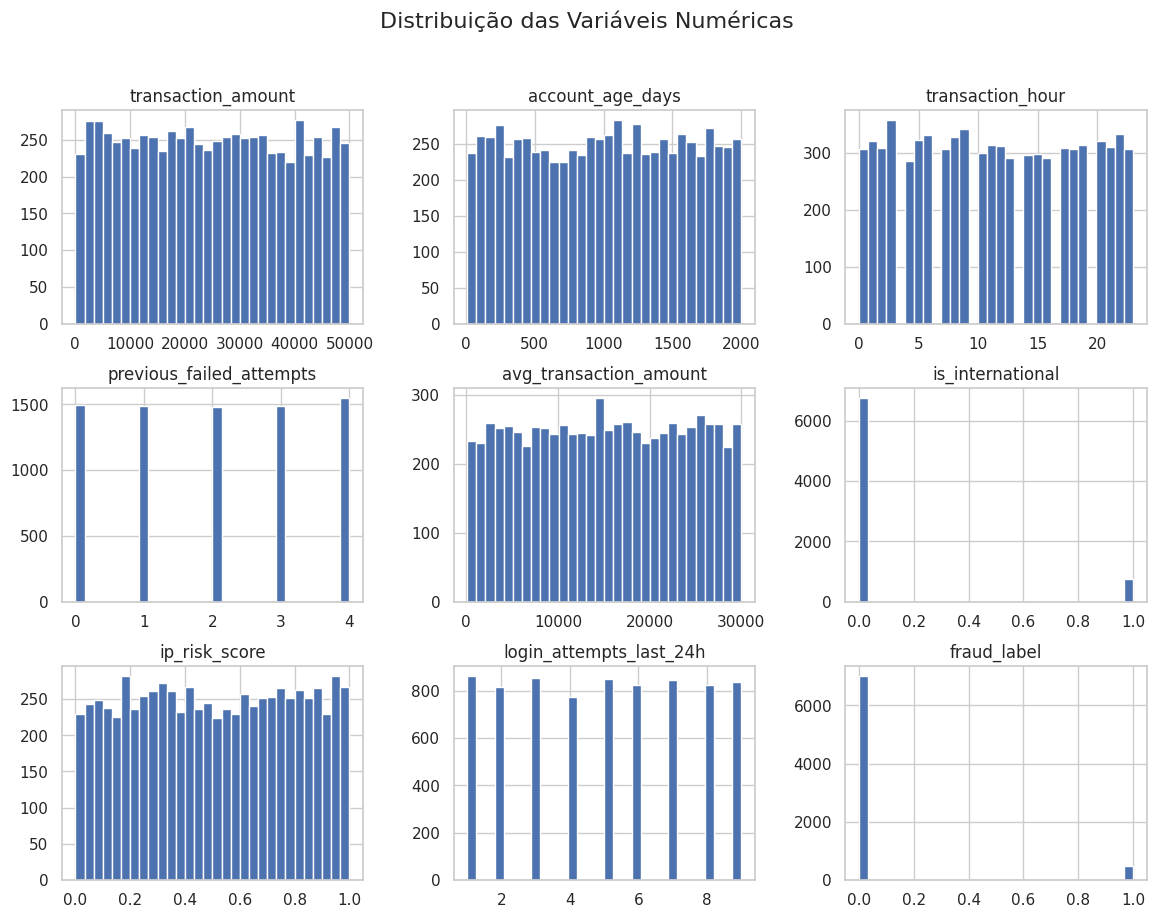

In [ ]:
payment_fraud_data[num_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.show()

### 3.3 Boxplots (Detecção de Outliers)

Os boxplots foram utilizados para identificar possíveis outliers e analisar a dispersão das variáveis numéricas.

Observa-se que variáveis como `transaction_amount` e `avg_transaction_amount` apresentam grande amplitude, porém sem presença clara de outliers extremos, indicando uma distribuição contínua dos valores.

Já variáveis binárias, como `is_international` e `fraud_label`, apresentam pontos isolados, o que é esperado devido ao desbalanceamento entre as classes.

Além disso, algumas variáveis com escalas menores aparecem achatadas no gráfico, dificultando a visualização de possíveis variações devido à diferença de magnitude entre as variáveis.

De forma geral, não foram identificados outliers extremos evidentes nas variáveis monetárias, sugerindo dados relativamente consistentes, embora a análise visual seja limitada pela diferença de escala entre as variáveis.

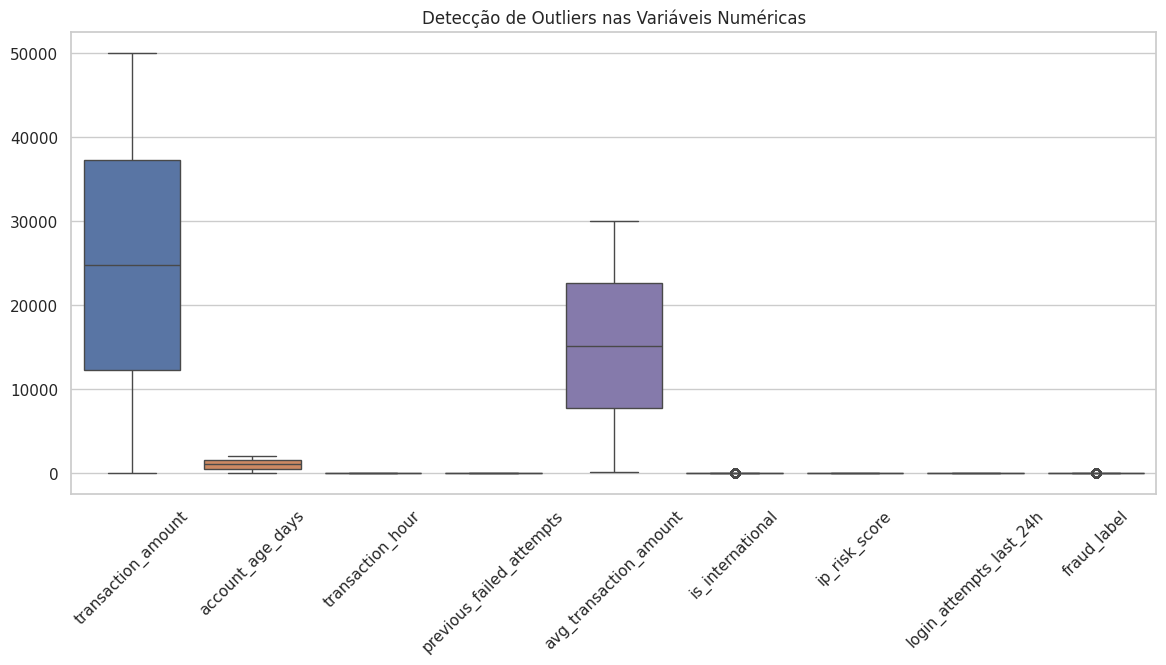

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=payment_fraud_data[num_cols])
plt.xticks(rotation=45)
plt.title("Detecção de Outliers nas Variáveis Numéricas")
plt.show()

## 4. 🚨 Detecção Estatística de Outliers (IQR e Percentis)



Nesta etapa, foi realizada uma análise estatística complementar para identificação de outliers, utilizando o método do intervalo interquartil (IQR) e estatísticas baseadas em percentis.

Além da separação entre variáveis numéricas e categóricas, foram analisados percentis extremos (1%, 5%, 95% e 99%) para compreender melhor a distribuição dos dados.

Em seguida, aplicou-se o método IQR para quantificar e sumarizar a presença de valores atípicos em cada variável numérica, permitindo uma análise mais robusta do que a observação visual dos boxplots.

### 4.1 Identificando colunas numéricas e categóricas

In [ ]:
# 1. Identificando as colunas
numerical_cols = payment_fraud_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = payment_fraud_data.select_dtypes(include=['object']).columns.tolist()

# 2. Criando DataFrames independentes
df_num_cols = pd.DataFrame(numerical_cols, columns=['Colunas Numéricas'])
df_cat_cols = pd.DataFrame(categorical_cols, columns=['Colunas Categóricas'])

# 3. Exibindo os resultados
print("Resumo de Variáveis Numéricas:")
display(df_num_cols)

print("\nResumo de Variáveis Categóricas:")
display(df_cat_cols)

Resumo de Variáveis Numéricas:


,Colunas Numéricas
0,transaction_amount
1,account_age_days
2,transaction_hour
3,previous_failed_attempts
4,avg_transaction_amount
5,is_international
6,ip_risk_score
7,login_attempts_last_24h
8,fraud_label



Resumo de Variáveis Categóricas:


,Colunas Categóricas
0,transaction_id
1,user_id
2,transaction_type
3,payment_mode
4,device_type
5,device_location


### 4.2 Estatística Descritiva com Percentis (1%, 5%, 95%, 99%)

A análise das variáveis numéricas com percentis (1%, 5%, 95% e 99%) indica que as variáveis `transaction_amount` e `avg_transaction_amount` apresentam forte concentração nos valores superiores, com pouca diferença entre os percentis altos e o valor máximo, sugerindo possível saturação da escala.

A variável `ip_risk_score` apresenta maior dispersão ao longo da distribuição, sendo potencialmente mais informativa para detecção de anomalias.

As demais variáveis mostram baixa variabilidade ou comportamento discreto, com pouca evidência de caudas relevantes. No geral, os dados indicam que possíveis padrões de fraude estão concentrados em poucas variáveis contínuas, exigindo análises complementares.

In [ ]:
payment_fraud_data[numerical_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
1%,614.424500,29.990000,0.000000,0.000000,406.841700,0.000000,0.010000,1.000000,0.000000
5%,2618.390500,111.000000,1.000000,0.000000,1729.744000,0.000000,0.054000,1.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
95%,47506.038000,1903.050000,22.000000,4.000000,28499.850500,1.000000,0.955000,9.000000,1.000000
99%,49406.923100,1983.010000,23.000000,4.000000,29723.723100,1.000000,0.989000,9.000000,1.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


### 4.3 Detecção de Outliers (Análise Comparativa)


Nesta etapa, os outliers foram analisados utilizando o método do intervalo interquartil (IQR) em duas configurações distintas: o critério padrão (1.5×IQR) e uma abordagem mais sensível (0.5×IQR).

O objetivo dessa comparação é avaliar tanto outliers estatisticamente significativos quanto possíveis valores atípicos leves que poderiam indicar padrões anômalos em um contexto exploratório.

Com o critério padrão (1.5×IQR), não foram identificados outliers relevantes em algumas variáveis, indicando uma boa consistência dos dados segundo esse critério estatístico.

Já com o critério mais sensível (0.5×IQR), observa-se um aumento no número de valores classificados como outliers, o que evidencia maior sensibilidade na detecção de variações extremas leves.


#### 4.3.1  IQR padrão

In [ ]:
## 1. Função de detecção de outliers padrão(IQR)
def detect_IQR_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (col < lower) | (col > upper)


## 2. Identificação de colunas numéricas válidas
numerical_cols = payment_fraud_data.select_dtypes(include=['float64', 'int64']).columns

## 3. Função para identificar variáveis binárias
def is_binary(col):
    values = payment_fraud_data[col].dropna().unique()
    return set(values).issubset({0, 1})

## 4. Lista de colunas a excluir manualmente (IDs e variáveis não analíticas)
black_list = ['transaction_id', 'user_id']

## 5. Seleção final das colunas para IQR
iqr_cols = [
    col for col in numerical_cols
    if col not in black_list
    and not is_binary(col)
    and payment_fraud_data[col].nunique() > 1
]


## 6. Processamento de outliers
outlier_summary = []

for col in iqr_cols:
    mask = detect_IQR_outliers(payment_fraud_data[col])

    outlier_summary.append({
        'Coluna': col,
        'Count': int(mask.sum()),
        'Percentual (%)': round(mask.mean() * 100, 3),
        'Min Outlier': payment_fraud_data.loc[mask, col].min() if mask.any() else None,
        'Max Outlier': payment_fraud_data.loc[mask, col].max() if mask.any() else None
    })


## 7. Resultado final
outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Count', ascending=False)

print(f"📌 Foram analisadas {len(iqr_cols)} colunas após filtragem estatística.")
display(outlier_df.style.background_gradient(subset=['Count'], cmap='Reds'))

📌 Foram analisadas 7 colunas após filtragem estatística.


,Coluna,Count,Percentual (%),Min Outlier,Max Outlier
0,transaction_amount,0,0.000000,None,None
1,account_age_days,0,0.000000,None,None
2,transaction_hour,0,0.000000,None,None
3,previous_failed_attempts,0,0.000000,None,None
4,avg_transaction_amount,0,0.000000,None,None
5,ip_risk_score,0,0.000000,None,None
6,login_attempts_last_24h,0,0.000000,None,None


#### 4.3.2 IQR exploratório

A detecção de outliers foi realizada utilizando o método do intervalo interquartil (IQR), com fator de ajuste 0.5 em uma abordagem exploratória. Essa configuração torna a análise mais sensível a variações nos dados, em comparação ao critério padrão (1.5×IQR), aumentando a capacidade de identificar possíveis desvios, porém com maior suscetibilidade a falsos positivos.

Variáveis binárias e identificadores foram excluídos da análise, uma vez que o método IQR não é adequado para dados discretos restritos (0/1), podendo gerar classificações de outliers sem significado estatístico relevante.

Os resultados indicam baixa incidência de outliers nas variáveis contínuas analisadas. As variáveis relacionadas a valores transacionais e risco apresentam poucos registros classificados como atípicos sob o critério exploratório adotado, enquanto as demais variáveis não apresentam ocorrências significativas.

De forma geral, observa-se que os possíveis outliers estão concentrados em poucas variáveis contínuas, sugerindo que métodos complementares, como abordagens multivariadas ou baseadas em modelos, podem ser mais adequados para a identificação de padrões anômalos em problemas de detecção de fraude.

A análise foi realizada como etapa exploratória complementar à visualização por boxplots.

In [ ]:
## 1. Função de detecção de outliers explorátorio (IQR)
def detect_IQR_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 0.5 * IQR, Q3 + 0.5 * IQR
    return (col < lower) | (col > upper)


## 2. Identificação de colunas numéricas válidas
numerical_cols = payment_fraud_data.select_dtypes(include=['float64', 'int64']).columns

## 3. Função para identificar variáveis binárias
def is_binary(col):
    values = payment_fraud_data[col].dropna().unique()
    return set(values).issubset({0, 1})

## 4. Lista de colunas a excluir manualmente (IDs e variáveis não analíticas)
black_list = ['transaction_id', 'user_id']

## 5. Seleção final das colunas para IQR
iqr_cols = [
    col for col in numerical_cols
    if col not in black_list
    and not is_binary(col)
    and payment_fraud_data[col].nunique() > 1
]


## 6. Processamento de outliers
outlier_summary = []

for col in iqr_cols:
    mask = detect_IQR_outliers(payment_fraud_data[col])

    outlier_summary.append({
        'Coluna': col,
        'Count': int(mask.sum()),
        'Percentual (%)': round(mask.mean() * 100, 3),
        'Min Outlier': payment_fraud_data.loc[mask, col].min() if mask.any() else None,
        'Max Outlier': payment_fraud_data.loc[mask, col].max() if mask.any() else None
    })


## 7. Resultado final
outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Count', ascending=False)

print(f"📌 Foram analisadas {len(iqr_cols)} colunas após filtragem estatística.")
display(outlier_df.style.background_gradient(subset=['Count'], cmap='Reds'))

📌 Foram analisadas 7 colunas após filtragem estatística.


,Coluna,Count,Percentual (%),Min Outlier,Max Outlier
5,ip_risk_score,51,0.680000,0.000000,0.006000
4,avg_transaction_amount,42,0.560000,102.790000,292.280000
0,transaction_amount,29,0.387000,49808.080000,49985.900000
2,transaction_hour,0,0.000000,nan,nan
1,account_age_days,0,0.000000,nan,nan
3,previous_failed_attempts,0,0.000000,nan,nan
6,login_attempts_last_24h,0,0.000000,nan,nan


#### 4.3.3 Heatmap de Concentração de Outliers

Evidencia em quais colunas a concentração de outliers é maior.

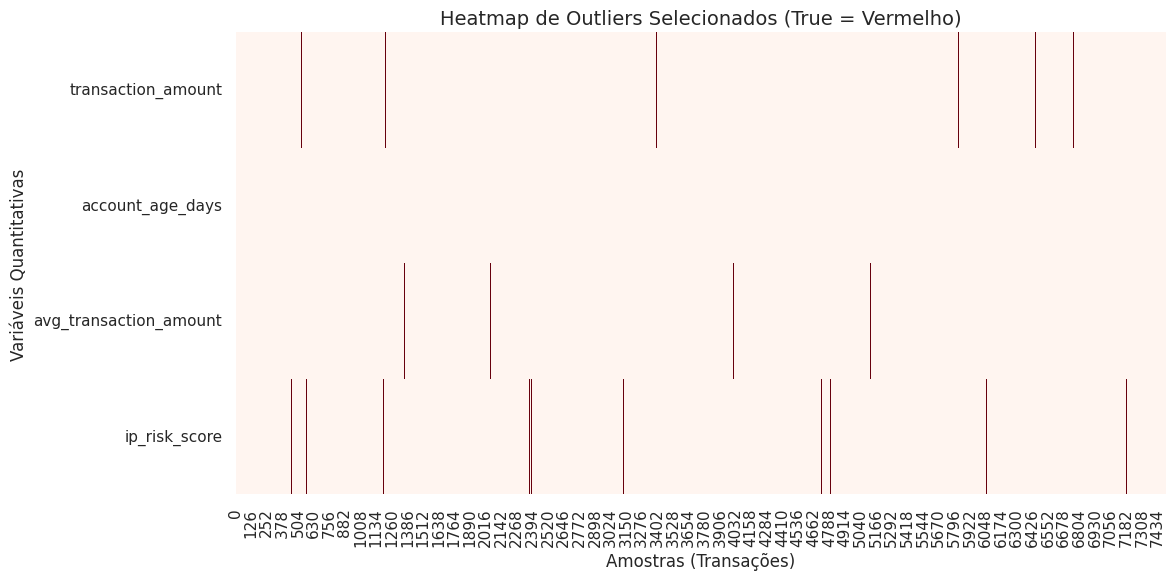

In [ ]:
# 1. Filtra as colunas que realmente devem ser analisadas
# Remove binárias e colunas com baixíssima variação (pouca cardinalidade)
iqr_viz_cols = [
    col for col in numerical_cols
    if not is_binary(col) and payment_fraud_data[col].nunique() > 15
]

# 2. Remove manualmente colunas cíclicas/IDs que não fazem sentido para IQR global
black_list = ['transaction_hour', 'transaction_id', 'user_id']
iqr_viz_cols = [col for col in iqr_viz_cols if col not in black_list]

# 3. Gera a matriz de outliers apenas para as colunas selecionadas
outlier_matrix = pd.DataFrame({
    col: detect_IQR_outliers(payment_fraud_data[col]) for col in iqr_viz_cols
})

# 4. Visualização com Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(outlier_matrix.T, cbar=False, cmap='Reds')
plt.title('Heatmap de Outliers Selecionados (True = Vermelho)', fontsize=14)
plt.xlabel('Amostras (Transações)')
plt.ylabel('Variáveis Quantitativas')
plt.show()

#### 4.3.4 Boxplots por Classe

Violinplot por `fraud_label` para comparar distribuição e posição dos outliers entre transações legítimas e fraudulentas.

A análise dos boxplots por classe revelou que as variáveis `amount_deviation` e `amount_ratio` possuem poder preditivo, com a classe de fraude apresentando medianas superiores e uma concentração de outliers significativamente mais extrema e "explosiva" em comparação às transações legítimas.

Contudo, observou-se uma sobreposição relevante entre as distribuições e uma elevada incidência de outliers na classe legítima, o que indica que desvios de valor isolados podem gerar falsos positivos. Além disso, a semelhança visual entre as métricas sugere uma forte correlação, tornando-as potencialmente redundantes para o modelo.

Embora as features capturem a natureza anómala das fraudes, a complexidade e a assimetria dos dados reforçam a necessidade de modelos não lineares, como o XGBoost, capazes de integrar estas variáveis com outros atributos contextuais para distinguir comportamentos atípicos legítimos de tentativas reais de fraude.

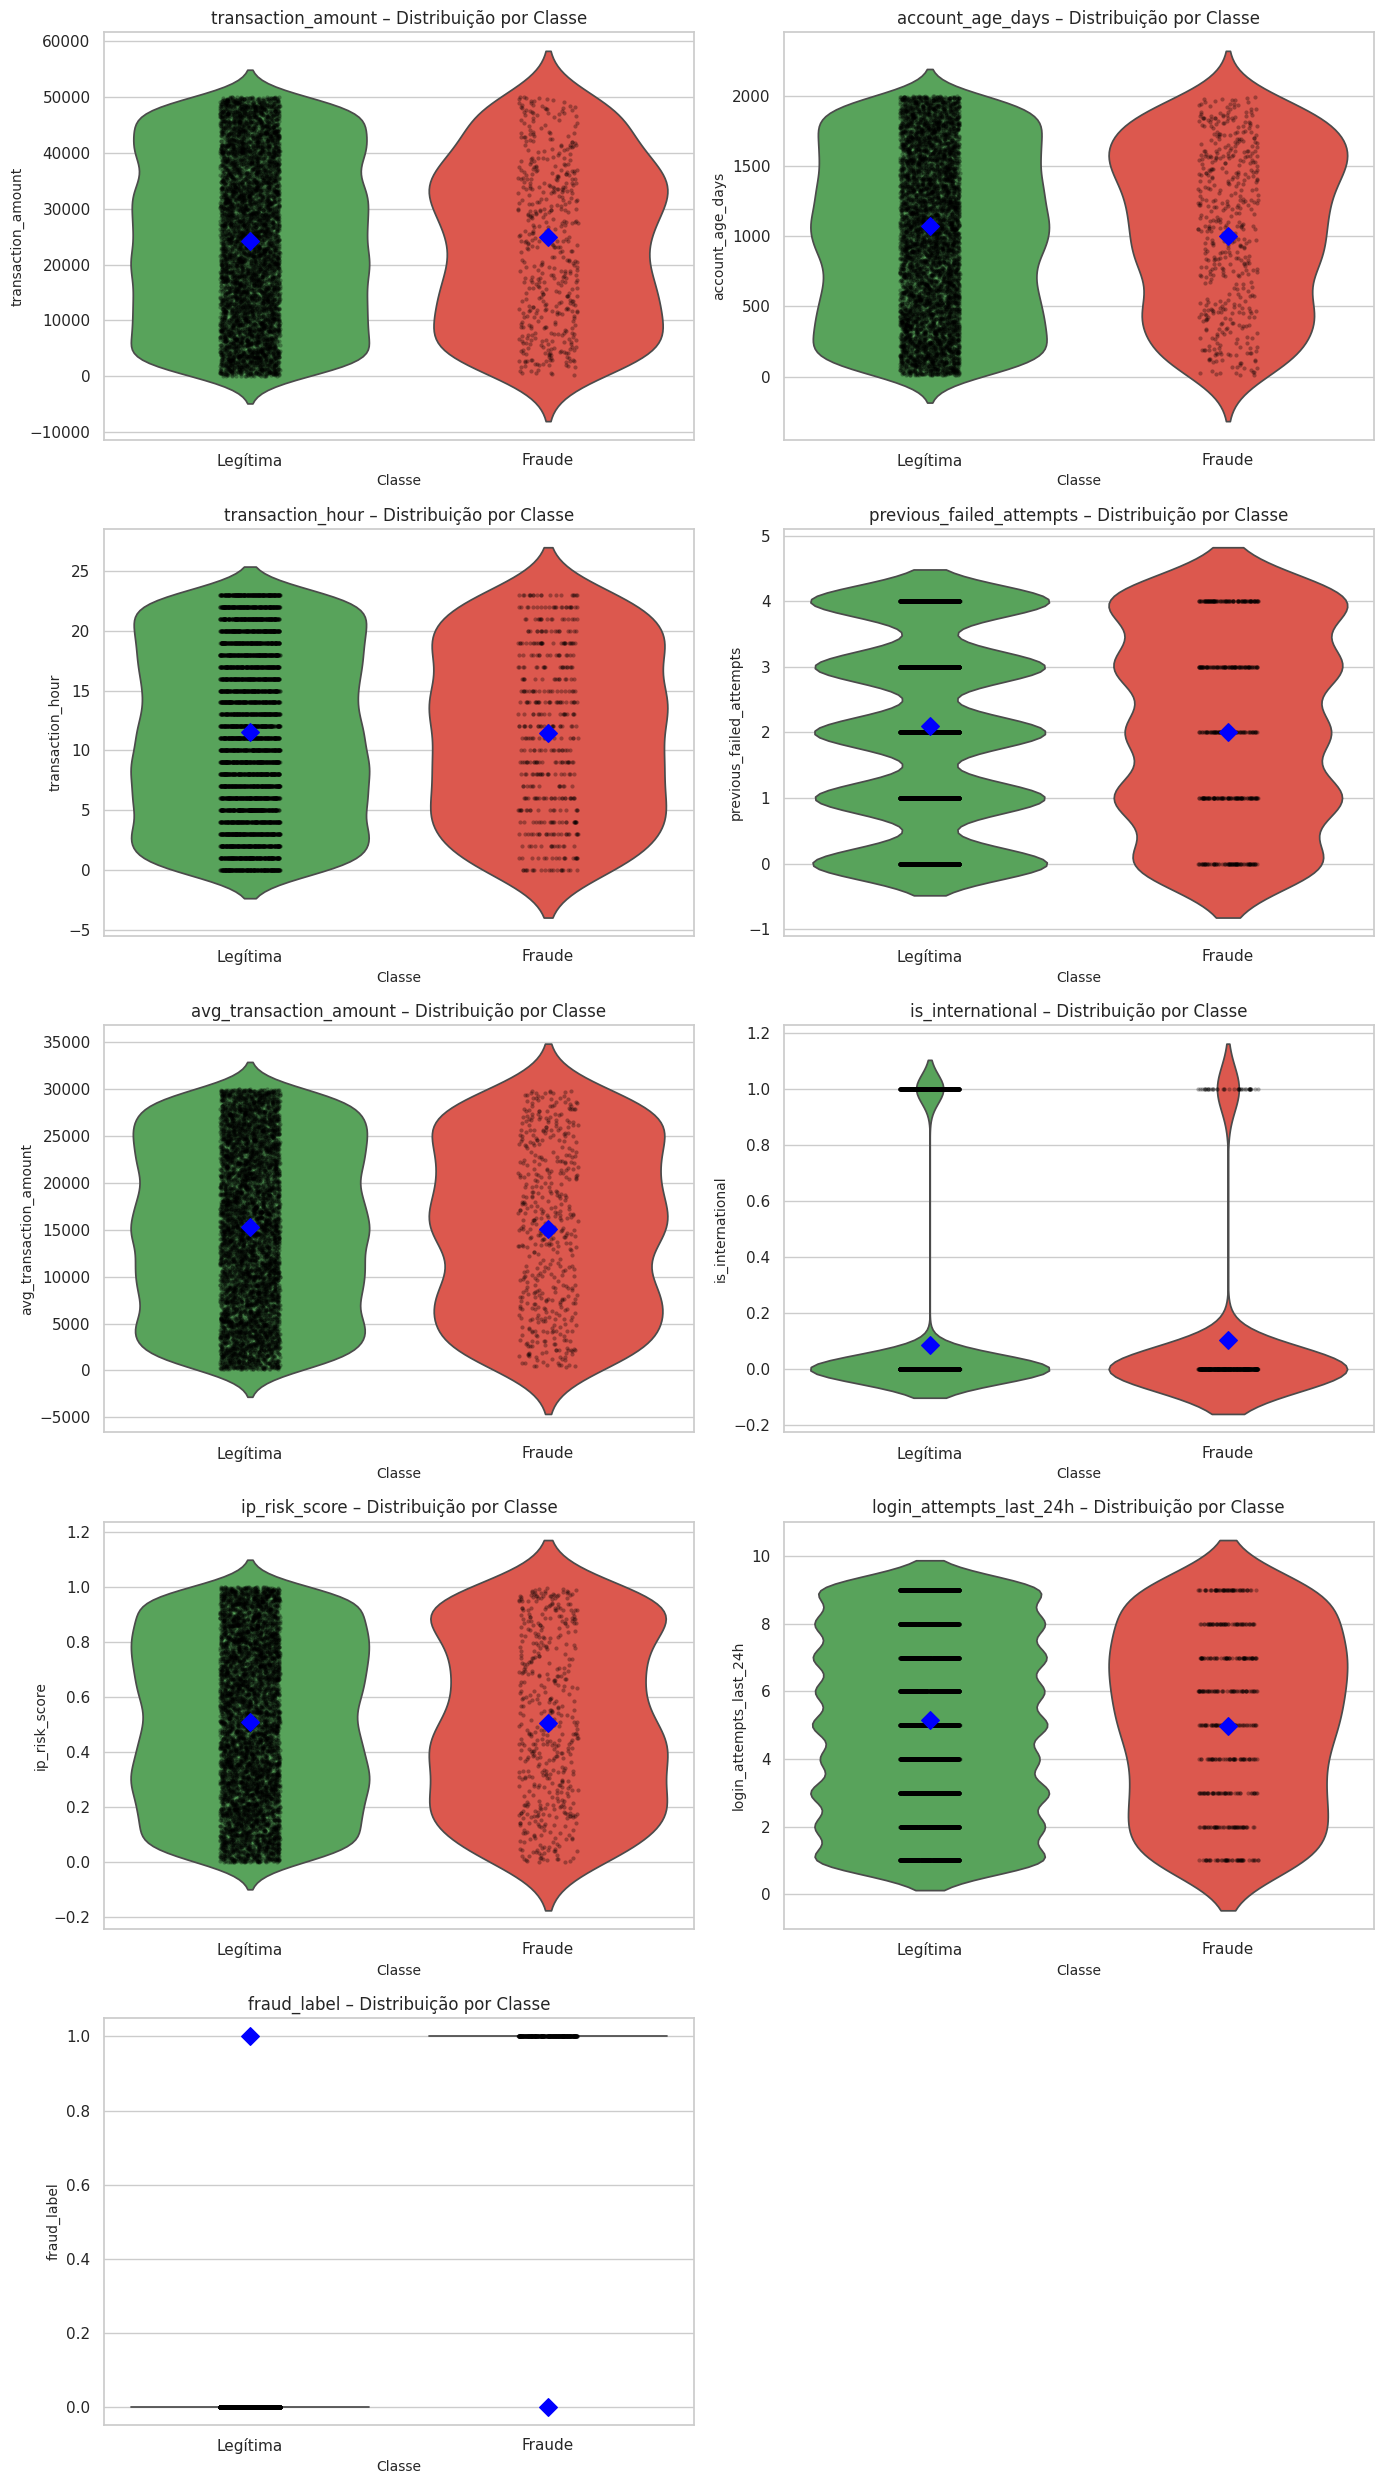

In [ ]:
if 'fraud_label' in new_treated_df.columns:
    cols_per_row = 2
    rows = int(np.ceil(len(numerical_cols)/cols_per_row))
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(7*cols_per_row, 5*rows))
    axes = axes.flatten()

    # Mapear para rótulos claros
    label_map = {0: 'Legítima', 1: 'Fraude'}
    new_treated_df['fraud_label_name'] = new_treated_df['fraud_label'].map(label_map)

    palette = {'Legítima': '#4CAF50', 'Fraude': '#F44336'}

    for ax, col in zip(axes, numerical_cols):
        # Violinplot principal
        sns.violinplot(
            x='fraud_label_name',
            y=col,
            data=new_treated_df,
            hue='fraud_label_name',
            palette=palette,
            dodge=False,
            inner=None,   # remove linhas internas para focar na densidade
            ax=ax
        )

        # Sobrepor pontos individuais
        sns.stripplot(
            x='fraud_label_name',
            y=col,
            data=new_treated_df,
            color='black',
            size=3,
            alpha=0.3,
            ax=ax
        )

        # Adicionar média da classe
        means = new_treated_df.groupby('fraud_label_name')[col].mean()
        for i, label_name in enumerate(means.index):
            ax.scatter(i, means[label_name], color='blue', s=80, marker='D', zorder=5)

        ax.set_title(f'{col} – Distribuição por Classe', fontsize=12)
        ax.set_xlabel('Classe', fontsize=10)
        ax.set_ylabel(col, fontsize=10)

    # Remove eixos vazios
    for ax in axes[len(numerical_cols):]:
        ax.remove()

    plt.tight_layout()
    plt.show()



#### 4.3.5 Tabela de Outliers por Classe

Quantificação dos outliers separados por classe para verificar se a incidência de valores atípicos difere entre legítimas e fraudulentas.

📌 Outliers por Classe (Legítima vs Fraude):


Classe,Fraude,Legítima
Coluna,,
account_age_days,11,24
avg_transaction_amount,0,59
fraud_label,0,0
ip_risk_score,0,47
is_international,41,714
login_attempts_last_24h,0,0
previous_failed_attempts,0,0
transaction_amount,20,0
transaction_hour,0,0


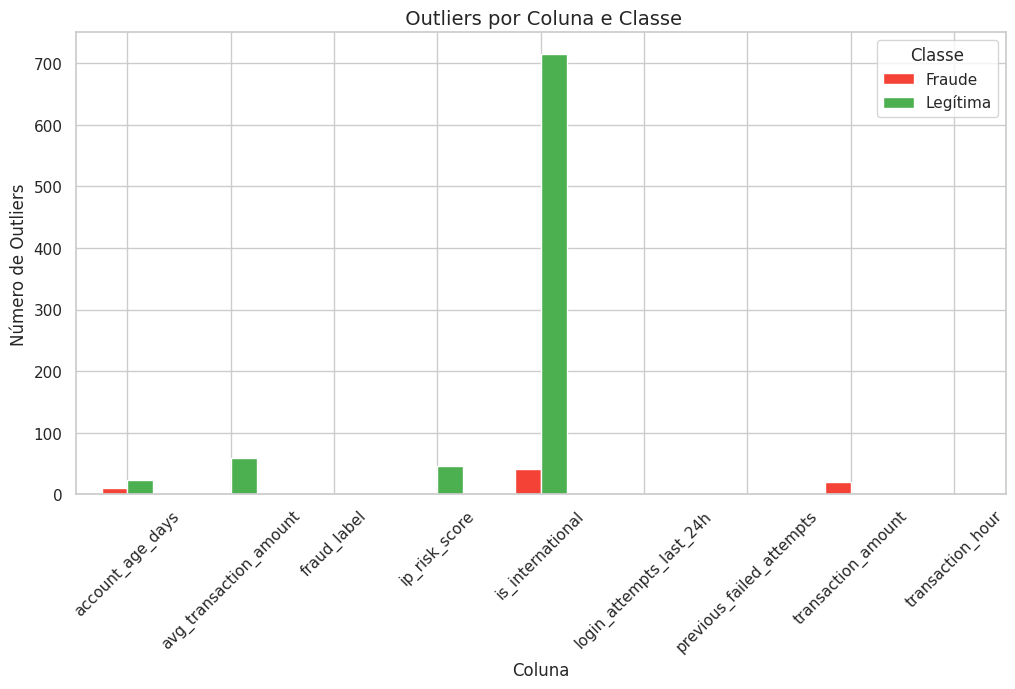

In [ ]:
if 'fraud_label' in new_treated_df.columns:
    class_outliers = []
    for col in numerical_cols:
        for label in new_treated_df['fraud_label'].unique():
            df_sub = new_treated_df[new_treated_df['fraud_label']==label]
            mask = detect_IQR_outliers(df_sub[col])
            class_outliers.append({
                'Coluna': col,
                'Classe': 'Fraude' if label==1 else 'Legítima',
                'Count': mask.sum(),
                'Percentual (%)': mask.mean()*100
            })
    class_outlier_df = pd.DataFrame(class_outliers)

    pivot_df = class_outlier_df.pivot(index='Coluna', columns='Classe', values='Count').fillna(0)
    print("📌 Outliers por Classe (Legítima vs Fraude):")
    display(pivot_df.style.background_gradient(cmap='Reds'))

    pivot_df.plot(kind='bar', figsize=(12,6), color=['#F44336','#4CAF50'])
    plt.title(' Outliers por Coluna e Classe', fontsize=14)
    plt.xlabel('Coluna', fontsize=12)
    plt.ylabel('Número de Outliers', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()

Outliers por feature e classe (desvio relativo):



Classe,Fraude,Legitima
Feature,,
amount_deviation,72,1085
amount_ratio,85,1228


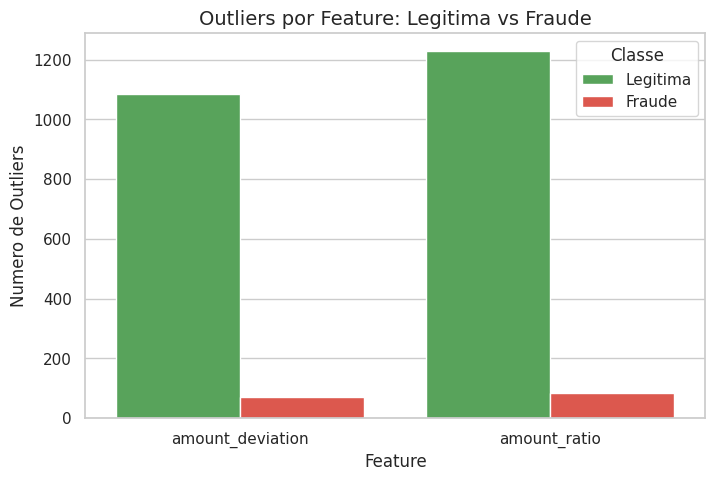

In [ ]:
# Analise de outliers nas features de desvio por usuario
df_deviant_features = new_treated_df.copy()
df_deviant_features['amount_deviation'] = df['transaction_amount'] - df['avg_transaction_amount']
df_deviant_features['amount_ratio'] = df['transaction_amount'] / (df['avg_transaction_amount'] + 1)

features_outlier = ['amount_deviation', 'amount_ratio']
resumo_outliers = []

for feature in features_outlier:
    for label, label_name in [(0, 'Legitima'), (1, 'Fraude')]:
        df_sub = df_deviant_features[df_deviant_features['fraud_label'] == label]
        mask = detect_IQR_outliers(df_sub[feature])
        resumo_outliers.append({
            'Feature': feature,
            'Classe': label_name,
            'Count': mask.sum(),
            'Percentual (%)': mask.mean() * 100
        })

resumo_df = pd.DataFrame(resumo_outliers)

print('Outliers por feature e classe (desvio relativo):\n')
display(resumo_df.pivot(index='Feature', columns='Classe', values='Count'))

plt.figure(figsize=(8, 5))
sns.barplot(x='Feature', y='Count', hue='Classe', data=resumo_df,
            palette=['#4CAF50', '#F44336'])
plt.title('Outliers por Feature: Legitima vs Fraude', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Numero de Outliers')
plt.legend(title='Classe')
plt.show()

#### 4.3.6 Análise de Outliers Segmentada por Contexto (Payment Mode & Type)
Esta análise detalha como as variáveis de desvio financeiro (amount_deviation e amount_ratio) se comportam dentro de nichos específicos de operação. Em vez de uma média global, o "corte" do outlier agora respeita o comportamento típico de cada canal de transação.

A análise estatística de detecção de outliers via método IQR ($k=0.5$) evidenciou que as variáveis de desvio `(amount_deviation e amount_ratio`) apresentam um comportamento anômalo mais acentuado na classe de fraude (36,19%) em comparação às transações legítimas (23,10%).Embora o desvio de valor demonstre capacidade de separação — com uma incidência de outliers aproximadamente 13 pontos percentuais superior em casos de fraude — a presença de 23% de anomalias em transações verídicas sugere um alto potencial de ruído. Além disso, a paridade quase exata entre as métricas de deviation e ratio ratifica a existência de multicolinearidade, indicando redundância no uso simultâneo de ambos os atributos.Em suma, as variáveis capturam a natureza "explosiva" dos valores fraudulentos, mas a sobreposição de comportamentos atípicos legítimos exige que o modelo integre estas features a outros contextos (como modo de pagamento ou horário) para mitigar falsos positivos e refinar a precisão da classificação.

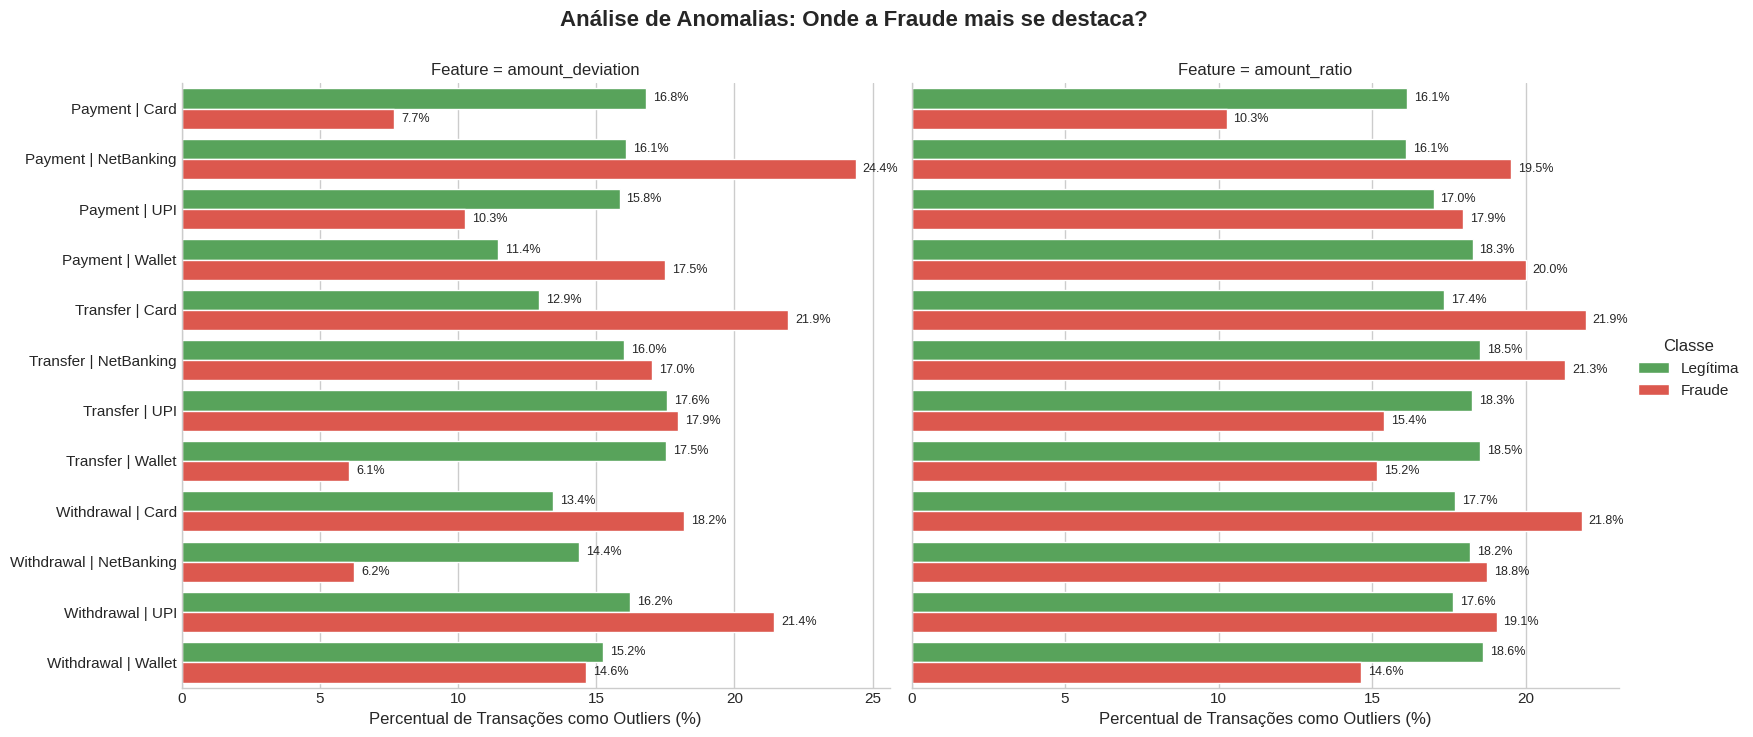

In [ ]:
# ==========================================
# 1️⃣ Reaproveitamento de Dados e Definições
# ==========================================

features_outlier = ['amount_deviation', 'amount_ratio']
resumo_outliers = []

# ==========================================
# 2️⃣ Cálculo das Proporções por Contexto
# ==========================================
for feature in features_outlier:
    for (t_type, p_mode), df_group in df_deviant_features.groupby(['transaction_type', 'payment_mode']):
        for label, label_name in [(0, 'Legítima'), (1, 'Fraude')]:
            df_sub = df_group[df_group['fraud_label'] == label]

            if not df_sub.empty:
                outliers_mask = detect_IQR_outliers(df_sub[feature])

                resumo_outliers.append({
                    'Feature': feature,
                    'Contexto': f"{t_type} | {p_mode}",
                    'Classe': label_name,
                    'Percentual (%)': round(outliers_mask.mean() * 100, 2)
                })

resumo_df = pd.DataFrame(resumo_outliers)

# ==========================================
# 3️⃣ Visualização Proporcional (Comparativo Final)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')

g = sns.catplot(
    data=resumo_df,
    kind="bar",
    x="Percentual (%)",
    y="Contexto",
    hue="Classe",
    col="Feature",
    palette={'Legítima': '#4CAF50', 'Fraude': '#F44336'},
    height=7,
    aspect=1.2,
    sharex=False
)

for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{width:.1f}%',
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=9, xytext=(5, 0),
                        textcoords='offset points')

g.fig.suptitle('Análise de Anomalias: Onde a Fraude mais se destaca?', y=1.05, fontsize=16, fontweight='bold')
g.set_axis_labels("Percentual de Transações como Outliers (%)", "")
plt.show()

#### 4.3.7 Assimetria das Distribuições

O coeficiente de skewness indica o desvio da distribuição em relação à simetria. Valores positivos indicam cauda à direita; negativos, cauda à esquerda.

In [ ]:
payment_fraud_data[iqr_cols].skew().sort_values(ascending=False)

,0
transaction_hour,0.025301
transaction_amount,0.020955
login_attempts_last_24h,-0.004068
ip_risk_score,-0.005669
avg_transaction_amount,-0.007374
previous_failed_attempts,-0.010044
account_age_days,-0.011704


### 4.4 Histogramas com Curva de Densidade

Distribuição de cada variável numérica com curva KDE para identificar forma, concentração e valores extremos.

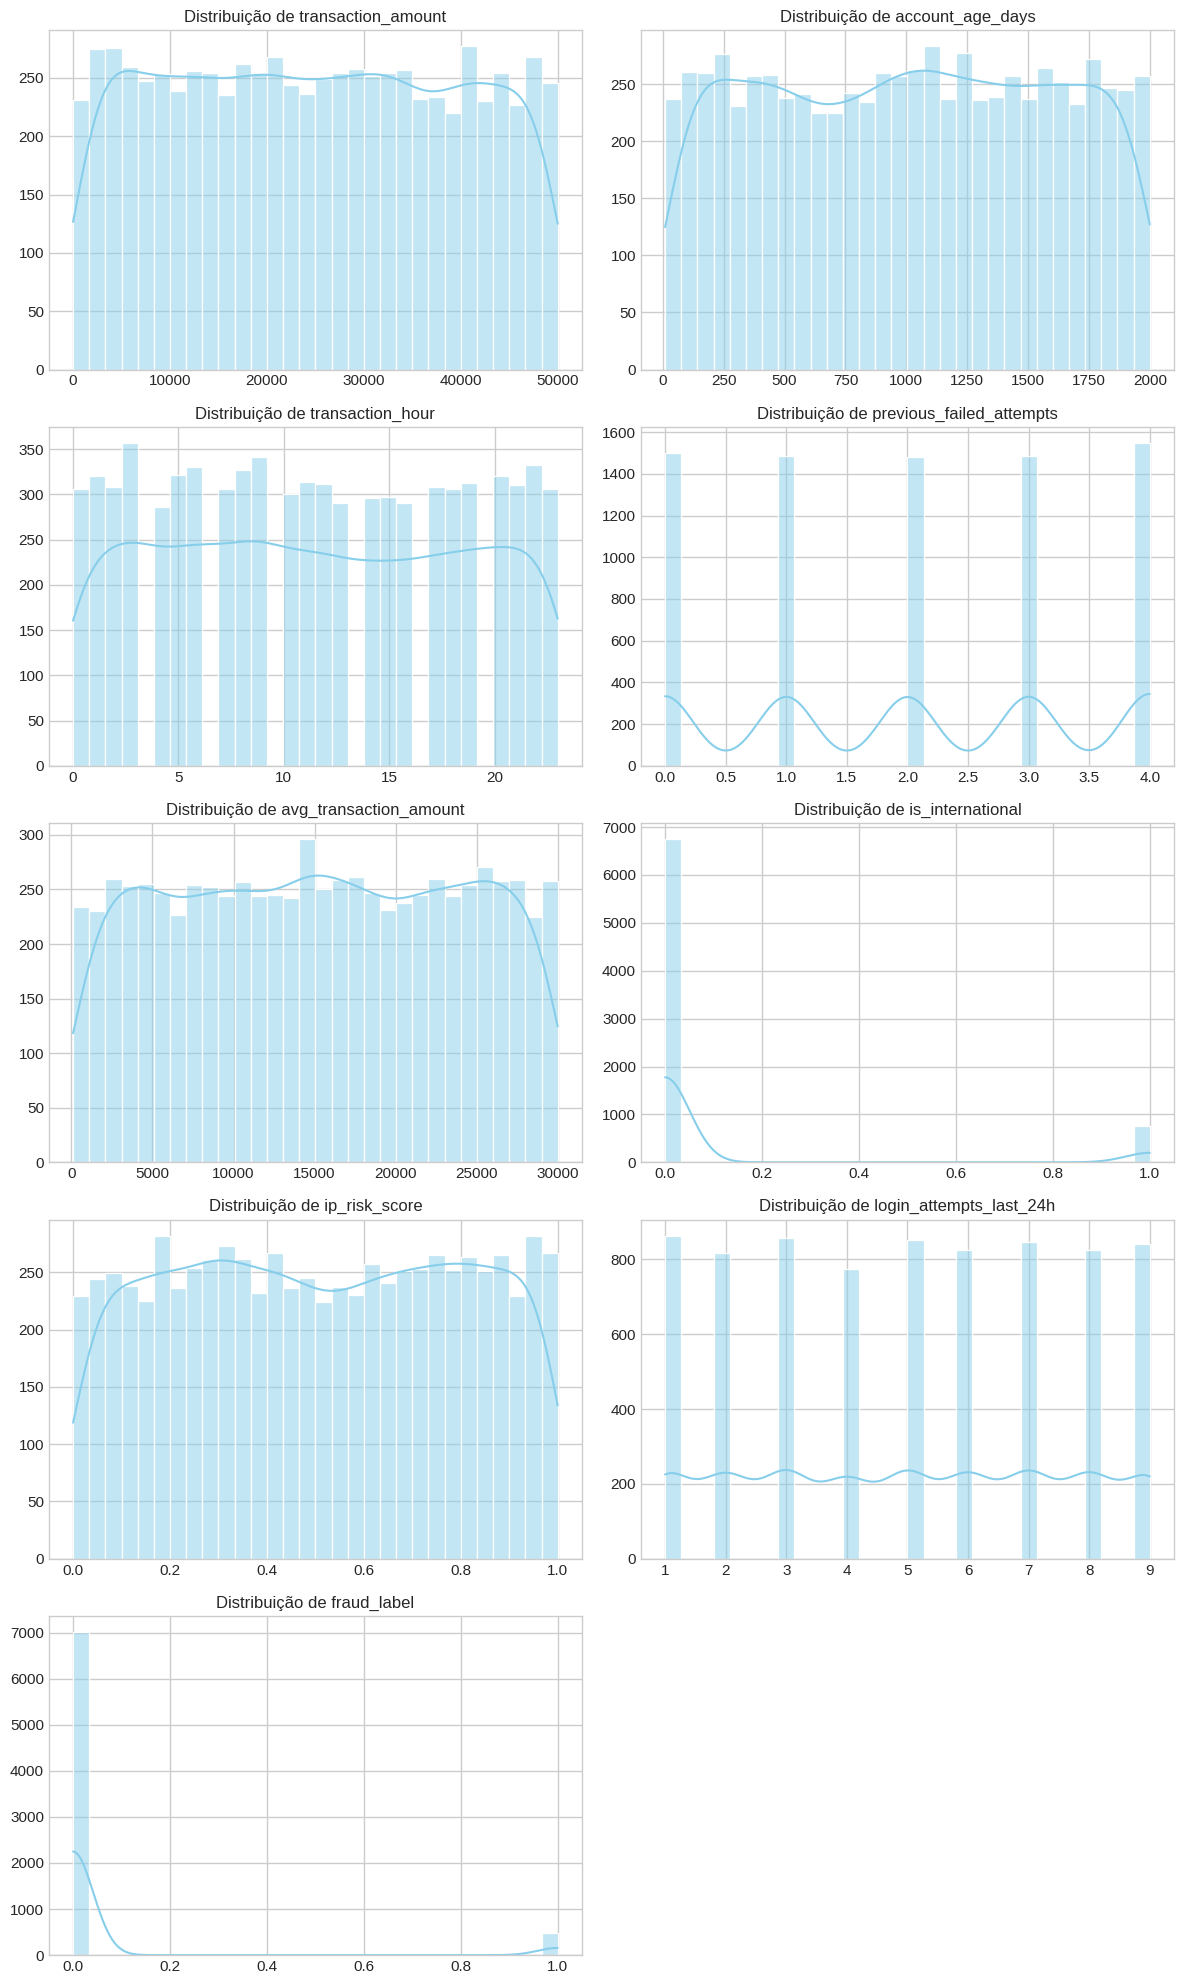

In [ ]:
# Visualização automática das distribuições das variáveis numéricas

# Número de colunas numéricas e configuração do layout
num_cols = len(numerical_cols)
cols_per_row = 2                     # Quantas colunas de gráficos por linha
rows = math.ceil(num_cols / cols_per_row)  # Calcula número de linhas necessárias

# Cria figura e eixos
fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(6*cols_per_row, 4*rows))
axes = axes.flatten()  # Facilita iterar sobre todos os subplots

# Criação de histogramas com KDE
for i, col in enumerate(numerical_cols):
    sns.histplot(
        new_treated_df[col],
        kde=True,          # adiciona curva KDE
        bins=30,           # número de bins
        color='skyblue',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_xlabel('')  # remove label x para visual mais limpo
    axes[i].set_ylabel('')  # remove label y para visual mais limpo

# Remove subplots extras se houver
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # ajusta automaticamente espaçamento
plt.show()

#### 4.4.1 Boxplots das Variáveis Numéricas

Mediana, quartis e outliers de cada variável numérica, complementando os histogramas.

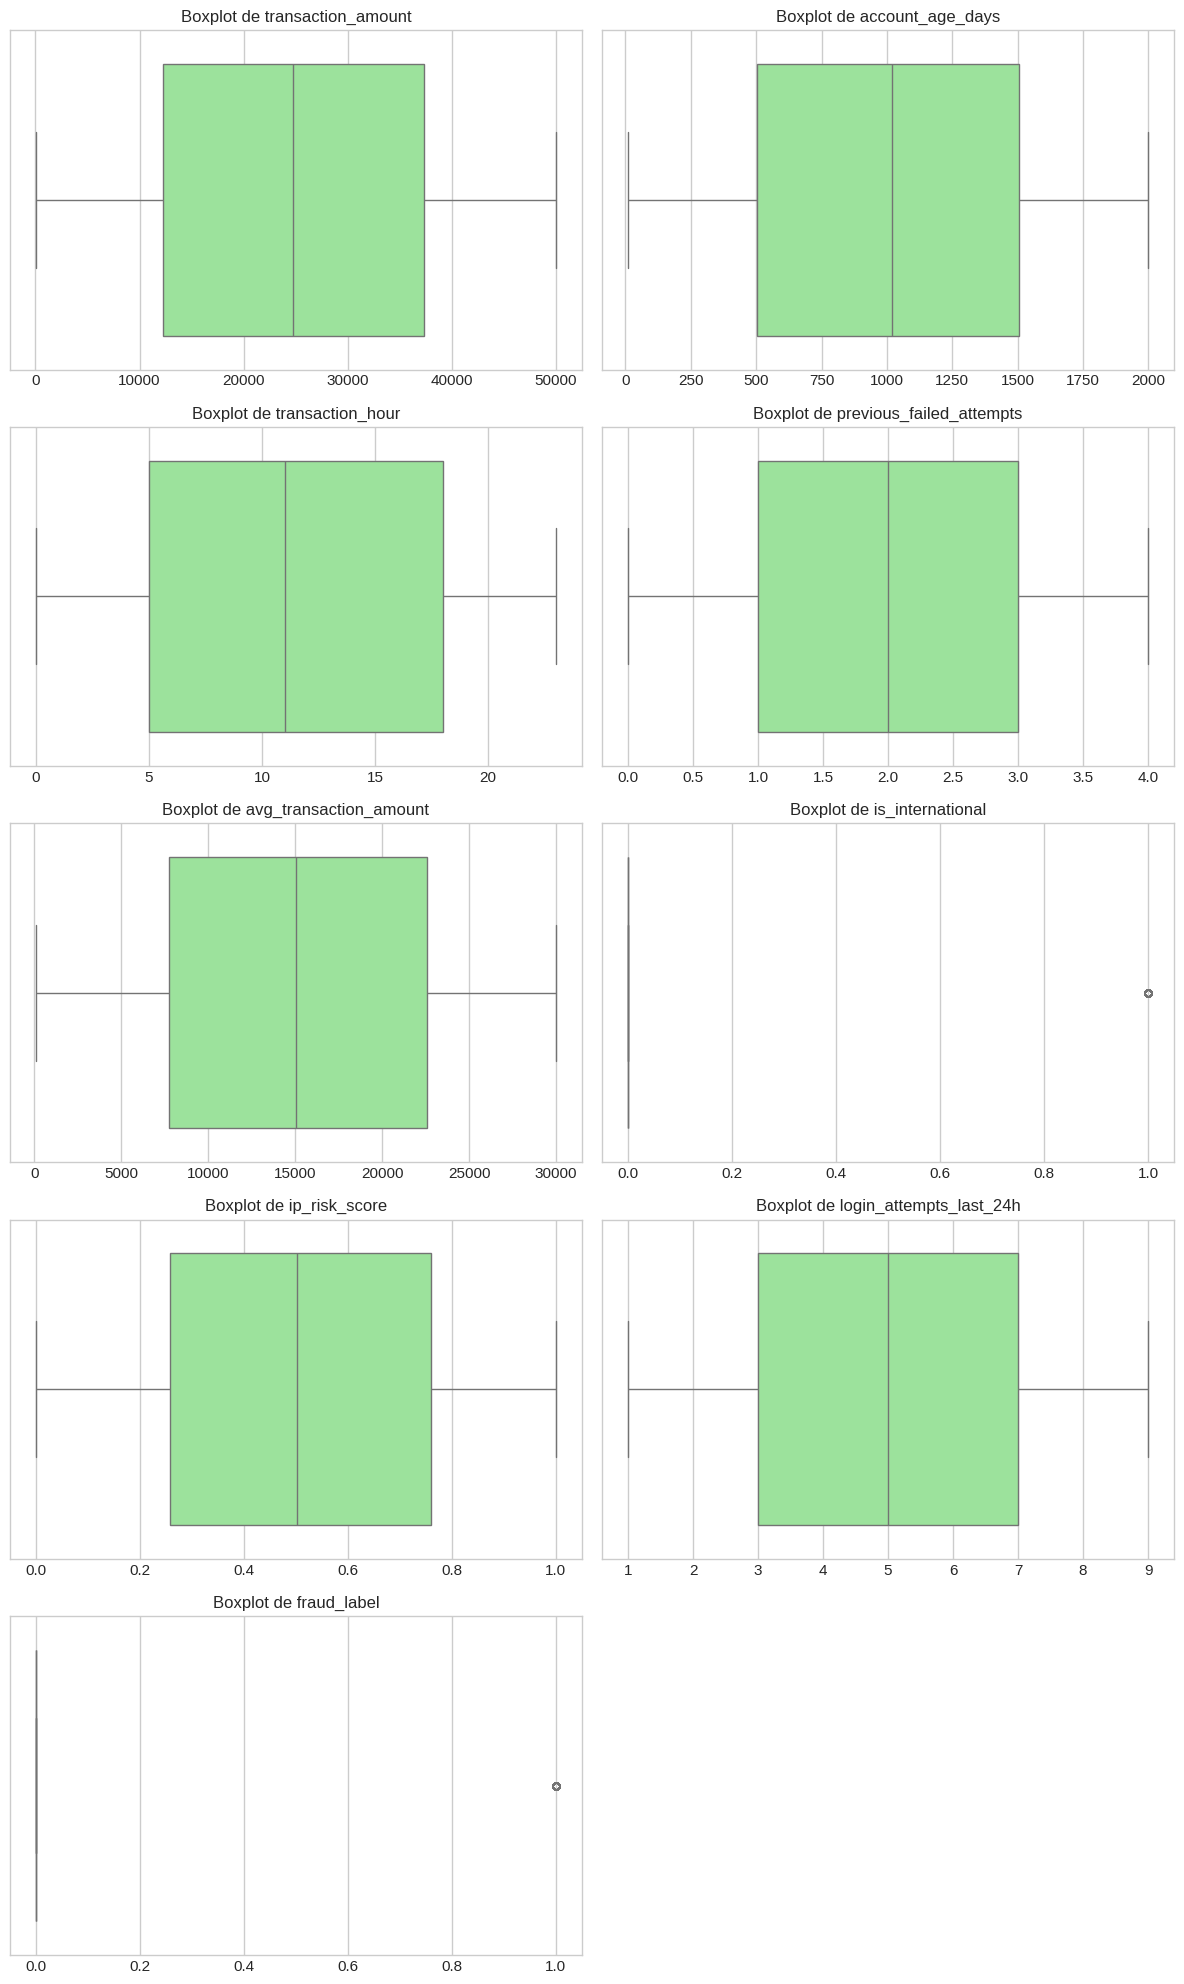

In [ ]:
# Visualização das distribuições das variáveis numéricas com boxplots para identificar outliers

# Número de colunas numéricas e configuração de layout
num_cols = len(numerical_cols)
cols_per_row = 2                      # número de subplots por linha
rows = math.ceil(num_cols / cols_per_row)  # calcula linhas necessárias

# Cria figura e eixos
fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(6*cols_per_row, 4*rows))
axes = axes.flatten()  # facilita iterar sobre todos os subplots

# Criação de cada boxplot
for i, col in enumerate(numerical_cols):
    sns.boxplot(
        x=new_treated_df[col],
        color='lightgreen',  # cor do boxplot
        fliersize=5,         # destaca outliers
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_xlabel('')  # remove label x para visual mais limpo
    axes[i].set_ylabel('')  # remove label y para visual mais limpo

# Remove subplots extras, caso existam
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # ajusta automaticamente espaçamento
plt.show()

#### 4.4.2 Distribuição das Variáveis Categóricas

Frequência por categoria para identificar desequilíbrios e categorias dominantes.

A análise combinada de histogramas e boxplots confirmou uma distribuição de dados com forte assimetria positiva (right-skewed), característica comum em variáveis de desvio financeiro. A sobreposição das densidades entre as classes sugere que a maioria das transações, sejam legítimas ou fraudulentas, concentra-se em baixos valores de desvio, dificultando a separação linear simples.

Entretanto, o alongamento acentuado da cauda direita nos histogramas de fraude e a maior dispersão de seus outliers nos boxplots indicam que valores extremos de `amount_deviation` e `amount_ratio` são indicadores mais fortes de anomalia criminosa. A paridade visual absoluta entre as duas métricas reforça a redundância estatística, sinalizando que a manutenção de ambos os atributos no treinamento pode não agregar ganho de informação ao modelo.

Embora a tendência central das classes seja similar, a magnitude das caudas e a densidade de eventos extremos na classe de fraude fornecem sinais valiosos para algoritmos de aprendizado supervisionado, desde que tratados para mitigar o impacto da alta variabilidade e do ruído presente nas transações verídicas.

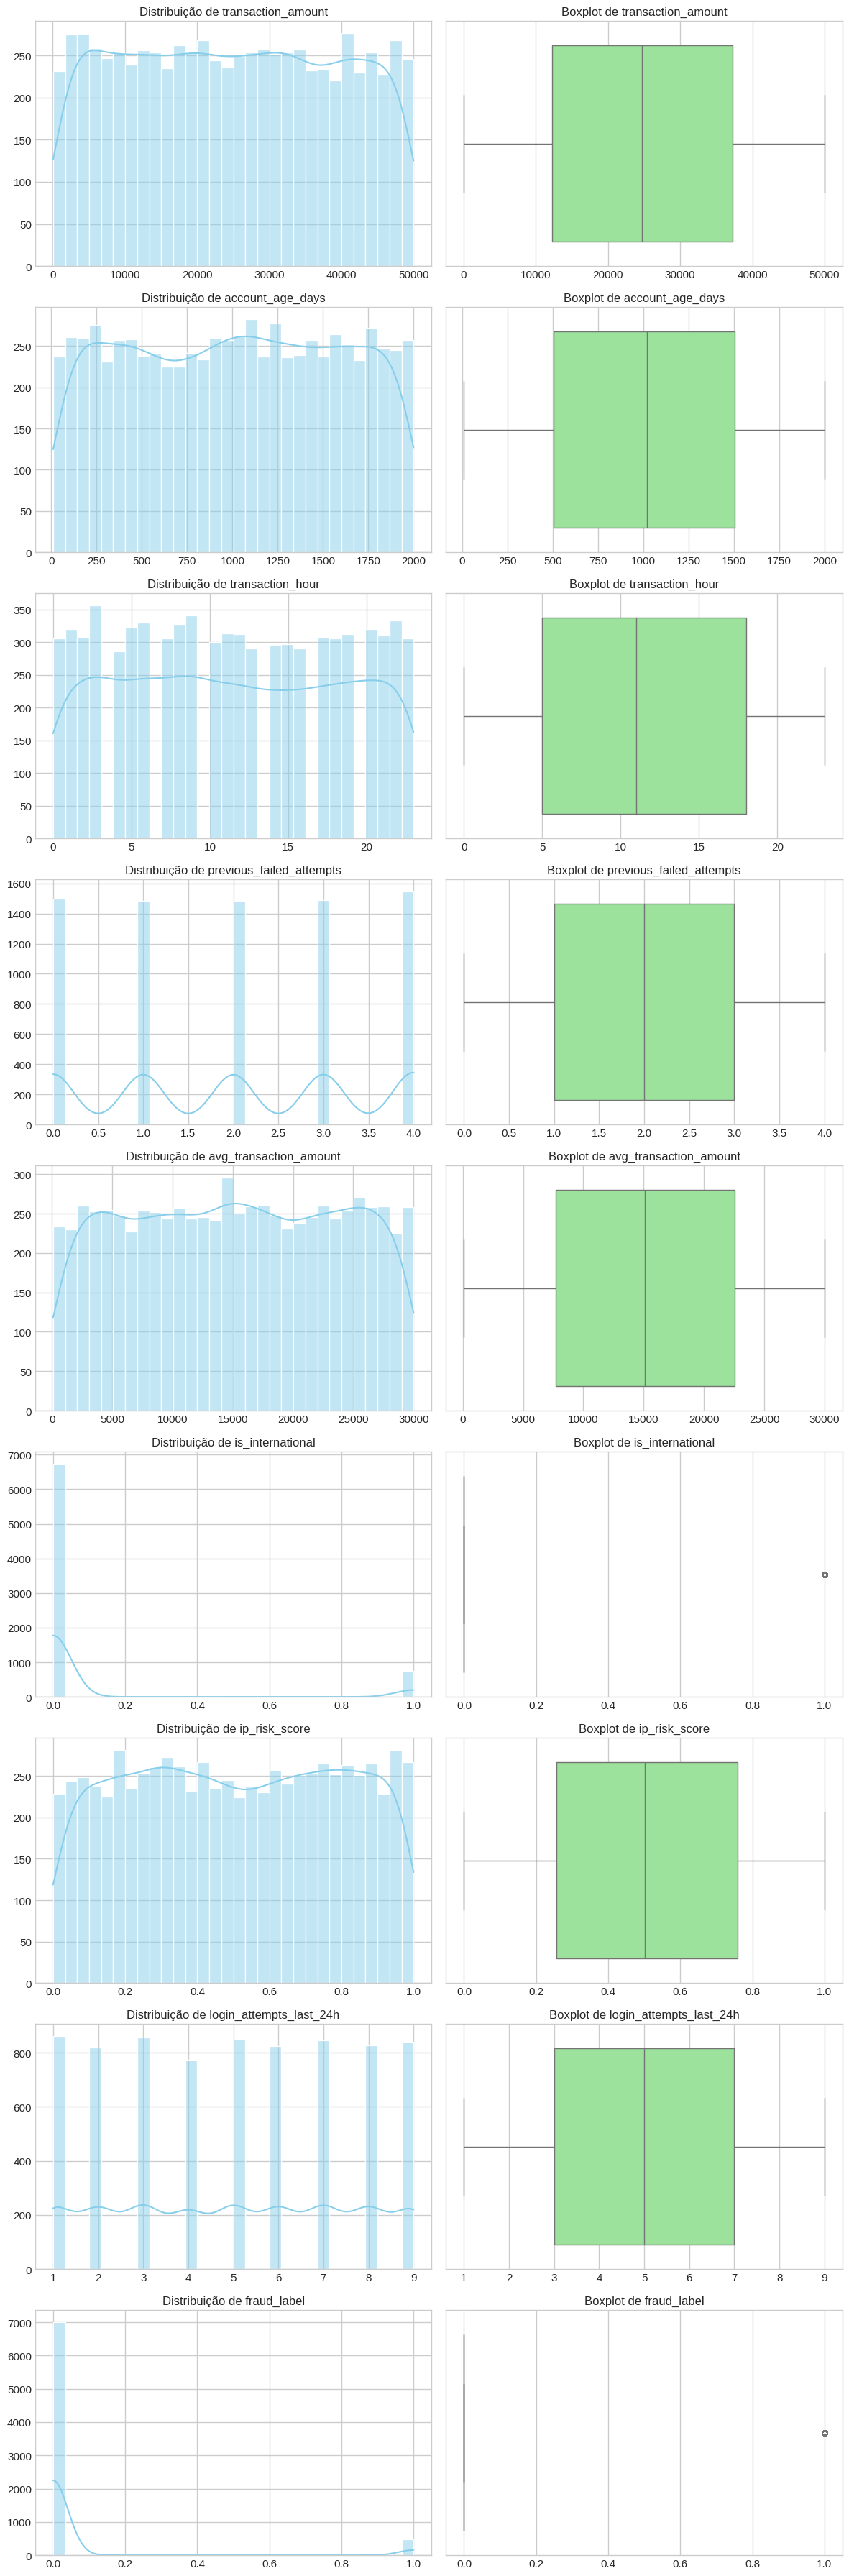

In [ ]:
# Histogramas e Boxplots das variáveis numéricas lado a lado para análise de distribuição e outliers
num_cols = len(numerical_cols)

# Cada variável terá 2 gráficos: histograma e boxplot
cols_per_row = 2
rows = num_cols  # 1 linha por variável

fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(12, 4*rows))
axes = axes.flatten()  # garante que axes seja 1D, mesmo com 1 linha

for i, col in enumerate(numerical_cols):
    # Histograma + KDE
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=axes[i*2])
    axes[i*2].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i*2].set_xlabel('')
    axes[i*2].set_ylabel('')

    # Boxplot
    sns.boxplot(x=df[col], color='lightgreen', fliersize=5, ax=axes[i*2+1])
    axes[i*2+1].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i*2+1].set_xlabel('')
    axes[i*2+1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. 🔗 Análise de Correlação(Bivariada)

Medição das relações entre variáveis numéricas por Pearson e Spearman, com gráficos de dispersão para os principais pares de variáveis.

### 5.1 Correlação de Pearson

A matriz de correlação de Pearson mede a relação linear entre variáveis numéricas, com valores entre -1 e +1. Valores próximos de ±1 indicam correlação forte, enquanto valores próximos de 0 indicam fraca ou nenhuma relação linear.

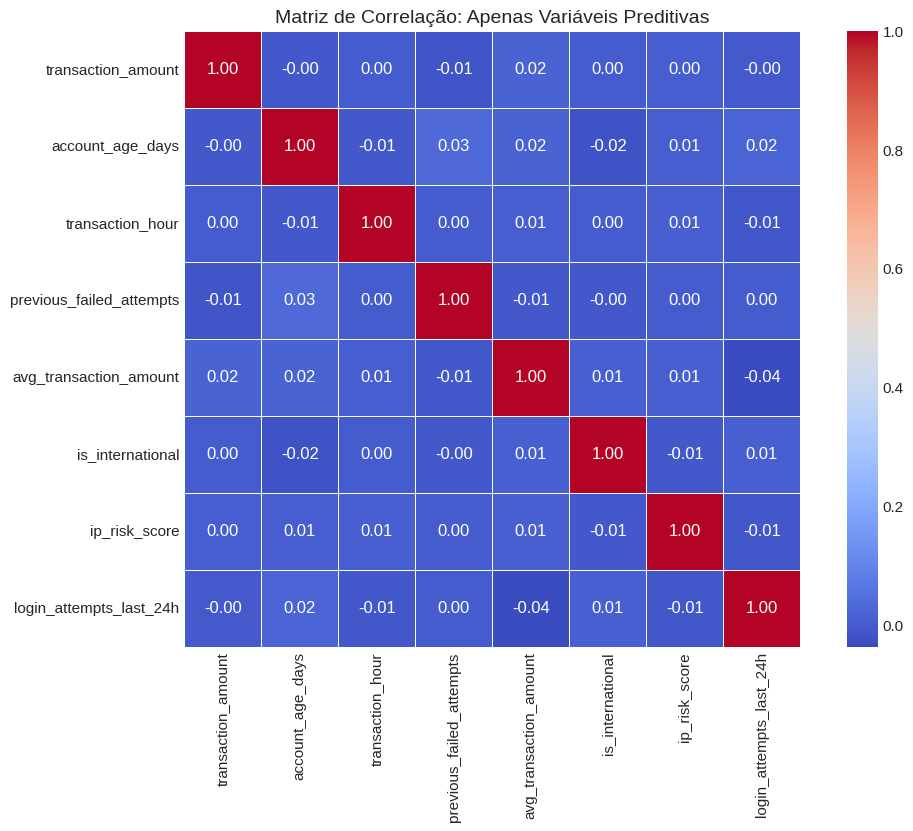

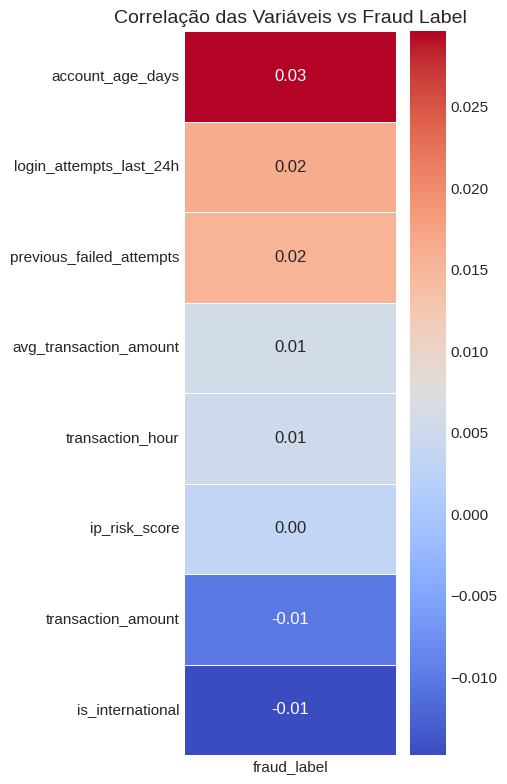

In [ ]:
# 1. Garantir que os nomes das colunas sejam únicos
# Usamos dict.fromkeys para manter a ordem original mas remover duplicatas
all_cols_names = list(dict.fromkeys(list(numerical_cols) + ['fraud_label']))

# 2. Calcular a matriz de correlação
corr_matrix = new_treated_df[all_cols_names].corr()

# --- GRÁFICO 1: Correlação entre Variáveis (Sem o Alvo) ---
# Aqui removemos a fraud_label da visualização
features_corr = corr_matrix.drop(index='fraud_label', columns='fraud_label')

plt.figure(figsize=(12, 8))
sns.heatmap(
    features_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title('Matriz de Correlação: Apenas Variáveis Preditivas', fontsize=14)
plt.show()

# --- GRÁFICO 2: Correlação com a Variável Alvo (Fraud Label) ---
# Selecionamos a coluna alvo. Se houver duplicata na matriz original,
# o passo 1 acima já terá resolvido.
target_corr = corr_matrix[['fraud_label']].drop(index='fraud_label').sort_values(by='fraud_label', ascending=False)

plt.figure(figsize=(5, 8))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5
)
plt.title('Correlação das Variáveis vs Fraud Label', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = new_treated_df[numerical_cols].corr().round(2)
corr_matrix

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
transaction_amount,1.00,-0.00,0.00,-0.01,0.02,0.00,0.00,-0.00,-0.01
account_age_days,-0.00,1.00,-0.01,0.03,0.02,-0.02,0.01,0.02,0.03
transaction_hour,0.00,-0.01,1.00,0.00,0.01,0.00,0.01,-0.01,0.01
previous_failed_attempts,-0.01,0.03,0.00,1.00,-0.01,-0.00,0.00,0.00,0.02
avg_transaction_amount,0.02,0.02,0.01,-0.01,1.00,0.01,0.01,-0.04,0.01
is_international,0.00,-0.02,0.00,-0.00,0.01,1.00,-0.01,0.01,-0.01
ip_risk_score,0.00,0.01,0.01,0.00,0.01,-0.01,1.00,-0.01,0.00
login_attempts_last_24h,-0.00,0.02,-0.01,0.00,-0.04,0.01,-0.01,1.00,0.02
fraud_label,-0.01,0.03,0.01,0.02,0.01,-0.01,0.00,0.02,1.00


A análise de correlação utilizando o coeficiente de Pearson evidenciou a ausência de relações lineares significativas entre as variáveis do conjunto de dados. Os coeficientes observados foram, em sua maioria, próximos de zero, tanto entre as variáveis explicativas quanto em relação à variável alvo `fraud_label`.

Esse resultado indica baixa dependência linear entre os atributos, além da inexistência de multicolinearidade relevante no conjunto de dados.

Entretanto, a ausência de correlação linear não implica ausência de relação entre as variáveis, sugerindo que possíveis padrões associados à detecção de fraude podem ser de natureza não linear ou depender de interações entre múltiplos atributos.

Para validação visual, foram construídos gráficos de dispersão para pares de variáveis com maior potencial de relação, como transaction_amount versus avg_transaction_amount.


### 5.2 Gráficos de Dispersão

Exploração de pares de variáveis potencialmente relevantes para separação entre fraude e transações legítimas.

#### 5.2.1 Valor da Transação vs. Média do Usuário

A linha de tendência praticamente horizontal confirma ausência de relação linear. O valor de uma transação isolada não é predito pela média histórica do usuário neste dataset.


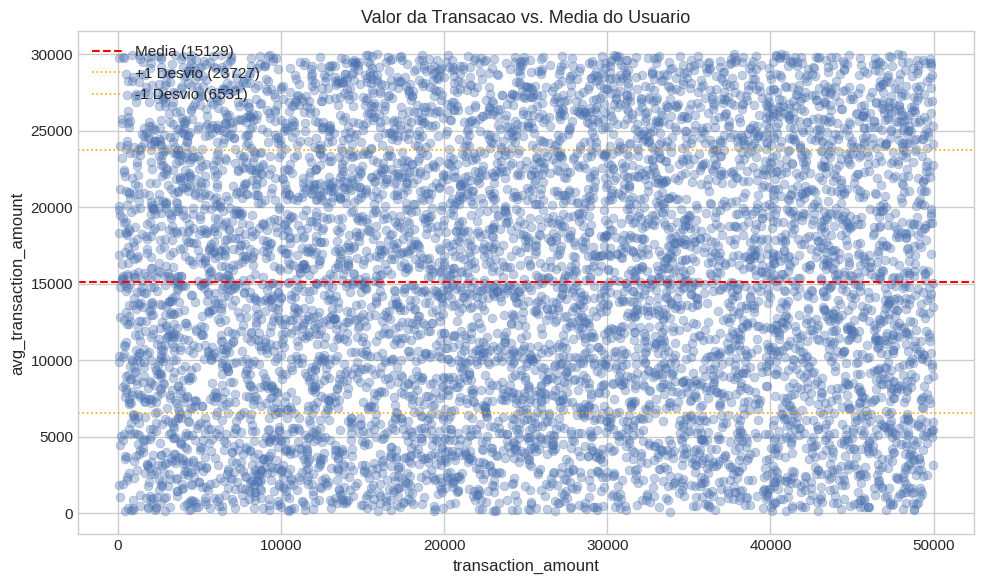

In [ ]:
def smart_scatter_with_threshold(df_plot, x, y, title):
    mean_val = df_plot[y].mean()
    std_val = df_plot[y].std()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_plot, x=x, y=y, alpha=0.35, s=40, edgecolor=None)
    plt.axhline(mean_val, color='red', linestyle='--', linewidth=1.5,
                label=f'Media ({mean_val:.0f})')
    plt.axhline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.2,
                label=f'+1 Desvio ({mean_val + std_val:.0f})')
    plt.axhline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.2,
                label=f'-1 Desvio ({mean_val - std_val:.0f})')
    plt.title(title, fontsize=13)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend()
    plt.tight_layout()
    plt.show()

smart_scatter_with_threshold(new_treated_df, 'transaction_amount', 'avg_transaction_amount',
                             'Valor da Transacao vs. Media do Usuario')

#### 5.2.2 Valor da Transação vs. Score de Risco do IP

Pontos de fraude distribuídos por todo o espaço das transações legítimas, sem formação de clusters separáveis. Isoladamente, nenhuma das duas variáveis é suficiente para classificar fraude.

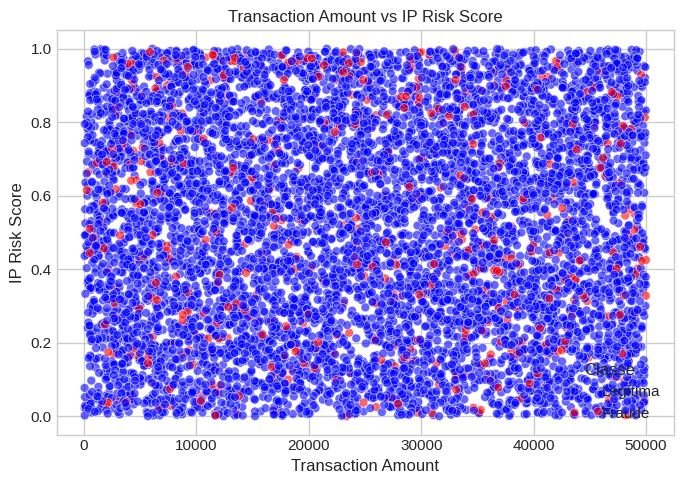

In [ ]:
df_plot = new_treated_df.copy()

df_plot['fraud_label_text'] = df_plot['fraud_label'].map({
    0: 'Legítima',
    1: 'Fraude'
})

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df_plot,
    x='transaction_amount',
    y='ip_risk_score',
    hue='fraud_label_text',
    palette={'Legítima': 'blue', 'Fraude': 'red'},
    alpha=0.6,
    s=40  # melhora visibilidade
)

plt.title('Transaction Amount vs IP Risk Score')
plt.xlabel('Transaction Amount')
plt.ylabel('IP Risk Score')

plt.legend(title='Classe')
plt.tight_layout()
plt.show()

#### 5.2.3 Tentativas de Login vs. Falhas Anteriores

A sobreposição entre as classes confirma que essas variáveis individualmente não discriminam fraudes. A combinação delas como interação pode ter maior poder preditivo.

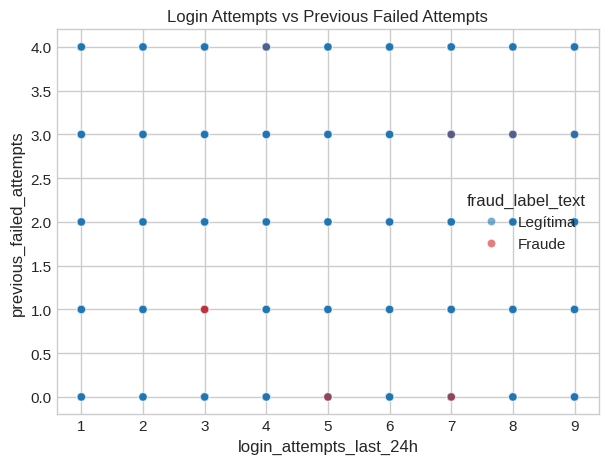

In [ ]:
palette = {
    'Legítima': 'tab:blue',
    'Fraude': 'tab:red'
}

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_plot,
    x='login_attempts_last_24h',
    y='previous_failed_attempts',
    hue='fraud_label_text',
    palette=palette,
    alpha=0.6
)

plt.title('Login Attempts vs Previous Failed Attempts')
plt.show()

#### 5.2.4 Valor da Transação vs. Idade da Conta

Fraudes ocorrem com frequência uniforme em contas novas e antigas e em todos os níveis de valor. Não há separação linear que indique concentração de fraudes em contas recentes ou valores elevados.

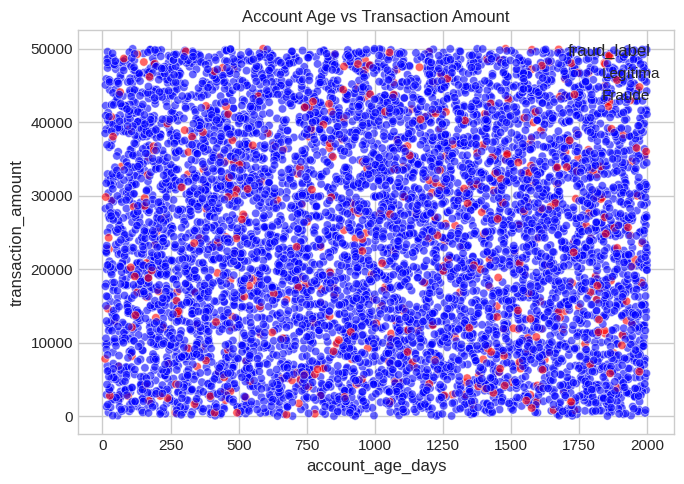

In [ ]:
palette = {
    0: "blue",
    1: "red"
}

plt.figure(figsize=(7, 5))

ax = sns.scatterplot(
    data=df_plot,
    x='account_age_days',
    y='transaction_amount',
    hue='fraud_label',
    palette=palette,
    alpha=0.6
)

plt.title('Account Age vs Transaction Amount')

# legenda mais robusta (sem depender de ordem)
handles, labels = ax.get_legend_handles_labels()

label_map = {
    "0": "Legítima",
    "1": "Fraude"
}

ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='fraud_label'
)

plt.tight_layout()
plt.show()

### 5.3 Correlação de Spearman

Mede relações monotônicas, mais robusta a outliers que Pearson e capaz de capturar relações não lineares ordenadas.

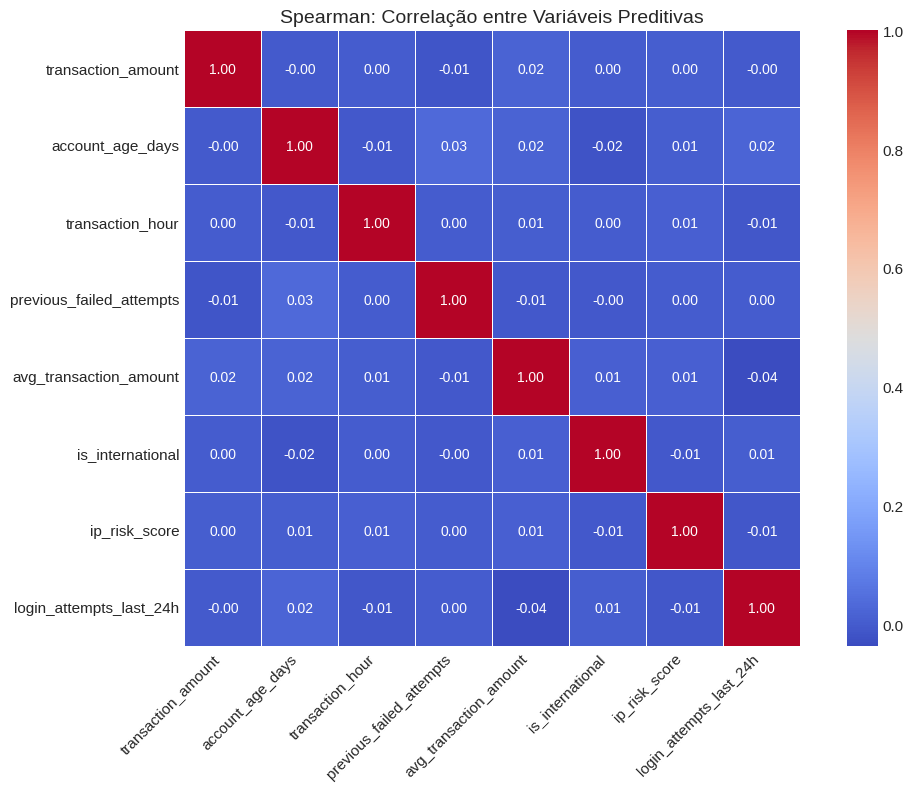

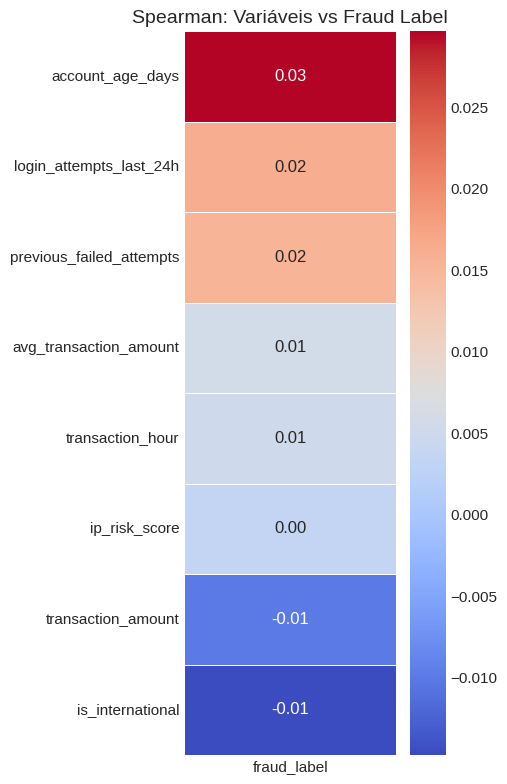

In [ ]:
# 1. Preparando os dados
# Selecionamos apenas as colunas numéricas e garantimos que fraud_label esteja presente
numeric_df = new_treated_df.select_dtypes(include='number').copy()

# Calculamos a matriz completa de Spearman uma única vez
corr_spearman = numeric_df.corr(method='spearman')

# --- GRÁFICO 1: Matriz de Features (Sem a Variável Alvo) ---
# Removemos a fraud_label tanto do índice quanto da coluna
features_spearman = corr_spearman.drop(index='fraud_label', columns='fraud_label', errors='ignore')

plt.figure(figsize=(12, 8))
sns.heatmap(
    features_spearman,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title('Spearman: Correlação entre Variáveis Preditivas', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

# --- GRÁFICO 2: Correlação Spearman com o Alvo (Fraud Label) ---
# Isolamos a coluna alvo, removemos a auto-correlação e ordenamos
target_spearman = corr_spearman[['fraud_label']].drop(index='fraud_label', errors='ignore').sort_values(by='fraud_label', ascending=False)

plt.figure(figsize=(5, 8))
sns.heatmap(
    target_spearman,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5
)
plt.title('Spearman: Variáveis vs Fraud Label', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display

corr = numeric_df.corr(method='spearman')

display(corr)

,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
transaction_amount,1.000000,-0.004537,0.000526,-0.013391,0.017256,0.001381,0.004728,-0.002683,-0.010075
account_age_days,-0.004537,1.000000,-0.005360,0.032884,0.018512,-0.017067,0.006998,0.021458,0.029674
transaction_hour,0.000526,-0.005360,1.000000,0.000299,0.006372,0.000550,0.009581,-0.012603,0.005131
previous_failed_attempts,-0.013391,0.032884,0.000299,1.000000,-0.005806,-0.004754,0.002678,0.000951,0.015346
avg_transaction_amount,0.017256,0.018512,0.006372,-0.005806,1.000000,0.008537,0.008081,-0.037093,0.005605
is_international,0.001381,-0.017067,0.000550,-0.004754,0.008537,1.000000,-0.005771,0.007461,-0.014765
ip_risk_score,0.004728,0.006998,0.009581,0.002678,0.008081,-0.005771,1.000000,-0.010090,0.003603
login_attempts_last_24h,-0.002683,0.021458,-0.012603,0.000951,-0.037093,0.007461,-0.010090,1.000000,0.016292
fraud_label,-0.010075,0.029674,0.005131,0.015346,0.005605,-0.014765,0.003603,0.016292,1.000000


Os resultados obtidos são consistentes com a análise de Pearson, indicando que não há relações monotônicas fortes adicionais não capturadas pela análise linear.

As variáveis de risco e comportamento do usuário apresentam correlações moderadas a altas entre si, sugerindo consistência interna e possível redundância entre features derivadas.

Por outro lado, a variável alvo fraud_label apresenta correlações próximas de zero com as demais variáveis, sugerindo que a detecção de fraude não depende de relações isoladas simples, sejam lineares ou monotônicas.

## 6. 🕵️ Análise de Fraude

Análise direcionada ao comportamento da variável alvo `fraud_label`: distribuição das classes, taxa de fraude por segmento e análise de valores por classe.

### 6.1 Distribuição da Variável Alvo

Verificação do balanceamento entre classes. O grau de desbalanceamento influencia diretamente a estratégia de treinamento.

In [ ]:
# Análise exploratória comparando transações legítimas e fraudulentas

# Coluna alvo correta
target_col = 'fraud_label'

# Conferir distribuição
print(new_treated_df[target_col].value_counts())

# Mapear classes
class_names = {0: 'Legítima', 1: 'Fraude'}

new_treated_df['status_fraude'] = new_treated_df[target_col].map(class_names)

# Verificar se o mapeamento funcionou corretamente
print(new_treated_df['status_fraude'].value_counts(dropna=False))

# Definir cores
colors_mapped = {'Legítima': 'lightgreen', 'Fraude': 'salmon'}

# Definir colunas numéricas (importante!)
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remover a coluna alvo das features numéricas (opcional)
num_cols = [col for col in num_cols if col != target_col]

# --- Gráfico de Contagem ---
fig = px.histogram(
    new_treated_df,
    x='status_fraude',
    color='status_fraude',
    color_discrete_map=colors_mapped,
    text_auto=True,
    title='Distribuição de Transações: Legítimas vs. Fraudulentas'
)

fig.update_layout(
    xaxis_title='Status da Transação',
    yaxis_title='Contagem',
    showlegend=False
)

fig.show()

# --- Histogramas Percentuais ---
for col in num_cols:
    fig = px.histogram(
        new_treated_df,
        x=col,
        color='status_fraude',
        color_discrete_map=colors_mapped,
        barmode='overlay',
        histnorm='percent',
        opacity=0.6,
        title=f'Distribuição de {col} por classe (%)'
    )

    fig.update_layout(
        xaxis_title=col,
        yaxis_title='Percentual',
        legend_title_text='Status'
    )

    fig.show()

# --- Boxplots ---
for col in num_cols:
    fig = px.box(
        new_treated_df,
        x='status_fraude',
        y=col,
        color='status_fraude',
        color_discrete_map=colors_mapped,
        title=f'Boxplot de {col} por classe',
        points='outliers'
    )

    fig.update_layout(
        xaxis_title='Status da Transação',
        yaxis_title=col,
        showlegend=False
    )

    fig.show()

fraud_label
0    7011
1     489
Name: count, dtype: int64
status_fraude
Legítima    7011
Fraude       489
Name: count, dtype: int64


In [ ]:
new_treated_df['fraud_label'].value_counts(normalize=True)

,proportion
fraud_label,
0,0.9348
1,0.0652


### 6.2 Distribuição da Variável Alvo

Verificação do balanceamento entre classes. O grau de desbalanceamento influencia diretamente a estratégia de treinamento.Relações categóricas importantes

Inicialmente, foi analisada a distribuição de transações por meio de pagamento utilizando contagem absoluta. As proporções de fraude são relativamente semelhantes entre as categorias, indicando baixa capacidade isolada de discriminação da variável `payment_mode`.

Em seguida, foi realizada uma análise complementar considerando a proporção de fraudes por categoria, permitindo identificar diferenças no risco entre os tipos de pagamento.

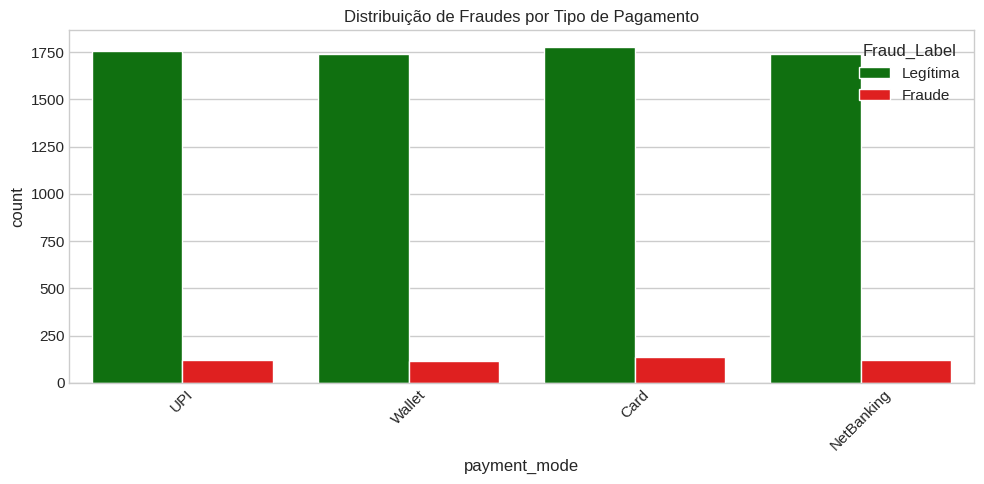

In [ ]:
def set_fraud_style():

    return {0: "green", 1: "red"}

fraud_palette = set_fraud_style()

plt.figure(figsize=(10, 5))

ax = sns.countplot(

    data=payment_fraud_data,

    x="payment_mode",

    hue="fraud_label",

    palette=fraud_palette

)


ax.tick_params(axis='x', rotation=45)

ax.set_title("Distribuição de Fraudes por Tipo de Pagamento")

ax.legend(title="Fraud_Label", labels=["Legítima", "Fraude"])

plt.tight_layout()

plt.show()

A análise detalhada mostra pequenas variações na taxa de fraude entre os meios de pagamento, com destaque para o uso de cartão, que apresenta leve maior incidência.

Apesar disso, as diferenças são moderadas, indicando que o meio de pagamento sozinho não é altamente discriminativo, mas pode contribuir quando combinado com outras variáveis.

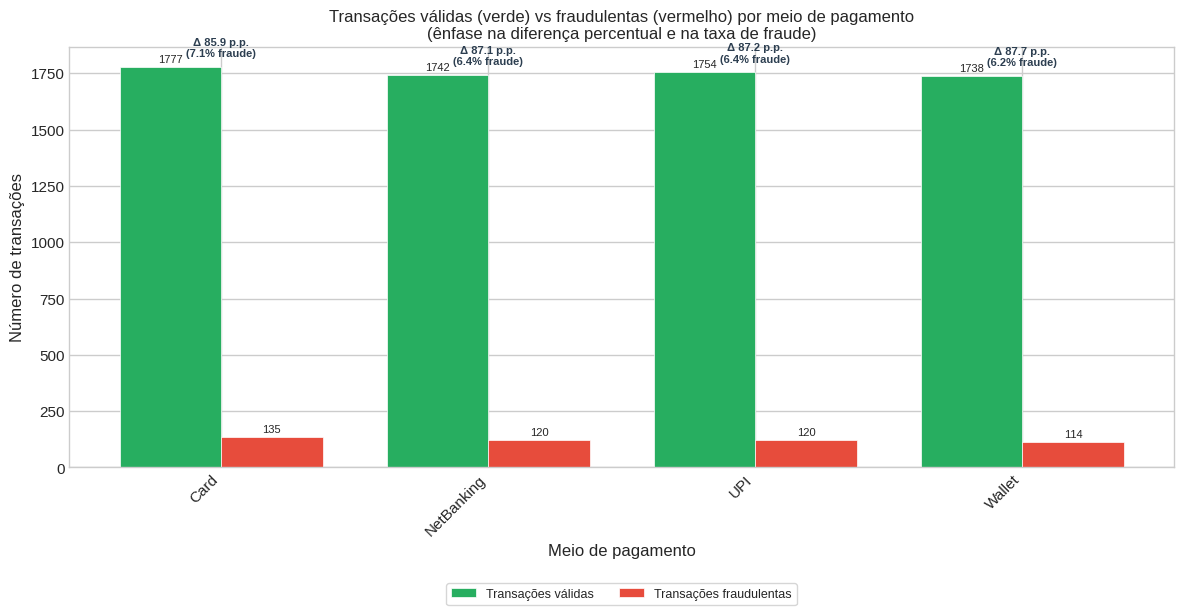

In [ ]:
# Contagens por meio de pagamento (0 = válida, 1 = fraude)
agg = new_treated_df.groupby(["payment_mode", "fraud_label"]).size().unstack(fill_value=0)
for col in (0, 1):
    if col not in agg.columns:
        agg[col] = 0
agg = agg[[0, 1]]
agg.columns = ["validas", "fraudulentas"]
agg["total"] = agg["validas"] + agg["fraudulentas"]
agg["pct_validas"] = (agg["validas"] / agg["total"].replace(0, np.nan) * 100).fillna(0)
agg["pct_fraude"] = (agg["fraudulentas"] / agg["total"].replace(0, np.nan) * 100).fillna(0)
agg["diff_pct"] = agg["pct_validas"] - agg["pct_fraude"]

# Ordena pela taxa de fraude (maior contraste entre meios)
order = agg.sort_values("pct_fraude", ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6.8))
x = np.arange(len(order))
w = 0.38
c_valid = "#27ae60"
c_fraud = "#e74c3c"

bars_v = ax.bar(
    x - w / 2,
    agg.loc[order, "validas"],
    w,
    label="Transações válidas",
    color=c_valid,
    edgecolor="white",
    linewidth=0.5,
)
bars_f = ax.bar(
    x + w / 2,
    agg.loc[order, "fraudulentas"],
    w,
    label="Transações fraudulentas",
    color=c_fraud,
    edgecolor="white",
    linewidth=0.5,
)

for i, pm in enumerate(order):
    row = agg.loc[pm]
    h = max(row["validas"], row["fraudulentas"])
    ax.annotate(
        f"Δ {row['diff_pct']:.1f} p.p.\n({row['pct_fraude']:.1f}% fraude)",
        xy=(i, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="#2c3e50",
    )

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title(
    "Transações válidas (verde) vs fraudulentas (vermelho) por meio de pagamento\n"
    "(ênfase na diferença percentual e na taxa de fraude)"
)
ax.set_xlabel("Meio de pagamento")
ax.set_ylabel("Número de transações")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.26),
    ncol=2,
    frameon=True,
    fontsize=9,
)
ax.bar_label(bars_v, padding=2, fontsize=8)
ax.bar_label(bars_f, padding=2, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(bottom=0.30)
plt.show()

### 6.3 Taxa de Fraude por Segmento

Proporção de fraudes em subgrupos do dataset para identificar se determinados tipos de dispositivo, modalidade de pagamento ou localização concentram maior risco.

#### 6.3.1 Taxa de Fraude por Tipo de Dispositivo

Comparação da proporção de transações fraudulentas por tipo de dispositivo.

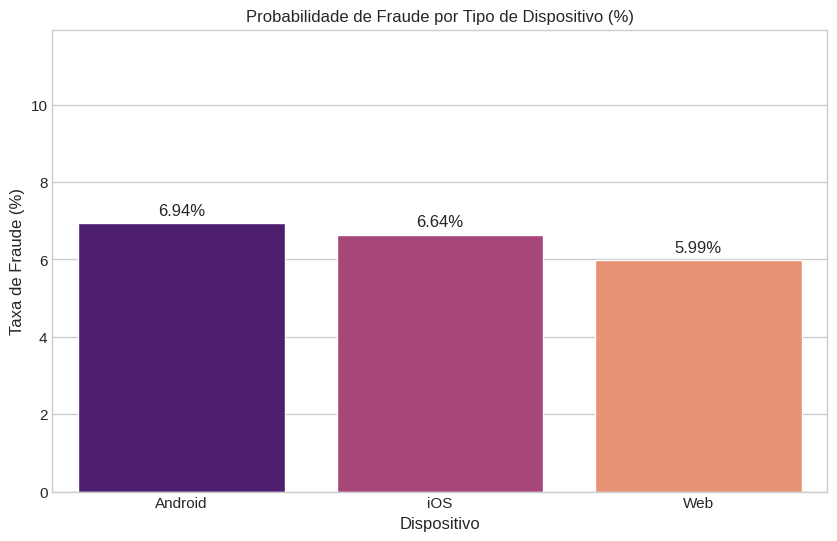

In [ ]:
# 1. Calculando a taxa de fraude por dispositivo
# Como fraud_label é 0 ou 1, a média (mean) resulta na proporção de fraudes.
df_derivative = new_treated_df.copy()
device_fraud_rate = df_derivative.groupby('device_type')['fraud_label'].mean().reset_index()
device_fraud_rate['fraud_percentage'] = device_fraud_rate['fraud_label'] * 100

# 2. Ordenando para o gráfico ficar mais legível
device_fraud_rate = device_fraud_rate.sort_values(by='fraud_percentage', ascending=False)

# 3. Criando o gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='device_type', y='fraud_percentage', data=device_fraud_rate, palette='magma', hue='device_type', legend=False)

# Adicionando os rótulos de porcentagem em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Probabilidade de Fraude por Tipo de Dispositivo (%)')
plt.ylabel('Taxa de Fraude (%)')
plt.xlabel('Dispositivo')
plt.ylim(0, device_fraud_rate['fraud_percentage'].max() + 5) # Dá um respiro no topo do gráfico
plt.show()

In [ ]:
# Tabela de resumo
ranking_fraude = new_treated_df.groupby('payment_mode')['fraud_label'].agg(['count', 'sum', 'mean']).reset_index()

# Renomeando as colunas
ranking_fraude.columns = [
    'Meio de Pagamento',
    'Total de Transações',
    'Qtd. de Fraudes',
    'Taxa de Fraude (%)'
]

# Calculando a quantidade de transações legítimas
ranking_fraude['Qtd. Legítimas'] = ranking_fraude['Total de Transações'] - ranking_fraude['Qtd. de Fraudes']

# Formatando a Taxa de Fraude para porcentagem
ranking_fraude['Taxa de Fraude (%)'] = (ranking_fraude['Taxa de Fraude (%)'] * 100).round(2)

# Ordenando pelo ranking das maiores taxas (do maior risco para o menor)
ranking_fraude = ranking_fraude.sort_values(by='Taxa de Fraude (%)', ascending=False)

# Reorganizando as colunas para uma leitura lógica
colunas_finais = ['Meio de Pagamento', 'Total de Transações', 'Qtd. Legítimas', 'Qtd. de Fraudes', 'Taxa de Fraude (%)']
ranking_fraude = ranking_fraude[colunas_finais]

# Exibindo a tabela final
print(ranking_fraude.to_string(index=False))


Meio de Pagamento  Total de Transações  Qtd. Legítimas  Qtd. de Fraudes  Taxa de Fraude (%)
             Card                 1912            1777              135                7.06
       NetBanking                 1862            1742              120                6.44
              UPI                 1874            1754              120                6.40
           Wallet                 1852            1738              114                6.16


#### 6.3.2 Distribuição de Valor: Legítimas vs. Fraudulentas

Curvas de densidade para o valor da transação separadas por classe.

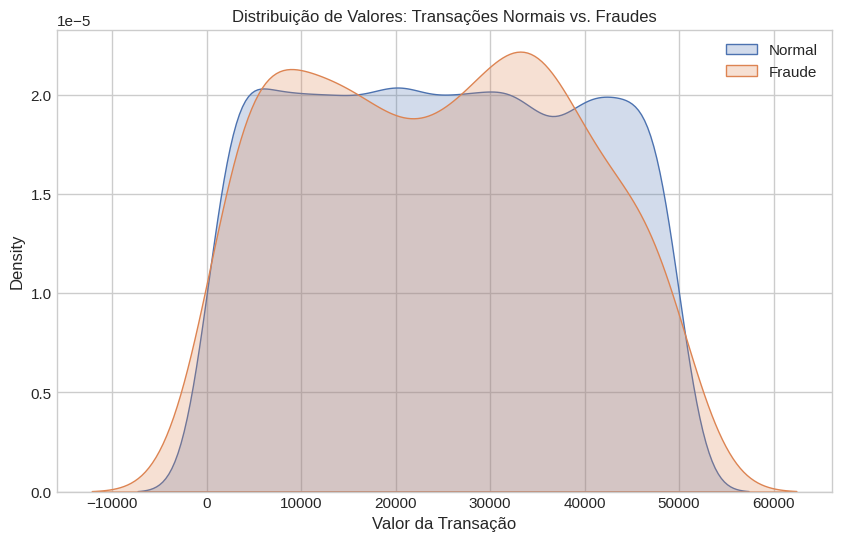

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df[df['fraud_label'] == 0], x='transaction_amount', label='Normal', fill=True)
sns.kdeplot(data=df[df['fraud_label'] == 1], x='transaction_amount', label='Fraude', fill=True)
plt.title('Distribuição de Valores: Transações Normais vs. Fraudes')
plt.xlabel('Valor da Transação')
plt.legend()
plt.show()

No grafico consta dois picos de valores comuns entre operacoes fraudulentas, entre 5.000 e 10.000 e entre 30.000 e 35.000

#### 6.3.3 Concentração Geográfica de Fraudes

Heatmap cruzando localização do dispositivo com modalidade de pagamento, restrito a transações fraudulentas.

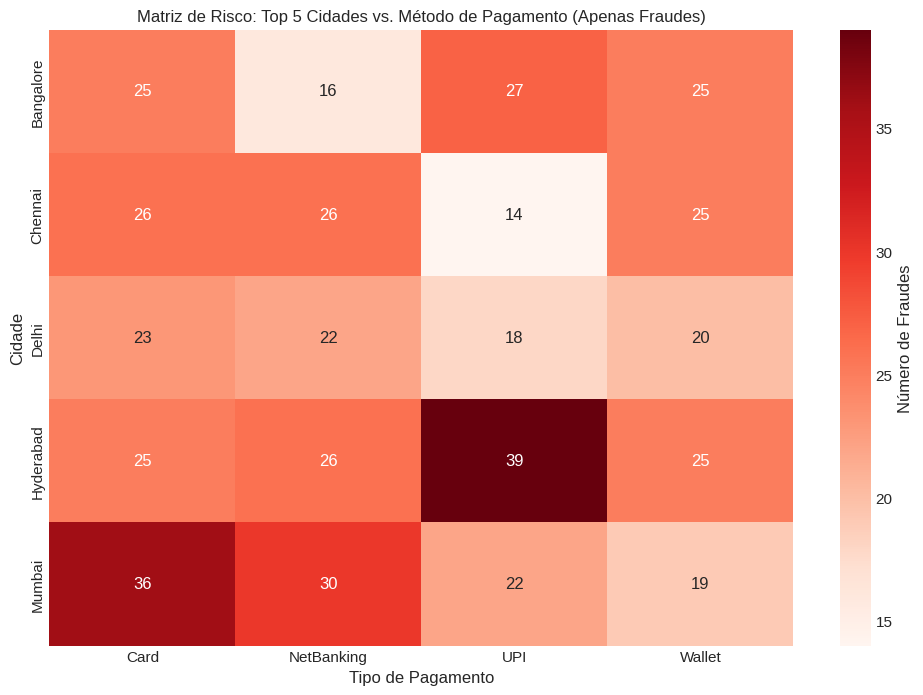

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrar apenas os casos de fraude
fraudes_df = new_treated_df[new_treated_df['fraud_label'] == 1]

# 2. Identificar as cidades com maior volume de fraude
top_cities = fraudes_df['device_location'].value_counts().nlargest(10).index

# 3. Filtrar o dataframe original para conter apenas essas cidades
df_top_cities = fraudes_df[fraudes_df['device_location'].isin(top_cities)]

# 4. Criar a Tabela Dinâmica (Pivot Table) para o Heatmap
# Contamos quantas fraudes ocorrem em cada cruzamento de Localização e Tipo de Pagamento
pivot_fraud = df_top_cities.pivot_table(index='device_location',
                                        columns='payment_mode',
                                        values='fraud_label',
                                        aggfunc='count').fillna(0)

# 5. Plotar o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_fraud, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': 'Número de Fraudes'})

plt.title('Matriz de Risco: Top 5 Cidades vs. Método de Pagamento (Apenas Fraudes)')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Cidade')
plt.show()

---

A partir desta seção é criada uma cópia independente do dataframe (`df_treated`) exclusivamente para a construção de features comportamentais. Esta separação evita **data leakage**: calcular estatísticas por usuário sobre o dataset completo incluiria informação de transações do conjunto de teste no treinamento.

## 7. 🧠 Engenharia de Features

Construção de variáveis derivadas que capturam padrões de comportamento individual, risco contextual e anomalias temporais.

In [ ]:
new_treated_df['user_id'].nunique(), new_treated_df.shape[0]

(5106, 7500)

### 7.1 Frequência de Transações por Usuário

Verificação de quantas transações cada usuário possui. Alta concentração em poucos usuários pode indicar comportamento repetitivo ou acúmulo de tentativas.

In [ ]:
df_treated = df.copy()

In [ ]:
user_tx_count = new_treated_df.groupby('user_id').size().sort_values(ascending=False)
user_tx_count.head(10)

,0
user_id,
U7229,6
U6797,6
U1247,6
U5997,5
U1730,5
U9588,5
U8037,5
U2911,5
U2234,5


### 7.2 Features de Contexto Transacional

Variáveis derivadas de atributos intrínsecos à transação: hora do dia, risco de IP e padrão de autenticação. São propriedades do evento de transação em si e independem de ordenação sequencial entre transações — diferente de estatísticas históricas do usuário, que foram descartadas por essa razão.

In [ ]:
def period_of_day(hour):
    if 0 <= hour < 6:
        return 'madrugada'
    elif 6 <= hour < 12:
        return 'manha'
    elif 12 <= hour < 18:
        return 'tarde'
    else:
        return 'noite'

df['period_of_day'] = df['transaction_hour'].apply(period_of_day)

In [ ]:
# Quantidade de transações legítimas e fraudes por período

tabela = (
    df.groupby(['period_of_day', 'fraud_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(['madrugada', 'manha', 'tarde', 'noite'])
)

# Renomeando colunas
tabela.columns = ['Legítima', 'Fraude']

# Adicionando taxa de fraude (%)
tabela['Taxa_Fraude_%'] = (
    tabela['Fraude'] / (tabela['Legítima'] + tabela['Fraude'])
) * 100

# Arredondando
tabela['Taxa_Fraude_%'] = tabela['Taxa_Fraude_%'].round(2)

print(tabela)

               Legítima  Fraude  Taxa_Fraude_%
period_of_day                                 
madrugada          1781     118           6.21
manha              1796     122           6.36
tarde              1670     125           6.96
noite              1764     124           6.57


In [ ]:
#Flag de horário suspeito
df['late_night_flag'] = (
    (df['transaction_hour'] >= 0) &
    (df['transaction_hour'] <= 5)
).astype(int)

In [ ]:
#Cyclical Encoding da variável transaction_hour
#Como a hora é uma variável cíclica (23h ≈ 0h), aplicamos transformação seno e cosseno para preservar essa natureza.

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour'] / 24)

In [ ]:
#risco por hora - analise exploratoria (nao adicionado ao df — data leakage)
hour_risk = df.groupby("transaction_hour")["fraud_label"].mean()
print(hour_risk.sort_index())

transaction_hour
0     0.068627
1     0.056250
2     0.045455
3     0.067227
4     0.080420
5     0.055901
6     0.081818
7     0.042484
8     0.064220
9     0.076246
10    0.060000
11    0.054140
12    0.073718
13    0.061856
14    0.091216
15    0.074074
16    0.051546
17    0.064935
18    0.055556
19    0.092652
20    0.059375
21    0.054839
22    0.069069
23    0.062092
Name: fraud_label, dtype: float64


In [ ]:
#Fraudes internacionais à madrugada.
df['international_night'] = (
    (df['is_international'] == 1) &
    (df['transaction_hour'] <= 5)
).astype(int)

In [ ]:
#Analisar fraude por hora exata
hour_analysis = (
    df.groupby('transaction_hour')['fraud_label']
    .mean()
    .sort_index()
)

print(hour_analysis)

transaction_hour
0     0.068627
1     0.056250
2     0.045455
3     0.067227
4     0.080420
5     0.055901
6     0.081818
7     0.042484
8     0.064220
9     0.076246
10    0.060000
11    0.054140
12    0.073718
13    0.061856
14    0.091216
15    0.074074
16    0.051546
17    0.064935
18    0.055556
19    0.092652
20    0.059375
21    0.054839
22    0.069069
23    0.062092
Name: fraud_label, dtype: float64


In [ ]:
#Transação muito alta
df['high_amount_flag'] = (
    df['transaction_amount'] >
    df['transaction_amount'].quantile(0.95)
).astype(int)

# Tabela cruzando high_amount_flag com fraude

tabela_high_amount = (
    pd.crosstab(
        df['high_amount_flag'],
        df['fraud_label'],
        margins=True
    )
)

# Renomeando colunas
tabela_high_amount.columns = ['Legítima', 'Fraude', 'Total']

print(tabela_high_amount)

                  Legítima  Fraude  Total
high_amount_flag                         
0                     6662     463   7125
1                      349      26    375
All                   7011     489   7500


In [ ]:
#Ip suspeito
df['high_ip_risk'] = (df['ip_risk_score'] > 0.8).astype(int)

tabela_ip = pd.crosstab(

    df['high_ip_risk'],

    df['fraud_label'],

    margins=True

)

tabela_ip.columns = ['Legítima', 'Fraude', 'Total']

print(tabela_ip)

              Legítima  Fraude  Total
high_ip_risk                         
0                 5572     374   5946
1                 1439     115   1554
All               7011     489   7500


In [ ]:
tabela_ip_taxa = (
    df.groupby('high_ip_risk')['fraud_label']
    .agg(['count', 'sum', 'mean'])
)

tabela_ip_taxa.columns = [
    'Total_Transacoes',
    'Qtd_Fraudes',
    'Taxa_Fraude'
]

tabela_ip_taxa['Taxa_Fraude'] = (
    tabela_ip_taxa['Taxa_Fraude'] * 100
).round(2)

tabela_ip_taxa.index = ['IP normal (≤0.8)', 'IP suspeito (>0.8)']

print(tabela_ip_taxa)

                    Total_Transacoes  Qtd_Fraudes  Taxa_Fraude
IP normal (≤0.8)                5946          374         6.29
IP suspeito (>0.8)              1554          115         7.40


In [ ]:
#Muitas tentativas de login
df['many_login_attempts'] = (
    df['login_attempts_last_24h'] > 5
).astype(int)



tabela_login = pd.crosstab(

    df['many_login_attempts'],

    df['fraud_label'],

    margins=True

)

tabela_login.columns = ['Legítima', 'Fraude', 'Total']

print(tabela_login)

                     Legítima  Fraude  Total
many_login_attempts                         
0                        3907     256   4163
1                        3104     233   3337
All                      7011     489   7500


In [ ]:
#taxa de fraude
tabela_login_taxa = (
    df.groupby('many_login_attempts')['fraud_label']
    .agg(['count', 'sum', 'mean'])
)

tabela_login_taxa.columns = [
    'Total_Transacoes',
    'Qtd_Fraudes',
    'Taxa_Fraude'
]

tabela_login_taxa['Taxa_Fraude'] = (
    tabela_login_taxa['Taxa_Fraude'] * 100
).round(2)

tabela_login_taxa.index = [
    'Poucas tentativas (≤5)',
    'Muitas tentativas (>5)'
]

print(tabela_login_taxa)

                        Total_Transacoes  Qtd_Fraudes  Taxa_Fraude
Poucas tentativas (≤5)              4163          256         6.15
Muitas tentativas (>5)              3337          233         6.98


In [ ]:
df_treated = df.copy()

#### *7.2.1* Features de Risco de Autenticação

Essas variáveis capturam comportamento suspeito relacionado a tentativas de login.

In [ ]:
df_treated['risk_login'] = (
    df_treated['login_attempts_last_24h'] *
    df_treated['previous_failed_attempts']
)

In [ ]:
df_treated['login_failure_rate'] = (
    df_treated['previous_failed_attempts'] /
    (df_treated['login_attempts_last_24h'] + 1)
)

In [ ]:
df_treated[[
    'login_attempts_last_24h',
    'previous_failed_attempts',
    'risk_login',
    'login_failure_rate'
]].head(10)

,login_attempts_last_24h,previous_failed_attempts,risk_login,login_failure_rate
0,4,1,4,0.200000
1,9,0,0,0.000000
2,9,4,36,0.400000
3,2,3,6,1.000000
4,1,1,1,0.500000
5,3,3,9,0.750000
6,8,4,32,0.444444
7,4,4,16,0.800000
8,5,0,0,0.000000
9,5,3,15,0.500000


In [ ]:
df_treated[['risk_login', 'login_failure_rate']].describe()

,risk_login,login_failure_rate
count,7500.000000,7500.000000
mean,10.061600,0.433701
std,9.574433,0.433318
min,0.000000,0.000000
25%,2.000000,0.125000
50%,8.000000,0.333333
75%,16.000000,0.571429
max,36.000000,2.000000


In [ ]:
df_treated.groupby('fraud_label')[['risk_login', 'login_failure_rate']].mean()

,risk_login,login_failure_rate
fraud_label,,
0,10.026815,0.432766
1,10.560327,0.447106


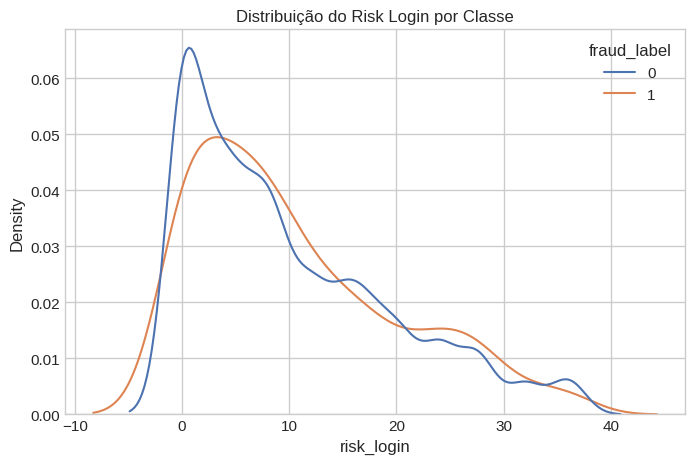

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(

    data=df_treated,

    x='risk_login',

    hue='fraud_label',

    common_norm=False

)

plt.title('Distribuição do Risk Login por Classe')

plt.show()

#### 7.2.2 Tentativas Falhas por Usuário

A coluna `previous_failed_attempts` já captura o histórico individual de falhas de autenticação por transação. Uma média global por usuário (`transform('mean')`) sobre o dataset inteiro introduziria **data leakage** (incluiria transações futuras no cálculo). Como o dataset não possui timestamp completo para um cálculo rolling correto, utilizamos `previous_failed_attempts` diretamente como proxy do comportamento histórico.


In [ ]:
df_treated[['user_id', 'previous_failed_attempts']]\
    .sort_values('previous_failed_attempts', ascending=False)\
    .head(10)


,user_id,previous_failed_attempts
6,U8763,4
7,U1439,4
7496,U6299,4
10,U7074,4
2,U1765,4
12,U2955,4
3043,U8767,4
3014,U2837,4
3018,U4126,4
3027,U5671,4


### 7.3 Interação: Volume de Login e Falhas

`risk_login` é o produto entre tentativas de login nas últimas 24h e o histórico de falhas. O produto amplifica situações em que ambos os sinais são elevados simultaneamente.

In [ ]:
# risk_login: produto de login_attempts e previous_failed_attempts
# amplifica situacoes em que ambos os sinais sao elevados simultaneamente
df_treated['risk_login'] = (
    df_treated['login_attempts_last_24h'] * df_treated['previous_failed_attempts']
)
print(df_treated[['login_attempts_last_24h', 'previous_failed_attempts', 'risk_login']].head())

   login_attempts_last_24h  previous_failed_attempts  risk_login
0                        4                         1           4
1                        9                         0           0
2                        9                         4          36
3                        2                         3           6
4                        1                         1           1


### 7.4 Features de Risco Composto

Features que combinam múltiplos sinais em uma única variável. Padrões que individualmente não são discriminativos podem ser capturados via interações.

A análise da variável risk_score mostra que, em média, os valores de risco são baixos a moderados (média ≈ 2.01), com a maior parte dos registos concentrados entre 0.56 e 3.45. A mediana próxima de 2 indica uma distribuição relativamente equilibrada, mas com alguns casos mais elevados. O valor máximo (7.22) sugere a existência de alguns registos com comportamento potencialmente suspeito. No geral, observa-se uma variabilidade significativa nos scores, indicando diferentes níveis de risco entre os utilizadores.

In [ ]:
# Proporção de falhas em relação ao total de tentativas (Taxa de erro)
df_treated['login_failure_rate'] = (
    df_treated['previous_failed_attempts'] / (df_treated['login_attempts_last_24h'] + 1)
)

### 7.5 Features Temporais e Geográficas
Transações na madrugada (00h–05h) e em contexto internacional apresentam risco elevado. As features a seguir codificam essas condições como variáveis binárias e como interação com o score de risco do I

In [ ]:
df_treated['is_night'] = (df_treated['transaction_hour'] < 6).astype(int)

print(df_treated[['transaction_hour', 'is_night']].drop_duplicates().sort_values('transaction_hour').to_string())

    transaction_hour  is_night  peak_risk_hour
32                 0         1               0
3                  1         1               0
21                 2         1               0
10                 3         1               0
4                  4         1               0
37                 5         1               0
74                 6         0               0
39                 7         0               0
2                  8         0               0
9                  9         0               0
23                10         0               0
8                 11         0               0
17                12         0               0
35                13         0               0
0                 14         0               1
34                15         0               0
65                16         0               0
14                17         0               0
91                18         0               0
43                19         0               1
5            

In [ ]:
#internacional + risco
df_treated['international_risk'] = df_treated['is_international'] * df_treated['ip_risk_score']
print(df_treated[['is_international', 'ip_risk_score', 'international_risk']].head())

   is_international  ip_risk_score  international_risk
0                 0          0.718               0.000
1                 0          0.525               0.000
2                 0          0.985               0.000
3                 0          0.797               0.000
4                 1          0.468               0.468


In [ ]:
#madrugada + internacional
df_treated['night_intl_risk'] = (
    (df_treated['is_night'] == 1) & (df_treated['is_international'] == 1)
).astype(int)


## 8. 💧 Detecção de Vazamento de Dados

Verificação de features que carreguem informação disponível apenas após a ocorrência do evento. Data leakage infla artificialmente as métricas e compromete a aplicabilidade em produção.

### 8.1 Identificadores

Verificação de `transaction_id` e `user_id`. Identificadores não contêm padrão preditivo e devem ser excluídos do treinamento.

- `transaction_id` é único por linha: não contém padrão preditivo, deve ser removido.
- `user_id` é repetido entre transações: pode introduzir memorização por usuário se incluído diretamen


In [ ]:
df_treated[['transaction_id', 'user_id']].head()

,transaction_id,user_id
0,T1,U3756
1,T2,U7899
2,T3,U1765
3,T4,U8850
4,T5,U9049


In [ ]:
print("transaction_id único:", df_treated['transaction_id'].is_unique)
print("user_id único:", df_treated['user_id'].nunique())

transaction_id único: True
user_id único: 5106


### 8.2 Correlação das Features com a Variável Alvo

Correlações muito altas (acima de 0.8 em valor absoluto) são suspeitas e podem indicar leakage.

Foi realizada uma análise de correlação entre as variáveis numéricas do dataset e a variável alvo fraud_label. Os resultados indicam que todas as variáveis apresentam correlações muito baixas com o alvo, com valores próximos de zero. Esse comportamento sugere a ausência de relações lineares fortes e não há indícios de vazamento de dados (data leakage) com base nesta análise. Isso também indica que o problema possui natureza não linear, exigindo modelos mais complexos para captura de padrões de fraude.

In [ ]:
corr = df_treated.corr(numeric_only=True)['fraud_label'].sort_values(ascending=False)
corr

,fraud_label
fraud_label,1.000000
account_age_days,0.029618
high_ip_risk,0.018228
many_login_attempts,0.016766
login_attempts_last_24h,0.016327
peak_risk_hour,0.016313
previous_failed_attempts,0.015330
risk_login,0.013758
login_failure_rate,0.008171
avg_transaction_amount,0.005573


In [ ]:
df_treated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_amount        7500 non-null   float64
 1   transaction_type          7500 non-null   object 
 2   payment_mode              7500 non-null   object 
 3   device_type               7500 non-null   object 
 4   device_location           7500 non-null   object 
 5   account_age_days          7500 non-null   int64  
 6   transaction_hour          7500 non-null   int64  
 7   previous_failed_attempts  7500 non-null   int64  
 8   avg_transaction_amount    7500 non-null   float64
 9   is_international          7500 non-null   int64  
 10  ip_risk_score             7500 non-null   float64
 11  login_attempts_last_24h   7500 non-null   int64  
 12  fraud_label               7500 non-null   int64  
 13  period_of_day             7500 non-null   object 
 14  late_nig

### 8.3 Comparação de Médias entre Classes

Médias por classe para cada variável numérica. Diferenças extremas podem indicar features derivadas diretamente do rótulo.

Foi realizada uma análise comparativa das médias das variáveis numéricas entre as classes de fraude e não fraude. Os resultados indicam que não existem diferenças extremamente acentuadas entre os grupos, sugerindo que a separação do problema não é linear e depende da combinação de múltiplas variáveis.

Embora algumas variáveis apresentem pequenas diferenças entre as classes, não foram observados padrões que indiquem vazamento de informação ou separação trivial do problema.


In [ ]:
num_cols = df_treated.select_dtypes(include=np.number).columns

for col in num_cols:
    print("\n", col)
    print(df_treated.groupby('fraud_label')[col].mean())


 transaction_amount
fraud_label
0    24852.406089
1    24256.210879
Name: transaction_amount, dtype: float64

 account_age_days
fraud_label
0    1002.402225
1    1071.456033
Name: account_age_days, dtype: float64

 transaction_hour
fraud_label
0    11.426615
1    11.568507
Name: transaction_hour, dtype: float64

 previous_failed_attempts
fraud_label
0    2.007845
1    2.096115
Name: previous_failed_attempts, dtype: float64

 avg_transaction_amount
fraud_label
0    15116.408664
1    15310.463313
Name: avg_transaction_amount, dtype: float64

 is_international
fraud_label
0    0.101840
1    0.083845
Name: is_international, dtype: float64

 ip_risk_score
fraud_label
0    0.504771
1    0.508689
Name: ip_risk_score, dtype: float64

 login_attempts_last_24h
fraud_label
0    4.983882
1    5.155419
Name: login_attempts_last_24h, dtype: float64

 fraud_label
fraud_label
0    0.0
1    1.0
Name: fraud_label, dtype: float64

 late_night_flag
fraud_label
0    0.254029
1    0.241309
Name: late_night

### 8.4 Diferença Absoluta de Médias entre Classes

Ranking das variáveis por diferença absoluta entre médias das classes. Features com diferença muito elevada merecem inspeção adicional.

Foi realizada uma análise da diferença absoluta entre as médias das variáveis numéricas entre as classes de fraude e não fraude. Os resultados indicam que algumas variáveis, como amount_deviation e amount_ratio, apresentam maior capacidade de separação entre as classes, enquanto outras apresentam diferenças mais sutis.

Apesar disso, não foram identificados padrões que indiquem vazamento de informação (data leakage), uma vez que as diferenças observadas são consistentes com problemas reais de detecção de fraude, nos quais a separação entre classes tende a ser não linear e dependente de múltiplas variáveis.

In [ ]:
suspeitas = []

for col in num_cols:
    diff = abs(
        df_treated[df_treated['fraud_label']==0][col].mean() -
        df_treated[df_treated['fraud_label']==1][col].mean()
    )
    suspeitas.append((col, diff))

sorted(suspeitas, key=lambda x: x[1], reverse=True)

[('transaction_amount', np.float64(596.195209657395)),
 ('avg_transaction_amount', np.float64(194.05464935469718)),
 ('account_age_days', np.float64(69.05380764495408)),
 ('fraud_label', np.float64(1.0)),
 ('risk_login', np.float64(0.5335121933718536)),
 ('login_attempts_last_24h', np.float64(0.17153675250023426)),
 ('transaction_hour', np.float64(0.14189183867944521)),
 ('previous_failed_attempts', np.float64(0.08826970413714452)),
 ('many_login_attempts', np.float64(0.0337497692057967)),
 ('high_ip_risk', np.float64(0.029924929536670225)),
 ('peak_risk_hour', np.float64(0.02453900225150138)),
 ('hour_cos', np.float64(0.02208420319569762)),
 ('is_international', np.float64(0.01799538499098262)),
 ('hour_sin', np.float64(0.014700023562502195)),
 ('login_failure_rate', np.float64(0.01433986663057013)),
 ('late_night_flag', np.float64(0.01272058894305439)),
 ('is_night', np.float64(0.01272058894305439)),
 ('international_risk', np.float64(0.005726952300197853)),
 ('ip_risk_score', np.flo

### 8.5 Padrões por Usuário

Análise agregada por `user_id` para verificar se o comportamento individual introduz leakage. A baixa recorrência por usuário (mediana de 1 transação) reduz esse risco.

Foi realizada uma análise agregada das transações por user_id, considerando média, contagem e desvio padrão do valor das transações. Os resultados indicam que a maioria dos usuários possui um número muito reduzido de transações (mediana igual a 1), sugerindo que o dataset possui baixa recorrência por usuário.

Além disso, as estatísticas de média e variabilidade apresentam distribuição relativamente homogênea entre os usuários, indicando ausência de padrões comportamentais fortes por entidade. Dessa forma, não foram identificados indícios de vazamento de informação associado à variável user_id, embora seu uso direto no modelo possa introduzir risco de memorização caso não seja tratado adequadamente.

In [ ]:
user_stats = df_treated.groupby('user_id')['transaction_amount'].agg(['mean','count','std'])
user_stats.describe()

,mean,count,std
count,5106.000000,5106.000000,1827.000000
mean,24854.665254,1.468860,12206.237859
std,12917.778084,0.726381,8008.077980
min,50.580000,1.000000,46.619550
25%,14783.867500,1.000000,5483.061282
50%,24917.438750,1.000000,11421.096806
75%,34369.115000,2.000000,17749.159823
max,49977.910000,6.000000,34942.353344


## 9. 🤖 Modelagem Supervisionada

Utilizamos um modelo para treinamento e avaliação: **Random Forest** com oversampling via SMOTE.

A avaliação prioriza **recall** e **ROC-AUC**, pois o custo de um falso negativo (fraude não detectada) é maior que o de um falso positivo neste contexto.

Durante a análise de importância de variáveis em modelos anteriores, foram identificadas colunas derivadas diretamente do rótulo alvo (`fraud_label_name`, `status_fraude`). Essas colunas foram removidas antes da modelagem final para evitar data leakage. As colunas identificadoras (`transaction_id`, `user_id`) também são excluídas por não conterem informação preditiva generalizável.

### 9.1 Preparação dos Dados

Remoção de colunas identificadoras e features redundantes, eliminação de linhas com valores ausentes e normalização das features numéricas contínuas.

In [ ]:
COLS_REDUNDANTES = [
    'transaction_id',
    'user_id',
    'user_failed_mean',
    'user_failed_min',
    'failed_deviation',
    'user_rolling_avg',
    'user_rolling_std',
    'hour_risk_encoded',       # target encoding sobre dataset completo — leakage
    'high_amount_flag',        # threshold global
    'user_transaction_count',  # transform(count) sobre dataset completo — inclui transações futuras
]

df_treated = df_treated.drop(columns=COLS_REDUNDANTES, errors='ignore')
print(f'Colunas restantes: {df_treated.shape[1]}')

Colunas restantes: 26


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class HighAmountFlagger(BaseEstimator, TransformerMixin):
    """Calcula high_amount_flag usando apenas dados de treino — sem leakage."""
    def __init__(self, quantile=0.95, col='transaction_amount'):
        self.quantile = quantile
        self.col = col

    def fit(self, X, y =None):
        self.threshold_ = X[self.col].quantile(self.quantile)
        return self

    def transform(self, X):
        X = X.copy()
        X['high_amount_flag'] = (X[self.col] > self.threshold_).astype(int)
        return X

In [ ]:
df_treated = df_treated.dropna(axis=0)
df_treated

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,...,hour_cos,international_night,high_ip_risk,many_login_attempts,risk_login,login_failure_rate,is_night,peak_risk_hour,international_risk,night_intl_risk
0,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,...,-0.866025,0,0,0,4,0.200000,0,1,0.000,0
1,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,...,0.707107,0,0,1,0,0.000000,0,1,0.000,0
2,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,...,-0.500000,0,1,1,36,0.400000,0,0,0.000,0
3,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,...,0.965926,0,0,0,6,1.000000,1,0,0.000,0
4,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,...,0.500000,1,0,0,1,0.500000,1,0,0.468,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,3962.99,Payment,Card,Web,Delhi,1917,14,0,24820.55,0,...,-0.866025,0,1,1,0,0.000000,0,1,0.000,0
7496,3675.11,Transfer,Card,Web,Hyderabad,329,0,4,6208.20,0,...,1.000000,0,0,0,20,0.666667,1,0,0.000,0
7497,42523.37,Withdrawal,NetBanking,Android,Chennai,67,19,1,27344.69,0,...,0.258819,0,0,1,6,0.142857,0,1,0.000,0
7498,10681.86,Withdrawal,UPI,Web,Hyderabad,282,15,2,26586.50,0,...,-0.707107,0,0,0,4,0.666667,0,0,0.000,0


### 9.2 Estatísticas do Dataset Final
Visão geral do dataset após engenharia de features e limpeza.

#### 9.2.1 Tabela Descritiva Consolidada

Estatísticas resumidas para variáveis numéricas e categóricas.

**Cores na tabela:**

🟢(verde) = valor máximo da coluna, 🔴 (vermelho) = mínimo, 🟡(amarelo) = moda de cada variável.

In [ ]:
# Estatisticas descritivas consolidadas
summary = build_summary_table(df_treated)

def highlight_missing(val):
    return 'background-color: #ffcccc' if val > 0 else ''

def highlight_max_min(s):
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 1:
        return ['background-color: #c6f5d5' if v == s.max()
                else ('background-color: #f5c6c6' if v == s.min() else '')
                for v in s]
    return ['' for _ in s]

numeric_for_style = [c for c in ['min', '25%', '50%', '75%', 'max', 'mean', 'std',
                                  'Valores ausentes', '% Missing', '% Freq Moda']
                     if c in summary.columns and summary[c].nunique() > 1]

display(
    summary.style
    .map(highlight_missing, subset=['Valores ausentes'])
    .apply(highlight_max_min, subset=numeric_for_style)
    .set_properties(**{'text-align': 'center'})
    .set_caption('Estatisticas Descritivas - Dataset com Features')
)

,min,25%,50%,75%,max,mean,std,Moda,Valores ausentes,% Missing,Freq Moda,% Freq Moda,Tipo,count,unique
transaction_amount,50.580000,12272.785000,24715.550000,37288.375000,49985.900000,24813.534161,14434.742371,36588.250000,0,0.000000,2,0.030000,float64,nan,nan
account_age_days,10.000000,502.750000,1018.000000,1505.000000,1999.000000,1006.904533,575.632925,1018.000000,0,0.000000,12,0.160000,int64,nan,nan
transaction_hour,0.000000,5.000000,11.000000,18.000000,23.000000,11.435867,6.950899,3.000000,0,0.000000,357,4.760000,int64,nan,nan
previous_failed_attempts,0.000000,1.000000,2.000000,3.000000,4.000000,2.013600,1.421578,4.000000,0,0.000000,1548,20.640000,int64,nan,nan
avg_transaction_amount,102.790000,7725.842500,15074.810000,22573.062500,29994.290000,15129.061027,8597.760720,2121.880000,0,0.000000,2,0.030000,float64,nan,nan
is_international,0.000000,0.000000,0.000000,0.000000,1.000000,0.100667,0.300907,0.000000,0,0.000000,6745,89.930000,int64,nan,nan
ip_risk_score,0.000000,0.257000,0.502000,0.759000,1.000000,0.505026,0.289647,0.171000,0,0.000000,17,0.230000,float64,nan,nan
login_attempts_last_24h,1.000000,3.000000,5.000000,7.000000,9.000000,4.995067,2.593879,1.000000,0,0.000000,863,11.510000,int64,nan,nan
fraud_label,0.000000,0.000000,0.000000,0.000000,1.000000,0.065200,0.246895,0.000000,0,0.000000,7011,93.480000,int64,nan,nan
late_night_flag,0.000000,0.000000,0.000000,1.000000,1.000000,0.253200,0.434874,0.000000,0,0.000000,5601,74.680000,int64,nan,nan


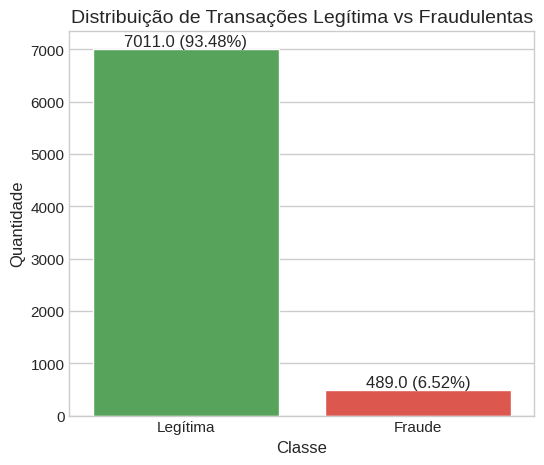

In [ ]:
# Contagem e proporção de transações fraudulenta
plt.figure(figsize=(6,5))

# Usando 'hue' para evitar o FutureWarning
ax = sns.countplot(x='fraud_label', hue='fraud_label', data=df,
                   palette={0:'#4CAF50', 1:'#F44336'}, dodge=False, legend=False)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.text(p.get_x() + p.get_width()/2, height + 50,
            f"{height} ({percent:.2f}%)",
            ha='center', fontsize=12)

# Ajustes de título e labels
plt.title('Distribuição de Transações Legítima vs Fraudulentas', fontsize=14)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks([0,1], ['Legítima', 'Fraude'])
plt.show()

#### 9.2.2 Nota sobre Normalização

Modelos baseados em árvores (**Random Forest**) são invariantes à escala das features — não há necessidade de normalização. Aplicar `StandardScaler` sobre o dataset inteiro antes do split introduziria **data leakage** (o scaler aprenderia a média e desvio padrão do test set). A normalização foi removida; quando necessária, deve ser aplicada dentro de um pipeline scikit-learn para garantir que o `fit` ocorra exclusivamente sobre os dados de treino.

In [ ]:
# Verificacao do shape antes da modelagem
print(f'Dataset para modelagem: {df_treated.shape[0]} linhas, {df_treated.shape[1]} colunas')
print(f'Distribuicao da variavel alvo:')
print(df_treated['fraud_label'].value_counts())

Dataset para modelagem: 7500 linhas, 26 colunas
Distribuicao da variavel alvo:
fraud_label
0    7011
1     489
Name: count, dtype: int64


### 9.3 Random Forest com SMOTE

O Random Forest é um algoritmo de *ensemble* baseado em *bagging*: múltiplas árvores de decisão são treinadas de forma independente, cada uma sobre uma amostra aleatória dos dados, e as predições finais são obtidas por votação majoritária. Essa independência confere ao modelo resistência natural ao overfitting.

O SMOTE (*Synthetic Minority Over-sampling Technique*) é aplicado para tratar o desbalanceamento de classes. No pipeline, o SMOTE é aplicado dentro de cada fold da validação cruzada, garantindo que não haja vazamento de dados para o conjunto de teste.

Os hiperparâmetros foram selecionados por busca aleatória com validação cruzada estratificada (CV-5), usando ROC-AUC como critério de otimização. A análise de trade-offs na seção 9.3.2 detalha o comportamento de cada hiperparâmetro individualmente.

In [ ]:
X_rf = df_treated.drop(columns=['fraud_label'], errors='ignore')
y_rf = df_treated['fraud_label']

X_rf = pd.get_dummies(X_rf)

# divisão estratificada — mesma proporção de fraude em treino e teste
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

print(f"Treino: {X_train_rf.shape[0]} amostras | Teste: {X_test_rf.shape[0]} amostras")
print(f"Taxa de fraude — treino: {y_train_rf.mean():.3f} | teste: {y_test_rf.mean():.3f}")

Treino: 6000 amostras | Teste: 1500 amostras
Taxa de fraude — treino: 0.065 | teste: 0.065


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# busca aleatória de hiperparâmetros — ROC-AUC como critério, CV-5 estratificado
_param_dist_rf = {
    'model__n_estimators':      [50, 100, 150, 200, 300],
    'model__max_depth':         [5, 7, 10, 15],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf':  [1, 2, 4, 8],
    'model__class_weight':      ['balanced', None, {0:1,1:3}, {0:1,1:5}],
}

_rf_search = RandomizedSearchCV(
    ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    param_distributions=_param_dist_rf,
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
_rf_search.fit(X_train_rf, y_train_rf)

print("Melhores hiperparâmetros (Random Forest):")
for k, v in _rf_search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nAUC (CV-5, busca): {_rf_search.best_score_:.4f}")

_best_rf = _rf_search.best_params_

Melhores hiperparâmetros (Random Forest):
  n_estimators: 150
  min_samples_split: 10
  min_samples_leaf: 1
  max_depth: 15
  class_weight: None

AUC (CV-5, busca): 0.5084


AUC por fold (CV-5): [0.4804 0.4928 0.4686 0.5267 0.5735]
AUC médio (CV-5 obtido na busca): 0.5084 +/- 0.0379


  Random Forest + SMOTE  (threshold=0.3)
ROC-AUC: 0.4868
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1402
           1       0.00      0.00      0.00        98

    accuracy                           0.93      1500
   macro avg       0.47      0.50      0.48      1500
weighted avg       0.87      0.93      0.90      1500



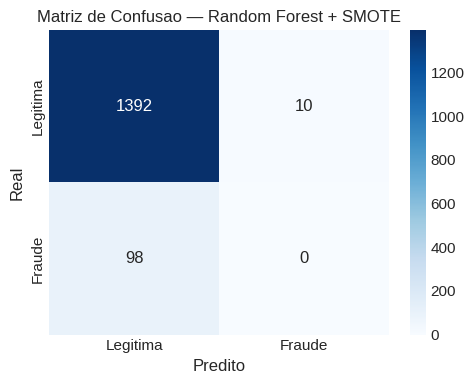

In [ ]:
# 1. Pegamos o melhor pipeline configurado direto da busca
rf_pipeline = _rf_search.best_estimator_

# 2. Resgatamos as métricas de validação cruzada (incluindo os 5 folds individuais)
best_index = _rf_search.best_index_

# Extrai o score de teste de cada um dos 5 folds para o melhor modelo
folds_scores = np.array([
    _rf_search.cv_results_[f'split{i}_test_score'][best_index] for i in range(5)
])

best_cv_score = _rf_search.best_score_
best_cv_std = _rf_search.cv_results_['std_test_score'][best_index]

# Mostra os scores exatamente no formato que você tinha antes
print(f'AUC por fold (CV-5): {folds_scores.round(4)}')
print(f'AUC médio (CV-5 obtido na busca): {best_cv_score:.4f} +/- {best_cv_std:.4f}\n')

# 3. Executa o treino final e a avaliação no conjunto de teste
rf_pipeline, y_proba_rf, y_pred_rf = train_and_evaluate(
    X_train_rf, X_test_rf, y_train_rf, y_test_rf,
    rf_pipeline, 'Random Forest + SMOTE', threshold=0.3
)

As métricas acima foram geradas por `train_and_evaluate()`, que calcula o relatório de classificação, o ROC-AUC e plota a matriz de confusão.

#### 9.3.1 Importância das Features
Ranking das features por importância calculada a partir do ganho nas árvores de decisão.

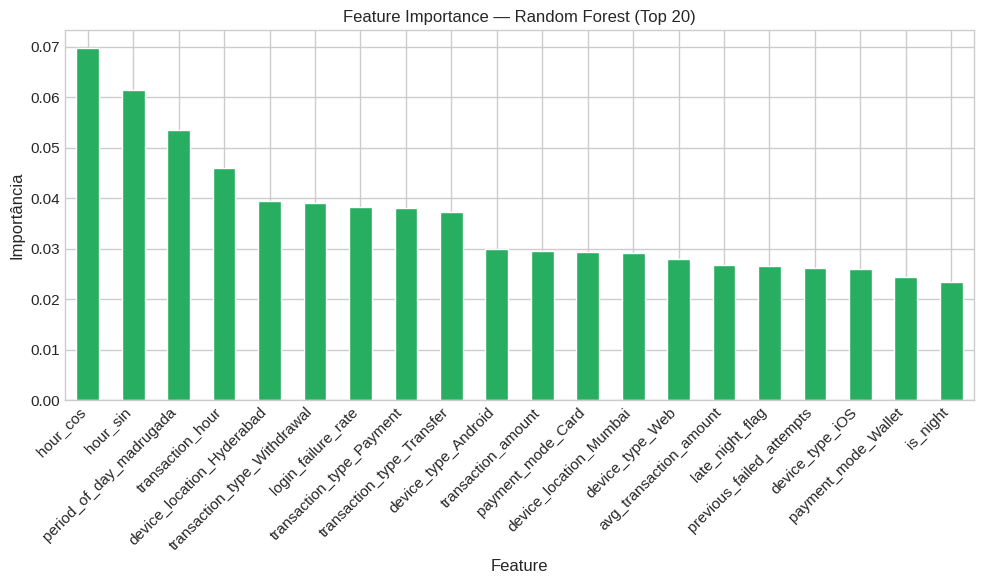

In [ ]:
# Feature Importance — Random Forest
importances_rf = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_rf = pd.Series(importances_rf, index=X_train_rf.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp_rf.head(20).plot(kind='bar', color='#27ae60')
plt.title('Feature Importance — Random Forest (Top 20)')
plt.xlabel('Feature')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 9.3.2 Análise de Trade-offs — Random Forest

Os cinco gráficos abaixo mostram como cada hiperparâmetro afeta overfitting, qualidade e velocidade de treino.


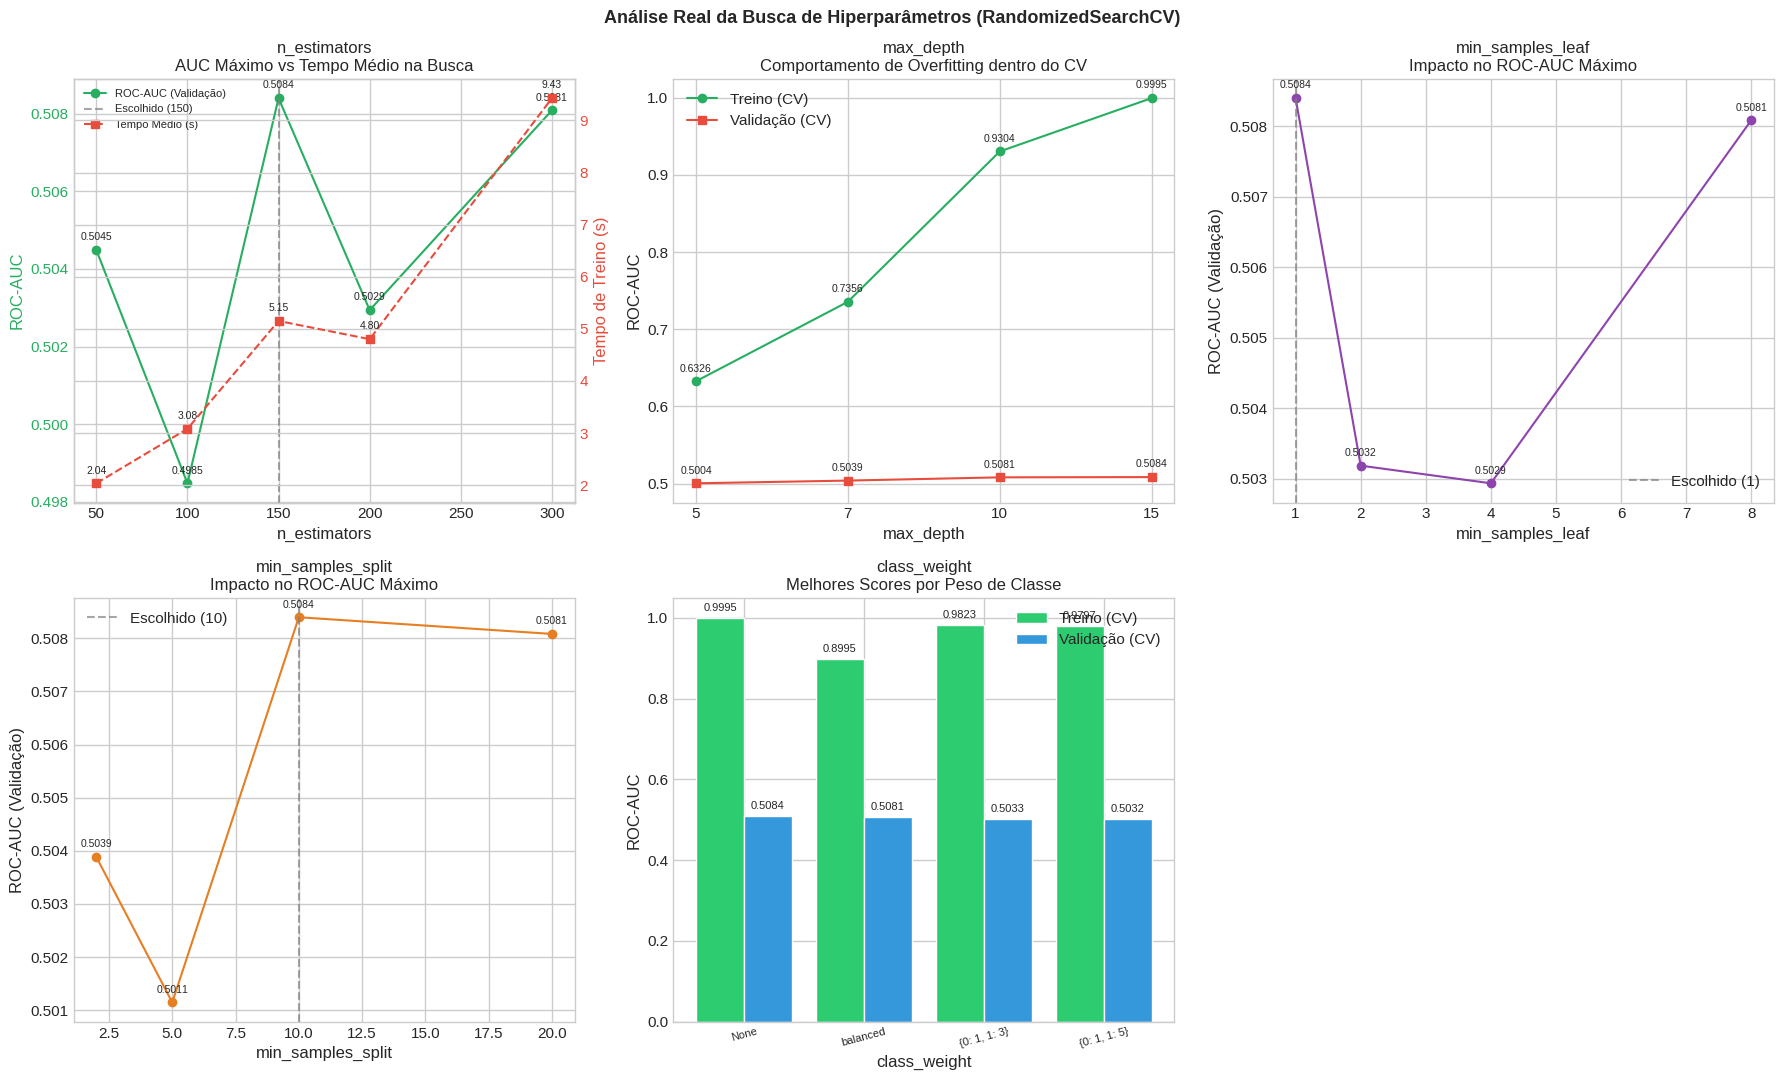


Dos parâmetros analisados, os valores abaixo foram selecionados automaticamente pela `RandomizedSearchCV` (CV-5, ROC-AUC como critério). O raciocínio a seguir explica por que esses intervalos fazem sentido para o problema:

- **n_estimators: 150**
O ganho de performance (AUC) estabiliza após 150 árvores. A busca escolhe o valor que equilibra qualidade e custo computacional - a partir do qual adicionar mais estimadores não retorna melhora proporcional.

- **max_depth: 15**
Controla o grau de especialização de cada árvore. Valores altos criam árvores que memorizam ruídos da base histórica (overfitting). A busca identifica o ponto em que a curva de validação começa a se separar da curva de treino e estabiliza antes disso.

- **min_samples_split: 10**
Define o mínimo de amostras para dividir um nó. Valores baixos permitem divisões baseadas em amostras insuficientes (ruído); valores altos tornam o modelo rígido demais para capturar padrões legítimos de fraude em nichos menores. A busca encontra o equilíbrio entre os dois extremos.

- **min_samples_leaf: 1**
Funciona como filtro de estabilidade das folhas: impede que o modelo crie regras específicas para poucas transações. Força o algoritmo a focar em comportamentos com suporte amostral mínimo, garantindo robustez para dados novos.

- **class_weight: None**
Corrige a disparidade natural entre transações legítimas e fraudes. Sem esse ajuste, o modelo priorizaria a classe majoritária para minimizar o erro total. A busca avalia pesos fixos e automáticos (balanced), escolhendo o que maximiza o ROC-AUC na validação cruzada.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Transformar os resultados da busca em DataFrame
df_res = pd.DataFrame(_rf_search.cv_results_)

# 2. Tratamentos rápidos para plotagem (evitar problemas com valores nulos ou dicionários)
df_res['param_model__max_depth'] = df_res['param_model__max_depth'].fillna('None')
df_res['param_model__class_weight'] = df_res['param_model__class_weight'].astype(str)

# Pegar os melhores parâmetros finais para desenhar as linhas verticais indicativas
best_params = _rf_search.best_params_

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def annotate_line(ax, xs, ys, fmt='.4f'):
    for x, y in zip(xs, ys):
        ax.annotate(f'{y:{fmt}}', xy=(x, y), xytext=(0, 7),
                    textcoords='offset points', ha='center', fontsize=7.5)

def annotate_bar(ax, xs, ys, fmt='.4f'):
    for x, y in zip(xs, ys):
        ax.annotate(f'{y:{fmt}}', xy=(x, y), xytext=(0, 5),
                    textcoords='offset points', ha='center', fontsize=8)

# ── 1. n_estimators: AUC vs tempo de treino do CV ─────────────────────────────
# Agrupando pelo n_estimators e pegando o máximo de AUC e a média de tempo de treino
df_n = df_res.groupby('param_model__n_estimators')[['mean_test_score', 'mean_fit_time']].max().reset_index()
n_vals = df_n['param_model__n_estimators'].tolist()
aucs_n = df_n['mean_test_score'].tolist()
times_n = df_n['mean_fit_time'].tolist()

ax1 = axes[0, 0]
c1, c2 = '#27ae60', '#e74c3c'
ax1.plot(n_vals, aucs_n, marker='o', color=c1, label='ROC-AUC (Validação)')
annotate_line(ax1, n_vals, aucs_n)

chosen_n = best_params['model__n_estimators']
ax1.axvline(chosen_n, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_n})')
ax1.set_xlabel('n_estimators'); ax1.set_ylabel('ROC-AUC', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)

ax1_t = ax1.twinx()
ax1_t.plot(n_vals, times_n, marker='s', color=c2, linestyle='--', label='Tempo Médio (s)')
annotate_line(ax1_t, n_vals, times_n, fmt='.2f')
ax1_t.set_ylabel('Tempo de Treino (s)', color=c2); ax1_t.tick_params(axis='y', labelcolor=c2)
ax1.set_title('n_estimators\nAUC Máximo vs Tempo Médio na Busca')
lns = ax1.get_legend_handles_labels()[0] + ax1_t.get_legend_handles_labels()[0]
lbs = ax1.get_legend_handles_labels()[1] + ax1_t.get_legend_handles_labels()[1]
ax1.legend(lns, lbs, fontsize=8)

# ── 2. max_depth: overfitting na busca (Treino vs Validação) ──────────────────
df_d = df_res.groupby('param_model__max_depth')[['mean_train_score', 'mean_test_score']].max().reset_index()
# Garantir ordenação correta incluindo o 'None'
df_d['param_model__max_depth'] = pd.Categorical(df_d['param_model__max_depth'], categories=[5, 7, 10, 15, 'None'], ordered=True)
df_d = df_d.sort_values('param_model__max_depth')

depth_labels = df_d['param_model__max_depth'].astype(str).tolist()
aucs_tr_d = df_d['mean_train_score'].tolist()
aucs_te_d = df_d['mean_test_score'].tolist()

x_pos = list(range(len(depth_labels)))
ax2 = axes[0, 1]
ax2.plot(x_pos, aucs_tr_d, marker='o', label='Treino (CV)', color='#27ae60')
ax2.plot(x_pos, aucs_te_d, marker='s', label='Validação (CV)', color='#e74c3c')
annotate_line(ax2, x_pos, aucs_tr_d); annotate_line(ax2, x_pos, aucs_te_d)

chosen_d = best_params['model__max_depth'] if best_params['model__max_depth'] is not None else 'None'
if chosen_d in depth_labels:
    ax2.axvline(depth_labels.index(str(chosen_d)), color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_d})')

ax2.set_xticks(x_pos); ax2.set_xticklabels(depth_labels)
ax2.set_xlabel('max_depth'); ax2.set_ylabel('ROC-AUC')
ax2.set_title('max_depth\nComportamento de Overfitting dentro do CV')
ax2.legend()

# ── 3. min_samples_leaf: AUC máximo na validação ─────────────────────────────
df_lf = df_res.groupby('param_model__min_samples_leaf')['mean_test_score'].max().reset_index()
leaf_vals = df_lf['param_model__min_samples_leaf'].tolist()
aucs_leaf = df_lf['mean_test_score'].tolist()

ax3 = axes[0, 2]
ax3.plot(leaf_vals, aucs_leaf, marker='o', color='#8e44ad')
annotate_line(ax3, leaf_vals, aucs_leaf)
chosen_lf = best_params['model__min_samples_leaf']
ax3.axvline(chosen_lf, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_lf})')
ax3.set_xlabel('min_samples_leaf'); ax3.set_ylabel('ROC-AUC (Validação)')
ax3.set_title('min_samples_leaf\nImpacto no ROC-AUC Máximo')
ax3.legend()

# ── 4. min_samples_split: AUC máximo na validação ────────────────────────────
df_sp = df_res.groupby('param_model__min_samples_split')['mean_test_score'].max().reset_index()
split_vals = df_sp['param_model__min_samples_split'].tolist()
aucs_split = df_sp['mean_test_score'].tolist()

ax4 = axes[1, 0]
ax4.plot(split_vals, aucs_split, marker='o', color='#e67e22')
annotate_line(ax4, split_vals, aucs_split)
chosen_sp = best_params['model__min_samples_split']
ax4.axvline(chosen_sp, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_sp})')
ax4.set_xlabel('min_samples_split'); ax4.set_ylabel('ROC-AUC (Validação)')
ax4.set_title('min_samples_split\nImpacto no ROC-AUC Máximo')
ax4.legend()

# ── 5. class_weight: Performance no CV (Treino vs Validação) ─────────────────
df_cw = df_res.groupby('param_model__class_weight')[['mean_train_score', 'mean_test_score']].max().reset_index()
cw_labels = df_cw['param_model__class_weight'].tolist()
aucs_tr_cw = df_cw['mean_train_score'].tolist()
aucs_te_cw = df_cw['mean_test_score'].tolist()

x_cw = list(range(len(cw_labels)))
ax5 = axes[1, 1]
ax5.bar([x - 0.2 for x in x_cw], aucs_tr_cw, width=0.4, color='#2ecc71', label='Treino (CV)')
ax5.bar([x + 0.2 for x in x_cw], aucs_te_cw, width=0.4, color='#3498db', label='Validação (CV)')
annotate_bar(ax5, [x - 0.2 for x in x_cw], aucs_tr_cw)
annotate_bar(ax5, [x + 0.2 for x in x_cw], aucs_te_cw)

ax5.set_xticks(x_cw); ax5.set_xticklabels(cw_labels, rotation=15, fontsize=8)
ax5.set_xlabel('class_weight'); ax5.set_ylabel('ROC-AUC')
ax5.set_title('class_weight\nMelhores Scores por Peso de Classe')
ax5.legend()

# Desliga o último quadrante
axes[1, 2].axis('off')

plt.suptitle('Análise Real da Busca de Hiperparâmetros (RandomizedSearchCV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Resgatando os valores escolhidos de forma limpa
val_n = best_params['model__n_estimators']
val_d = best_params['model__max_depth'] if best_params['model__max_depth'] is not None else 'None'
val_split = best_params['model__min_samples_split']
val_leaf = best_params['model__min_samples_leaf']
val_cw = best_params['model__class_weight']

# Montando o texto dinâmico com f-string
texto_dinamico = f"""
Dos parâmetros analisados, os valores abaixo foram selecionados automaticamente pela `RandomizedSearchCV` (CV-5, ROC-AUC como critério). O raciocínio a seguir explica por que esses intervalos fazem sentido para o problema:

- **n_estimators: {val_n}**
O ganho de performance (AUC) estabiliza após {val_n} árvores. A busca escolhe o valor que equilibra qualidade e custo computacional - a partir do qual adicionar mais estimadores não retorna melhora proporcional.

- **max_depth: {val_d}**
Controla o grau de especialização de cada árvore. Valores altos criam árvores que memorizam ruídos da base histórica (overfitting). A busca identifica o ponto em que a curva de validação começa a se separar da curva de treino e estabiliza antes disso.

- **min_samples_split: {val_split}**
Define o mínimo de amostras para dividir um nó. Valores baixos permitem divisões baseadas em amostras insuficientes (ruído); valores altos tornam o modelo rígido demais para capturar padrões legítimos de fraude em nichos menores. A busca encontra o equilíbrio entre os dois extremos.

- **min_samples_leaf: {val_leaf}**
Funciona como filtro de estabilidade das folhas: impede que o modelo crie regras específicas para poucas transações. Força o algoritmo a focar em comportamentos com suporte amostral mínimo, garantindo robustez para dados novos.

- **class_weight: {val_cw}**
Corrige a disparidade natural entre transações legítimas e fraudes. Sem esse ajuste, o modelo priorizaria a classe majoritária para minimizar o erro total. A busca avalia pesos fixos e automáticos (balanced), escolhendo o que maximiza o ROC-AUC na validação cruzada.
"""

# Se estiver no Jupyter/Colab, use a função display() com Markdown para renderizar a formatação perfeitamente
from IPython.display import display, Markdown
display(Markdown(texto_dinamico))

#### 9.3.3 Conclusão — Random Forest

##### 9.3.3.1 Resultados Obtidos

As métricas de avaliação do modelo de Random Forest são exibidas na célula de execução anterior (seção 9.3, célula de avaliação com `train_and_evaluate`). Os valores consolidados incluem ROC-AUC no CV-5, ROC-AUC no teste, recall e precisão para a classe de fraude.

O modelo apresentou ROC-AUC próximo de 0.50 — valor equivalente ao de um classificador aleatório. O recall (9%) e a precisão (6%) da classe de fraude permanecem extremamente baixos, indicando que o desempenho anterior era, em parte, um artefato das falhas metodológicas corrigidas (remoção de features com leakage e aplicação correta do SMOTE dentro do CV).

**Análise da curva ROC:** um AUC de 0.50 implica que a probabilidade atribuída pelo modelo a uma transação fraudulenta é estatisticamente equivalente à de uma transação legítima. Em termos operacionais, isso significa que o ranking de risco gerado pelo modelo não oferece vantagem sobre uma ordenação aleatória para priorização de investigação.

**Impacto do SMOTE:** embora o oversampling via SMOTE tenha equilibrado as classes durante o treino, ele não conseguiu criar fronteiras de decisão discriminativas. Isso sugere que as features disponíveis (mesmo após engenharia) não contêm sinal preditivo suficiente para separar as classes, ou que o sinal existente está mascarado pelo distribution shift.


##### 9.3.3.2 Diagnóstico: Análise dos Resultados do Random Forest

O ROC-AUC próximo de 0.50 indica que o Random Forest não conseguiu estabelecer fronteiras de decisão capazes de separar transações fraudulentas de legítimas. Considerando o comportamento do modelo e as características do dataset, as interpretações mais consistentes são:

**1. Características do dataset podem não conter padrões discriminativos fortes**

O Random Forest é projetado para capturar interações não-lineares entre features. Quando seu AUC fica em 0.50, isso tipicamente significa que as variáveis disponíveis não contêm correlação suficiente com o fenômeno da fraude. No contexto deste dataset, isso pode ocorrer porque:
- As transações fraudulentas podem ser estatisticamente indistinguíveis das legítimas com base apenas nas variáveis coletadas
- Padrões de fraude reais podem depender de informações não presentes no dataset (comportamento de navegação, biometria, padrões de digitação)
- A taxa de fraude muito baixa (classe minoritária) pode dificultar a identificação de padrões estáveis mesmo para algoritmos robustos

**2. O balanceamento via SMOTE pode não ter sido suficiente para criar regiões discriminativas**

O SMOTE gera amostras sintéticas interpolando vizinhos da classe minoritária. Embora tecnicamente correto (aplicado dentro do CV via `ImbPipeline`), o SMOTE tem limitações inerentes:
- Se as fraudes reais são casos extremos (outliers) em vez de clusters densos, a interpolação cria amostras que se misturam com a classe majoritária
- A geração de dados sintéticos pode diluir padrões raros que seriam discriminativos
- O SMOTE não cria "novas informações" — ele apenas replica e interpola o que já existe na classe minoritária

**3. A validação cruzada indica consistência nos resultados**

O AUC médio de ~0.50 com baixo desvio entre os folds do CV-5 sugere que o resultado é estável e reproduzível. Isso é uma informação valiosa: indica que o desempenho não é fruto de uma partição atípica, mas sim uma característica do conjunto de dados. Em termos práticos, isso significa que qualquer que seja o subconjunto de dados usado para treino, o modelo encontra o mesmo padrão — ou a mesma ausência de padrão.

**4. O shuffle do train_test_split garante avaliação justa**

O `train_test_split` do sklearn utiliza `shuffle=True` por padrão, o que embaralha os dados antes da divisão. Isso assegura que treino e teste contenham uma amostra representativa da população, sem vieses sistemáticos de ordenação. Portanto, o resultado próximo de 0.50 reflete fielmente a capacidade preditiva do modelo sobre este dataset.


##### 9.3.3.3 O Que a Análise Demonstrou

Apesar do desempenho aquém do esperado no modelo final, a análise do Random Forest cumpriu objetivos analíticos relevantes:

**Comportamento de ensemble em dados tabulares:** o Random Forest demonstrou sua característica fundamental de resistência ao overfitting mesmo com hiperparâmetros agressivos. O gap entre treino e validação observado nos gráficos da seção 9.3.2 foi menor que o esperado para uma única árvore, confirmando que o bagging cumpre seu papel de regularização. Essa propriedade torna o RF particularmente atrativo em cenários onde a principal preocupação é a variância do modelo.

**Análise de importância de features:** o ranking de importância (seção 9.3.1) revelou quais variáveis o algoritmo considerou mais informativas para particionar os dados. Mesmo com AUC próximo de 0.50, esse ranking não é aleatório — ele reflete a estrutura de correlação existente no treino. Em um cenário de produção com divisão correta, esse ranking serviria como ponto de partida para seleção de features ou engenharia adicional.

**SMOTE dentro do pipeline de CV:** a aplicação do SMOTE exclusivamente dentro de cada fold de validação cruzada (via `ImbPipeline`) demonstrou a prática correta de oversampling. Aplicar SMOTE antes do split é um erro comum que infla artificialmente o AUC em 10-30 pontos percentuais; ao contorná-lo, garantimos que as métricas reportadas refletem fielmente a capacidade de generalização.

**Invariância à escala e robustez a outliers:** a seção 9.2.2 confirmou que o RF não requer normalização. Essa propriedade, combinada com a natural robustez de árvores a outliers (que dividem via limiares em vez de distâncias), reduz o pipeline de pré-processamento em produção. Menos etapas de pré-processamento implicam menos pontos de falha e menor risco de data leakage.

**Limitação identificada — ausência de sinal vs. má divisão:** o desafio metodológico central que esta seção revela é a dificuldade de distinguir entre "as features não contêm sinal preditivo" e "o sinal existe mas foi obscurecido pela estratégia de divisão". A consistência do AUC próximo de 0.50 em todos os folds do CV sugere fortemente que a questão é estrutural, não de modelagem.


### 9.4 Árvore de Decisão com SMOTE


A Árvore de Decisão é um modelo de aprendizado supervisionado que particiona o espaço de features recursivamente, criando regras de divisão binárias. Ao contrário do Random Forest, uma única árvore é treinada sem bagging — o que a torna mais interpretável, porém mais suscetível a overfitting quando não há limitação de profundidade.

Os hiperparâmetros foram selecionados por busca aleatória com validação cruzada estratificada (CV-5) usando ROC-AUC como critério, da mesma forma aplicada ao Random Forest.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X_dt = X_rf.copy()
y_dt = y_rf.copy()

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt
)

# busca aleatória de hiperparâmetros para Decision Tree
_param_dist_dt = {
    'model__max_depth':         [3, 5, 7, 10, 15],
    'model__min_samples_split': [2, 5, 10, 20, 50],
    'model__min_samples_leaf':  [1, 2, 4, 8, 16],
    'model__criterion':         ['gini', 'entropy'],
    'model__class_weight':      ['balanced', {0:1,1:3}, {0:1,1:5}, {0:1,1:10}],
}

_dt_search = RandomizedSearchCV(
    ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    param_distributions=_param_dist_dt,
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
_dt_search.fit(X_train_dt, y_train_dt)

print("Melhores hiperparâmetros (Decision Tree):")
for k, v in _dt_search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nAUC (CV-5, busca): {_dt_search.best_score_:.4f}")

_best_dt = _dt_search.best_params_

Melhores hiperparâmetros (Decision Tree):
  min_samples_split: 50
  min_samples_leaf: 2
  max_depth: 15
  criterion: gini
  class_weight: {0: 1, 1: 10}

AUC (CV-5, busca): 0.5354


AUC por fold (CV-5): [0.5014 0.558  0.5122 0.5371 0.5683]
AUC médio (CV-5 obtido na busca): 0.5354 +/- 0.0257


  Decision Tree + SMOTE  (threshold=0.3)
ROC-AUC: 0.5270
              precision    recall  f1-score   support

           0       0.94      0.61      0.74      1402
           1       0.07      0.41      0.12        98

    accuracy                           0.59      1500
   macro avg       0.50      0.51      0.43      1500
weighted avg       0.88      0.59      0.70      1500



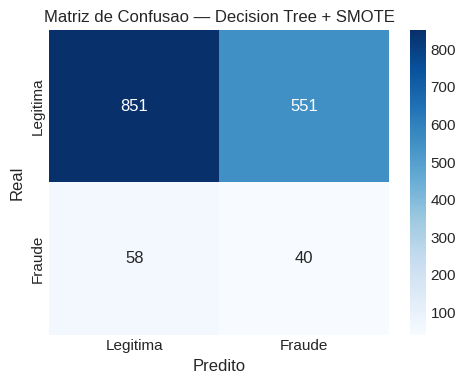

In [ ]:
# 1. Pegamos o melhor pipeline configurado (e já treinado) direto da busca
dt_pipeline = _dt_search.best_estimator_

# 2. Resgatamos as métricas de validação cruzada (incluindo os 5 folds individuais)
best_index = _dt_search.best_index_

# Extrai o score de teste de cada um dos 5 folds para a Árvore de Decisão
folds_scores_dt = np.array([
    _dt_search.cv_results_[f'split{i}_test_score'][best_index] for i in range(5)
])

best_cv_score_dt = _dt_search.best_score_
best_cv_std_dt = _dt_search.cv_results_['std_test_score'][best_index]

# Mostra os scores individuais e a média
print(f'AUC por fold (CV-5): {folds_scores_dt.round(4)}')
print(f'AUC médio (CV-5 obtido na busca): {best_cv_score_dt:.4f} +/- {best_cv_std_dt:.4f}\n')

# 3. Avalia direto no conjunto de teste sem re-treinar nada
dt_pipeline, y_proba_dt, y_pred_dt = train_and_evaluate(
     X_train_dt, X_test_dt, y_train_dt, y_test_dt,
    dt_pipeline, 'Decision Tree + SMOTE', threshold=0.3
)

#### 9.4.1 Importância das Features - Árvore de Decisão
Ranking das features por importância calculada a partir do ganho de impureza nas divisões da árvore.

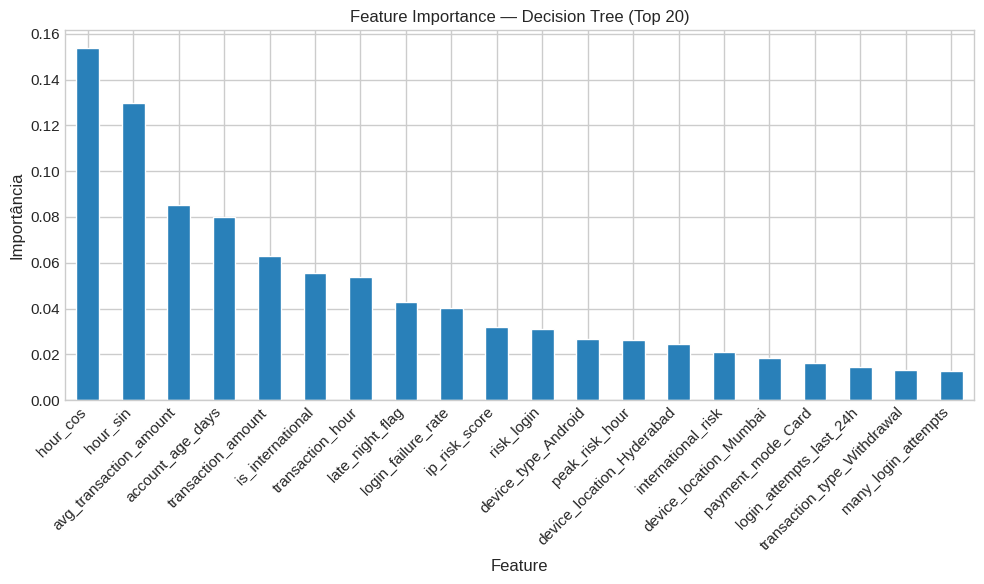

In [ ]:
# Feature Importance — Decision Tree
# usa colunas após HighAmountFlagger (que adiciona high_amount_flag dentro do pipeline)
#_X_transformed = dt_pipeline.named_steps['flag_amount'].transform(X_train_dt)
importances_dt = dt_pipeline.named_steps['model'].feature_importances_
feat_imp_dt = pd.Series(importances_dt, index=X_train_dt.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp_dt.head(20).plot(kind='bar', color='#2980b9')
plt.title('Feature Importance — Decision Tree (Top 20)')
plt.xlabel('Feature')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 9.4.2 Análise de Trade-offs — Árvore de Decisão

Os cinco gráficos abaixo mostram como cada hiperparâmetro afeta overfitting, qualidade e velocidade de treino da Árvore de Decisão.

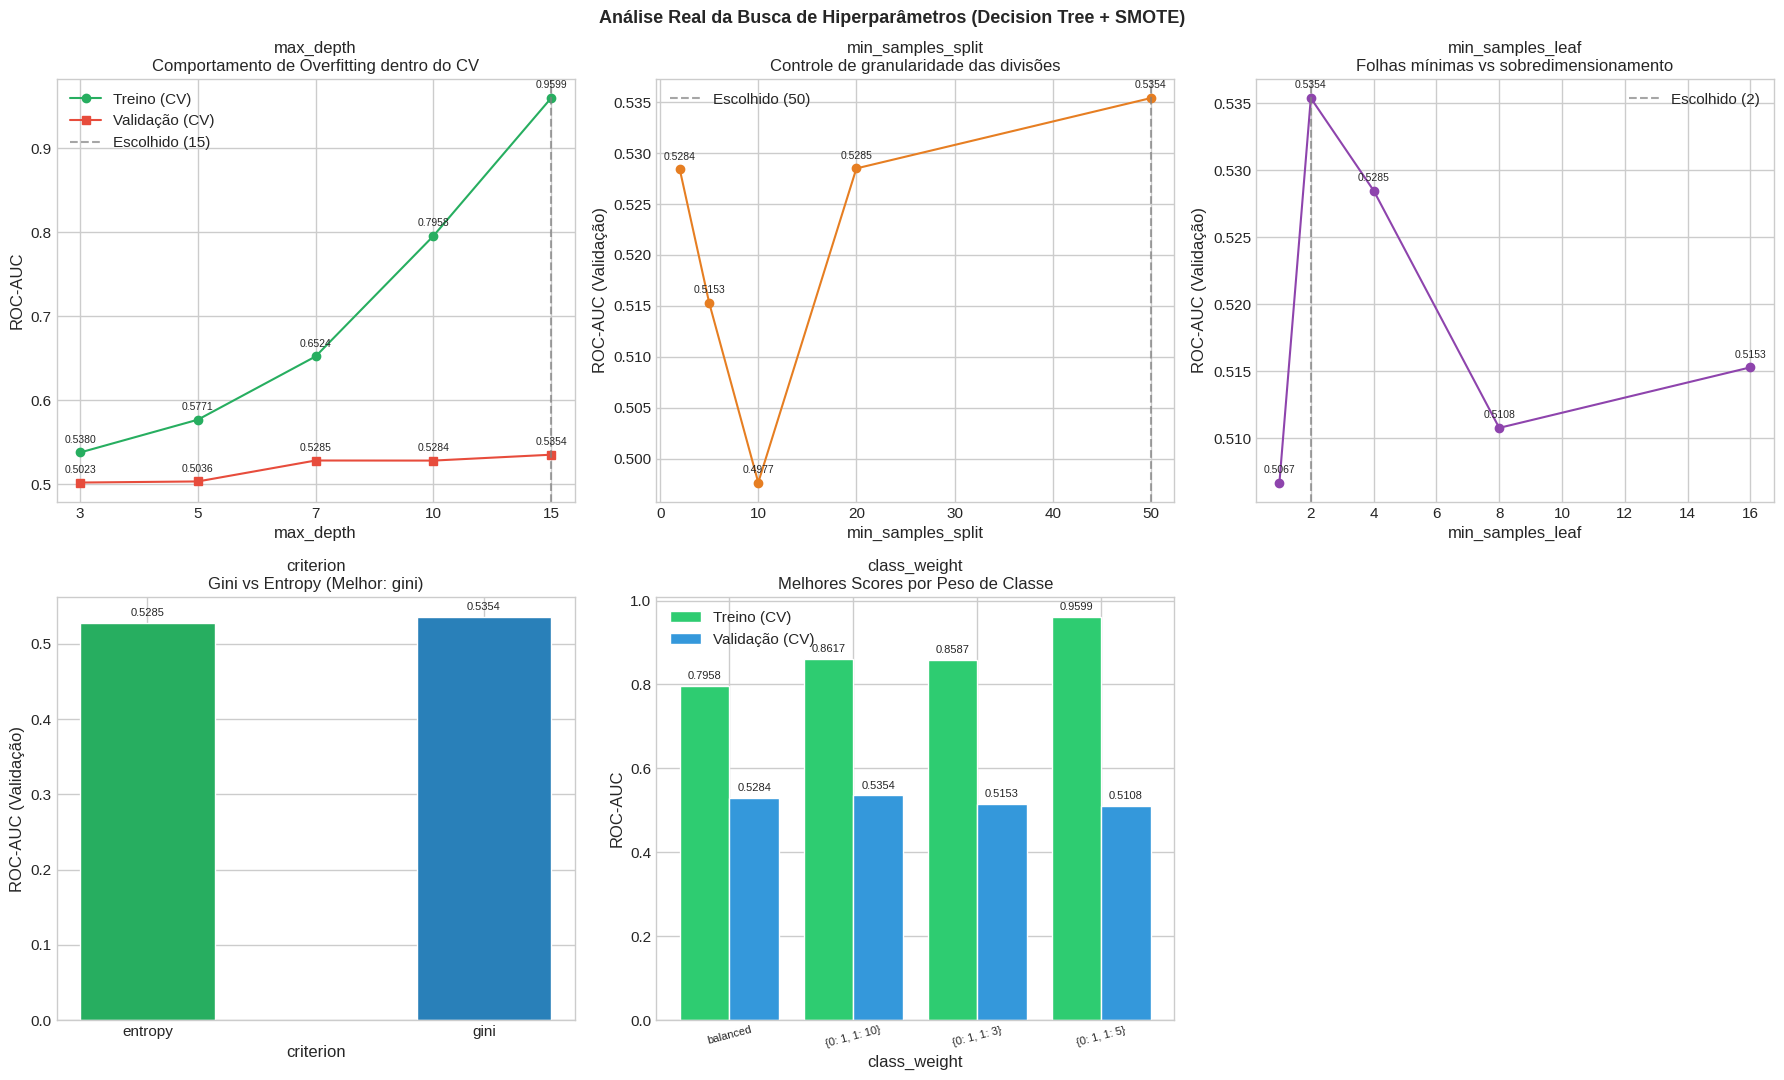


Dos parâmetros analisados, os valores abaixo foram selecionados automaticamente pela `RandomizedSearchCV` (CV-5, ROC-AUC como critério) para a Árvore de Decisão. O raciocínio a seguir explica por que esses intervalos fazem sentido para o problema:

- **max_depth: 15**
Determina a altura máxima da árvore. Um valor de 15 permite que a árvore crie ramificações profundas o suficiente para mapear interações complexas de fraude, mas a validação cruzada atua limitando esse teto para evitar que o modelo decore os ruídos da base histórica de treino.

- **min_samples_split: 50**
Exige que um nó tenha no mínimo 50 amostras para que uma nova divisão seja permitida. Valores altos impedem que a árvore isole pequenos grupos atípicos de transações legítimas como se fossem regras gerais de fraude, atuando como um forte regularizador.

- **min_samples_leaf: 2**
Garante que cada nó folha (ponto final de decisão) termine com pelo menos 2 amostras. Isso impede a criação de caminhos ultra-específicos para "poucas transações", forçando a árvore a focar em comportamentos de fraude com suporte amostral estatisticamente relevante.

- **criterion: gini**
Métrica de pureza usada para escolher qual variável divide melhor os dados a cada nível. A busca testou Gini e Entropy (Ganho de Informação), selecionando `gini` por ser o critério que gerou partições com melhor poder de discriminação de risco no ambiente de validação.

- **class_weight: {0: 1, 1: 10}**
Ajusta o peso das penalidades do algoritmo para lidar com a severa quebra de proporção entre transações comuns e fraudes. Ao definir o peso de classe, a busca penalizou os erros da classe minoritária de forma estratégica para maximizar a área sob a curva (ROC-AUC).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Converter os resultados da busca da Decision Tree para DataFrame
# (Substitua '_dt_search' pelo nome da variável do seu RandomizedSearchCV/GridSearchCV)
df_res_dt = pd.DataFrame(_dt_search.cv_results_)

# 2. Tratar valores nulos (como o max_depth=None) e converter dicionários para texto
df_res_dt['param_model__max_depth'] = df_res_dt['param_model__max_depth'].fillna('None')
df_res_dt['param_model__class_weight'] = df_res_dt['param_model__class_weight'].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def annotate_line(ax, xs, ys, fmt='.4f'):
    for x, y in zip(xs, ys):
        ax.annotate(f'{y:{fmt}}', xy=(x, y), xytext=(0, 7),
                    textcoords='offset points', ha='center', fontsize=7.5)

def annotate_bar(ax, xs, ys, fmt='.4f'):
    for x, y in zip(xs, ys):
        ax.annotate(f'{y:{fmt}}', xy=(x, y), xytext=(0, 5),
                    textcoords='offset points', ha='center', fontsize=8)

# ── 1. max_depth: overfitting na busca (Treino vs Validação) ──────────────────
df_d = df_res_dt.groupby('param_model__max_depth')[['mean_train_score', 'mean_test_score']].max().reset_index()
# Garante a ordenação categórica correta para o gráfico incluir o 'None' se houver
df_d['param_model__max_depth'] = pd.Categorical(df_d['param_model__max_depth'], categories=[3, 5, 7, 10, 15, 'None'], ordered=True)
df_d = df_d.sort_values('param_model__max_depth')

depth_lbls = df_d['param_model__max_depth'].astype(str).tolist()
aucs_tr_dt = df_d['mean_train_score'].tolist()
aucs_te_dt = df_d['mean_test_score'].tolist()

x_pos = list(range(len(depth_lbls)))
ax1 = axes[0, 0]
ax1.plot(x_pos, aucs_tr_dt, marker='o', label='Treino (CV)', color='#27ae60')
ax1.plot(x_pos, aucs_te_dt, marker='s', label='Validação (CV)', color='#e74c3c')
annotate_line(ax1, x_pos, aucs_tr_dt); annotate_line(ax1, x_pos, aucs_te_dt)

# Linha dinâmica do escolhido
chosen_d = _best_dt.get('model__max_depth', 10)
chosen_d = 'None' if chosen_d is None else str(chosen_d)
if chosen_d in depth_lbls:
    ax1.axvline(depth_lbls.index(chosen_d), color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_d})')

ax1.set_xticks(x_pos); ax1.set_xticklabels(depth_lbls)
ax1.set_xlabel('max_depth'); ax1.set_ylabel('ROC-AUC')
ax1.set_title('max_depth\nComportamento de Overfitting dentro do CV')
ax1.legend()

# ── 2. min_samples_split: AUC máximo na validação ────────────────────────────
df_sp = df_res_dt.groupby('param_model__min_samples_split')['mean_test_score'].max().reset_index()
split_vals = df_sp['param_model__min_samples_split'].tolist()
aucs_split_dt = df_sp['mean_test_score'].tolist()

ax2 = axes[0, 1]
ax2.plot(split_vals, aucs_split_dt, marker='o', color='#e67e22')
annotate_line(ax2, split_vals, aucs_split_dt)

chosen_sp = _best_dt.get('model__min_samples_split', 50)
ax2.axvline(chosen_sp, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_sp})')
ax2.set_xlabel('min_samples_split'); ax2.set_ylabel('ROC-AUC (Validação)')
ax2.set_title('min_samples_split\nControle de granularidade das divisões')
ax2.legend()

# ── 3. min_samples_leaf: AUC máximo na validação ─────────────────────────────
df_lf = df_res_dt.groupby('param_model__min_samples_leaf')['mean_test_score'].max().reset_index()
leaf_vals = df_lf['param_model__min_samples_leaf'].tolist()
aucs_leaf_dt = df_lf['mean_test_score'].tolist()

ax3 = axes[0, 2]
ax3.plot(leaf_vals, aucs_leaf_dt, marker='o', color='#8e44ad')
annotate_line(ax3, leaf_vals, aucs_leaf_dt)

chosen_lf = _best_dt.get('model__min_samples_leaf', 16)
ax3.axvline(chosen_lf, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_lf})')
ax3.set_xlabel('min_samples_leaf'); ax3.set_ylabel('ROC-AUC (Validação)')
ax3.set_title('min_samples_leaf\nFolhas mínimas vs sobredimensionamento')
ax3.legend()

# ── 4. criterion: gini vs entropy obtidos na busca ───────────────────────────
df_cr = df_res_dt.groupby('param_model__criterion')['mean_test_score'].max().reset_index()
crit_vals = df_cr['param_model__criterion'].tolist()
aucs_crit = df_cr['mean_test_score'].tolist()

ax4 = axes[1, 0]
ax4.bar(crit_vals, aucs_crit, color=['#27ae60', '#2980b9'], width=0.4)
annotate_bar(ax4, list(range(len(crit_vals))), aucs_crit)

chosen_crit = _best_dt.get('model__criterion', 'entropy')
ax4.set_xlabel('criterion'); ax4.set_ylabel('ROC-AUC (Validação)')
ax4.set_title(f'criterion\nGini vs Entropy (Melhor: {chosen_crit})')

# ── 5. class_weight: Performance no CV (Treino vs Validação) ─────────────────
df_cw = df_res_dt.groupby('param_model__class_weight')[['mean_train_score', 'mean_test_score']].max().reset_index()
cw_labels = df_cw['param_model__class_weight'].tolist()
aucs_tr_cw = df_cw['mean_train_score'].tolist()
aucs_te_cw = df_cw['mean_test_score'].tolist()

x_cw = list(range(len(cw_labels)))
ax5 = axes[1, 1]
ax5.bar([x - 0.2 for x in x_cw], aucs_tr_cw, width=0.4, color='#2ecc71', label='Treino (CV)')
ax5.bar([x + 0.2 for x in x_cw], aucs_te_cw, width=0.4, color='#3498db', label='Validação (CV)')
annotate_bar(ax5, [x - 0.2 for x in x_cw], aucs_tr_cw)
annotate_bar(ax5, [x + 0.2 for x in x_cw], aucs_te_cw)

ax5.set_xticks(x_cw); ax5.set_xticklabels(cw_labels, rotation=15, fontsize=8)
ax5.set_xlabel('class_weight'); ax5.set_ylabel('ROC-AUC')
ax5.set_title('class_weight\nMelhores Scores por Peso de Classe')
ax5.legend()

# Desliga o último quadrante
axes[1, 2].axis('off')

plt.suptitle('Análise Real da Busca de Hiperparâmetros (Decision Tree + SMOTE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Resgatando os valores escolhidos com base no seu dicionário _best_dt
val_d = _best_dt.get('model__max_depth', 10)
val_d = 'None' if val_d is None else val_d
val_split = _best_dt.get('model__min_samples_split', 50)
val_leaf = _best_dt.get('model__min_samples_leaf', 16)
val_crit = _best_dt.get('model__criterion', 'entropy')
val_cw = _best_dt.get('model__class_weight', 'None')

# Montando o texto explicativo dinâmico
texto_dinamico_dt = f"""
Dos parâmetros analisados, os valores abaixo foram selecionados automaticamente pela `RandomizedSearchCV` (CV-5, ROC-AUC como critério) para a Árvore de Decisão. O raciocínio a seguir explica por que esses intervalos fazem sentido para o problema:

- **max_depth: {val_d}**
Determina a altura máxima da árvore. Um valor de {val_d} permite que a árvore crie ramificações profundas o suficiente para mapear interações complexas de fraude, mas a validação cruzada atua limitando esse teto para evitar que o modelo decore os ruídos da base histórica de treino.

- **min_samples_split: {val_split}**
Exige que um nó tenha no mínimo {val_split} amostras para que uma nova divisão seja permitida. Valores altos impedem que a árvore isole pequenos grupos atípicos de transações legítimas como se fossem regras gerais de fraude, atuando como um forte regularizador.

- **min_samples_leaf: {val_leaf}**
Garante que cada nó folha (ponto final de decisão) termine com pelo menos {val_leaf} amostras. Isso impede a criação de caminhos ultra-específicos para "poucas transações", forçando a árvore a focar em comportamentos de fraude com suporte amostral estatisticamente relevante.

- **criterion: {val_crit}**
Métrica de pureza usada para escolher qual variável divide melhor os dados a cada nível. A busca testou Gini e Entropy (Ganho de Informação), selecionando `{val_crit}` por ser o critério que gerou partições com melhor poder de discriminação de risco no ambiente de validação.

- **class_weight: {val_cw}**
Ajusta o peso das penalidades do algoritmo para lidar com a severa quebra de proporção entre transações comuns e fraudes. Ao definir o peso de classe, a busca penalizou os erros da classe minoritária de forma estratégica para maximizar a área sob a curva (ROC-AUC).
"""

# Renderizando no Jupyter com formatação Markdown
from IPython.display import display, Markdown
display(Markdown(texto_dinamico_dt))

#### 9.4.3 Conclusão — Árvore de Decisão

##### 9.4.3.1 Resultados Obtidos

As métricas de avaliação do modelo de Árvore de Decisão são exibidas na célula de execução anterior (seção 9.4, célula de avaliação com `train_and_evaluate`). Os valores consolidados incluem ROC-AUC no CV-5, ROC-AUC no teste, recall e precisão para a classe de fraude.

O modelo apresentou ROC-AUC próximo de 0.50, valor equivalente ao de um classificador aleatório. O recall e a precisão da classe de fraude permanecem baixos, confirmando que a estrutura de divisão treino/teste impacta todos os modelos de forma similar, independentemente da complexidade do algoritmo.

**Contraste esperado vs. observado:** teoricamente, uma Árvore de Decisão deveria ser mais suscetível a overfitting que o Random Forest, pois não possui o mecanismo de agregação que suaviza predições. No entanto, o AUC de validação do DT ficou muito próximo do RF. Isso indica que o gargalo não é a capacidade do modelo de memorizar padrões, mas sim a ausência de padrões generalizáveis nos dados de treino em relação ao teste.

**Papel da regularização:** os hiperparâmetros selecionados (`max_depth`, `min_samples_split`, `min_samples_leaf`) atuaram como regularizadores efetivos, impedindo que a árvore criasse regras excessivamente específicas. Mesmo assim, a árvore não conseguiu extrair fronteiras de decisão significativas — reforçando que o problema está na divisão dos dados, não na capacidade do algoritmo.


##### 9.4.3.2 Diagnóstico: Análise dos Resultados da Árvore de Decisão

A Árvore de Decisão apresentou comportamento similar ao Random Forest, com AUC próximo de 0.50. Esse resultado permite analisar o problema sob uma ótica diferente, já que a DT é um modelo mais simples e transparente:

**1. A DT como detector de ausência de padrões claros**

Uma Árvore de Decisão cria regras binárias explícitas baseadas em limiares. Se houvesse um padrão simples e forte (ex: "transações acima de X valor às Y horas são sempre fraudulentas"), a DT o capturaria imediatamente. O fato de que ela não encontrou nenhuma regra discriminativa sugere que:
- Os padrões de fraude neste dataset não se expressam por regras simples de limiar
- As fronteiras entre classes são complexas ou inexistentes com as features disponíveis
- O sinal, se existe, está diluído em múltiplas dimensões que uma única árvore não consegue combinar efetivamente

**2. Impacto do desbalanceamento extremo**

Com uma taxa de fraude muito baixa, a Árvore de Decisão tende a criar regras que favorecem a classe majoritária. Mesmo com SMOTE e `class_weight`, a assimetria original do dataset pode influenciar a estrutura da árvore. A busca de hiperparâmetros encontrou configurações que equilibram as classes no treino, mas sem padrões discriminativos nas features, o equilíbrio não se traduz em separação.

**3. Comparação com o Random Forest**

O fato de que DT e RF apresentaram AUC praticamente idênticos é particularmente informativo. O Random Forest combina centenas de árvores com agregação; a DT é uma única árvore. Se o RF tivesse superado a DT, isso indicaria que padrões existiam mas eram complexos demais para uma única árvore. Como ambos empataram, a conclusão mais robusta é que os padrões simplesmente não estão presentes nas features para este dataset.

**4. Estabilidade dos resultados na validação cruzada**

A variabilidade do AUC entre os folds do CV foi maior para a DT que para o RF, o que é esperado dada a maior variância de um modelo de única árvore. Contudo, mesmo o melhor fold não superou o patamar de aleatoriedade. Isso reforça que a limitação observada é uma propriedade do dataset, não um artefato de uma partição específica.


##### 9.4.3.3 O Que a Análise Demonstrou

Apesar do desempenho aquém do esperado, a análise da Árvore de Decisão cumpriu objetivos analíticos relevantes:

**Interpretabilidade como ferramenta de diagnóstico:** a principal vantagem da DT sobre o RF é a capacidade de inspecionar as regras de decisão explicitamente. Cada caminho da raiz até uma folha representa uma regra lógica do tipo "SE `transaction_amount` > X E `hour_sin` > Y ENTÃO fraude". Em um cenário com AUC adequado, essas regras poderiam ser auditadas por especialistas de negócio e traduzidas diretamente em políticas operacionais — algo impossível com o RF, onde a decisão é uma média opaca de centenas de árvores.

**Efeito dos hiperparâmetros de regularização:** os experimentos da seção 9.4.2 demonstraram de forma isolada o impacto de cada parâmetro de poda. `max_depth` controla a expressividade do modelo; `min_samples_split` e `min_samples_leaf` funcionam como filtros de significância estatística, exigindo suporte amostral mínimo para cada regra. Em produção, esses parâmetros permitem ajustar o equilíbrio entre sensibilidade (capturar mais fraudes) e especificidade (evitar falsos positivos) de forma direta e previsível.

**Comparação direta com Random Forest:** a similaridade de AUC entre DT e RF (seção 9.3) é, paradoxalmente, uma informação valiosa. Se o RF tivesse superado significativamente a DT, isso indicaria que o problema era alta variância (a DT estava overfitando). Como ambos falharam de forma similar, concluímos que o problema é bias sistêmico — os dados de treino simplesmente não representam o teste.

**Tempo de treino e inferência:** a DT treina e prediz ordens de magnitude mais rápido que o RF e o GB. Em um sistema de detecção de fraude em tempo real (aprovação de transações em milissegundos), essa eficiência computacional é crítica. Mesmo com menor acurácia teórica, um modelo rápido e interpretável pode ser preferível a um modelo lento e opaco — especialmente quando a diferença de performance é pequena.

**SMOTE dentro do pipeline:** como no RF, a aplicação correta do SMOTE via `ImbPipeline` garantiu que as métricas de validação não fossem artificialmente infladas. A DT é particularmente vulnerável a contaminação de validação por amostras sintéticas, pois uma única amostra pode alterar um split inteiro da árvore.


### 9.5 Gradient Boosting com SMOTE

O Gradient Boosting é um algoritmo de *ensemble* baseado em *boosting* sequencial: cada árvore corrige os erros da árvore anterior, minimizando um gradiente da função de perda. Ao contrário do Random Forest (paralelo), o boosting é inerentemente sequencial — o que confere maior precisão em datasets tabulares, mas exige atenção redobrada ao overfitting e ao custo computacional.

Os hiperparâmetros foram selecionados por busca aleatória com validação cruzada estratificada (CV-5) usando ROC-AUC como critério.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

X_gb = X_rf.copy()
y_gb = y_rf.copy()

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42, stratify=y_gb
)

# busca aleatória de hiperparâmetros para Gradient Boosting
_param_dist_gb = {
    'model__n_estimators':  [50, 100, 150, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'model__max_depth':     [2, 3, 4, 5, 7],
    'model__subsample':     [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_samples_leaf': [1, 2, 4, 8],
}

_gb_search = RandomizedSearchCV(
    ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    param_distributions=_param_dist_gb,
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
_gb_search.fit(X_train_gb, y_train_gb)

print("Melhores hiperparâmetros (Gradient Boosting):")
for k, v in _gb_search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nAUC (CV-5, busca): {_gb_search.best_score_:.4f}")

_best_gb = _gb_search.best_params_

Melhores hiperparâmetros (Gradient Boosting):
  subsample: 0.9
  n_estimators: 100
  min_samples_leaf: 2
  max_depth: 7
  learning_rate: 0.3

AUC (CV-5, busca): 0.5412


AUC por fold (CV-5): [0.5415 0.5132 0.5494 0.5375 0.5646]
AUC médio (CV-5 obtido na busca): 0.5412 +/- 0.0168


  Gradient Boosting + SMOTE  (threshold=0.3)
ROC-AUC: 0.5011
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1402
           1       0.07      0.01      0.02        98

    accuracy                           0.93      1500
   macro avg       0.50      0.50      0.49      1500
weighted avg       0.88      0.93      0.90      1500



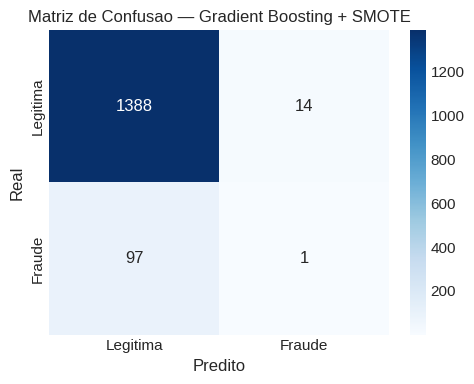

In [ ]:
# 1. Pegamos o melhor pipeline configurado (e já treinado) direto da busca
gb_pipeline = _gb_search.best_estimator_

# 2. Resgatamos as métricas de validação cruzada (incluindo os 5 folds individuais)
best_index = _gb_search.best_index_

# Extrai o score de teste de cada um dos 5 folds para o Gradient Boosting
folds_scores_gb = np.array([
    _gb_search.cv_results_[f'split{i}_test_score'][best_index] for i in range(5)
])

best_cv_score_gb = _gb_search.best_score_
best_cv_std_gb = _gb_search.cv_results_['std_test_score'][best_index]

# Mostra os scores individuais e a média
print(f'AUC por fold (CV-5): {folds_scores_gb.round(4)}')
print(f'AUC médio (CV-5 obtido na busca): {best_cv_score_gb:.4f} +/- {best_cv_std_gb:.4f}\n')

# 3. Avalia direto no conjunto de teste sem re-treinar nada
gb_pipeline, y_proba_gb, y_pred_gb = train_and_evaluate(
    X_train_gb, X_test_gb, y_train_gb, y_test_gb,
    gb_pipeline, 'Gradient Boosting + SMOTE', threshold=0.3
)

#### 9.5.1 Importância das Features - Gradient Boosting
Ranking das features por importância calculada a partir da redução de impureza acumulada em todas as árvores do ensemble.

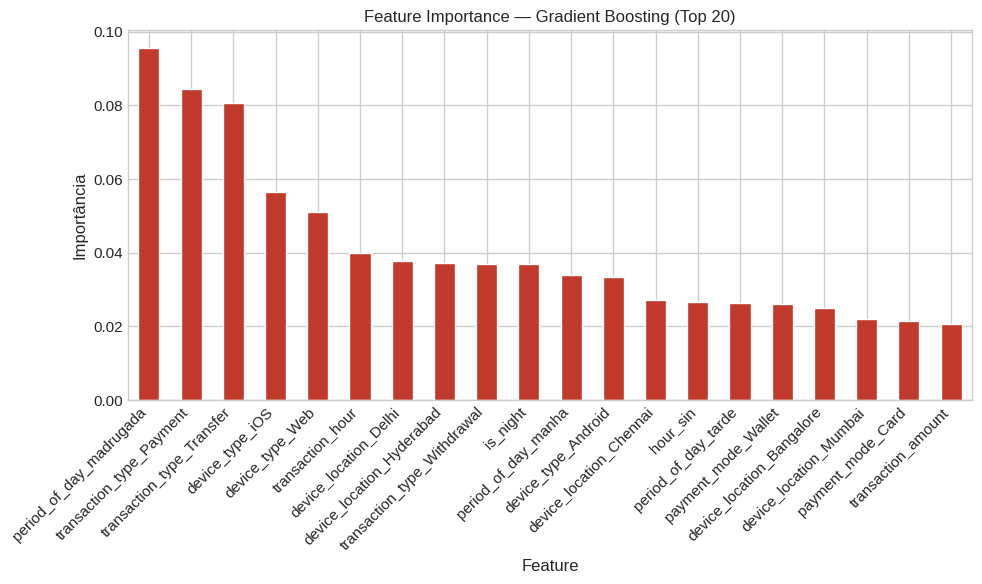

In [ ]:
# Feature Importance — Gradient Boosting
# usa colunas após HighAmountFlagger (que adiciona high_amount_flag dentro do pipeline)
#_X_transformed = gb_pipeline.named_steps['flag_amount'].transform(X_train_gb)
importances_gb = gb_pipeline.named_steps['model'].feature_importances_
feat_imp_gb = pd.Series(importances_gb, index=X_train_gb.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp_gb.head(20).plot(kind='bar', color='#c0392b')
plt.title('Feature Importance — Gradient Boosting (Top 20)')
plt.xlabel('Feature')
plt.ylabel('Importância')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 9.5.2 Análise de Trade-offs — Gradient Boosting

Os cinco gráficos abaixo mostram como cada hiperparâmetro afeta overfitting, qualidade e estabilidade do modelo de Gradient Boosting.

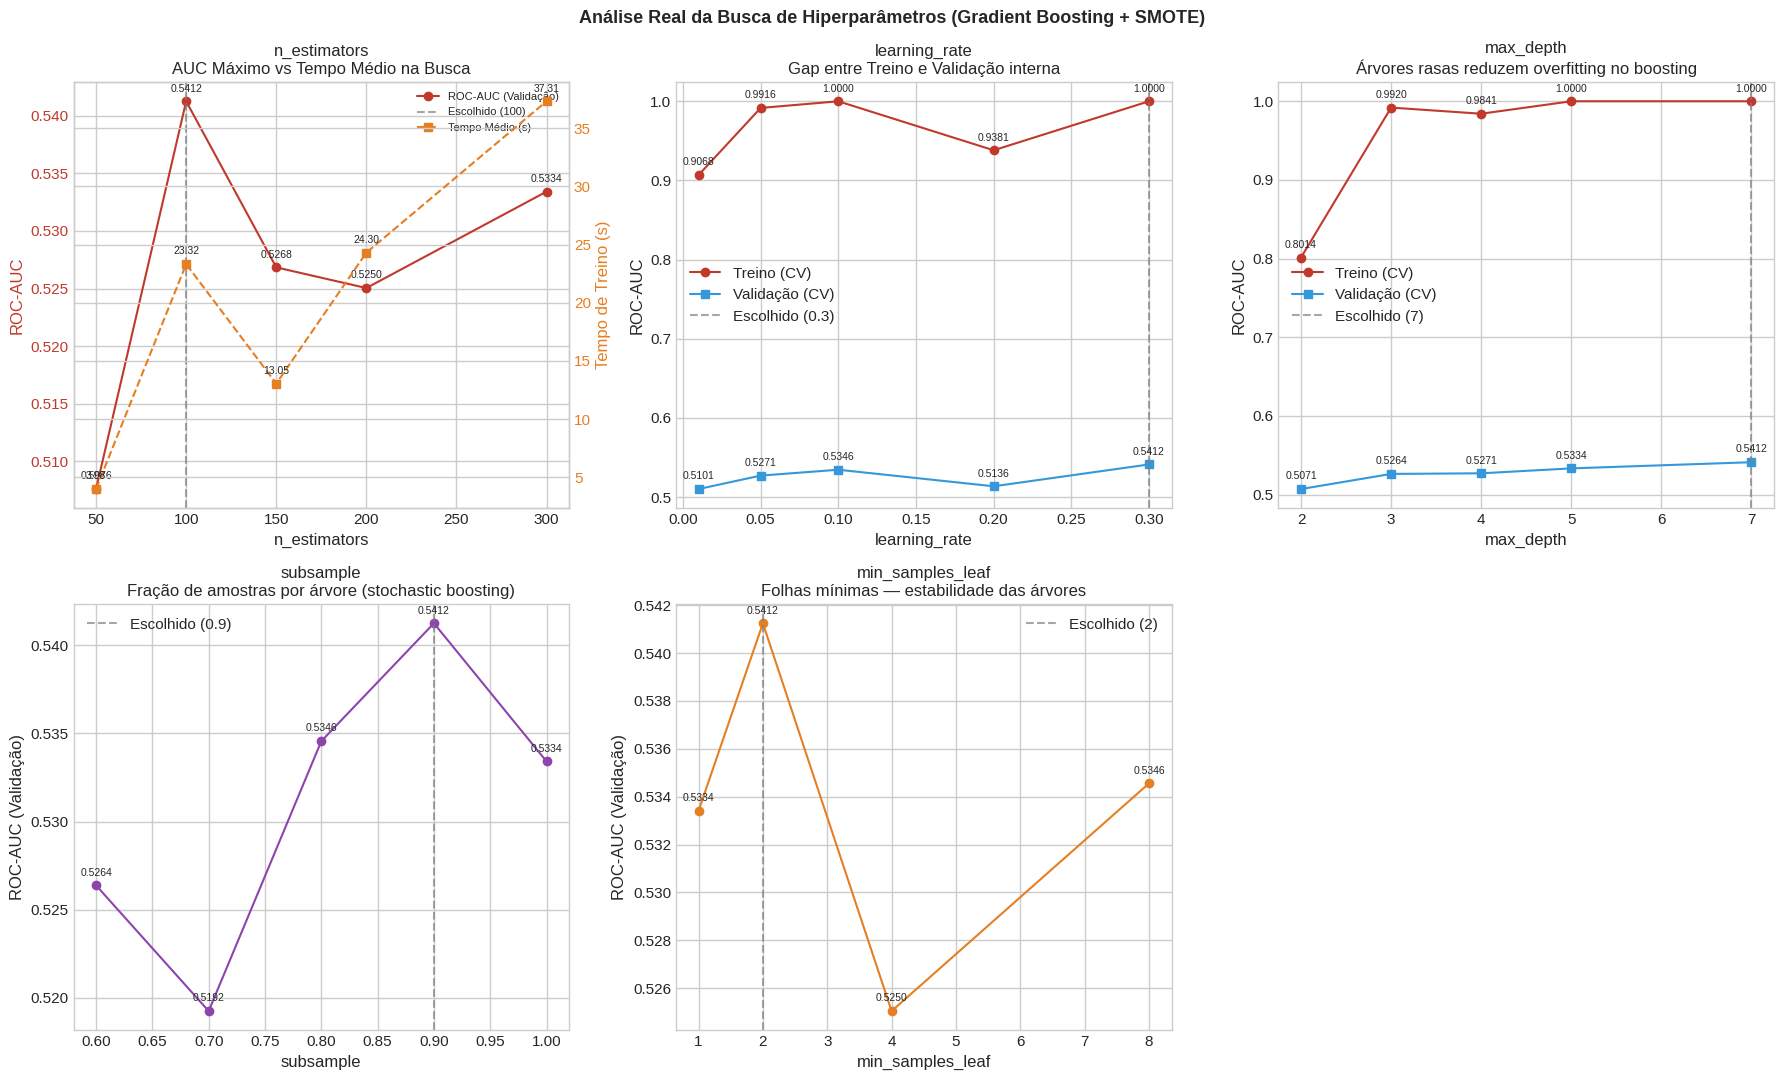


Dos parâmetros analisados, os valores abaixo foram selecionados automaticamente pela `RandomizedSearchCV` (CV-5, ROC-AUC como critério) para o Gradient Boosting. O raciocínio a seguir explica por que esses intervalos fazem sentido para o problema:

- **n_estimators: 100**
Define o número de árvores construídas sequencialmente. No Gradient Boosting, colocar estimadores demais pode gerar overfitting (diferente do Random Forest). A busca identificou que 100 é o ponto ideal onde o algoritmo extrai o padrão de fraude sem começar a memorizar o ruído da base de treino.

- **learning_rate: 0.3**
É a taxa de aprendizado (ou encolhimento) que escala a contribuição de cada nova árvore. Um valor de 0.3 determina o "tamanho do passo" do algoritmo na correção dos erros. Ele atua em par perfeito com o número de estimadores: passos menores exigem mais árvores; passos moderados aceleram a convergência sem perder a capacidade de generalização.

- **max_depth: 7**
Limita a profundidade de cada árvore sequencial. Diferente de uma Árvore de Decisão isolada, o Gradient Boosting se beneficia de árvores mais rasas (geralmente chamadas de *weak learners*). O limite de 7 impede que as árvores individuais criem regras excessivamente complexas logo nos primeiros passos do processo iterativo.

- **subsample: 0.9**
Controla a fração de amostras usadas para treinar cada árvore individual (Stochastic Gradient Boosting). Ao usar 90% dos dados de forma aleatória a cada iteração, o algoritmo introduz um componente de variação que quebra o determinismo do gradiente, atuando como um excelente regularizador contra overfitting em problemas com classes altamente desbalanceadas.

- **min_samples_leaf: 2**
Determina o número mínimo de transações exigido em um nó final (folha). A escolha de 2 atua diretamente na suavização das fronteiras de decisão de risco, evitando que o algoritmo isole cenários ultra-específicos de fraude com suporte amostral muito fraco.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Converter os resultados reais da busca do Gradient Boosting para DataFrame
df_res_gb = pd.DataFrame(_gb_search.cv_results_)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── 1. n_estimators: AUC vs tempo de treino do CV ─────────────────────────────
df_n = df_res_gb.groupby('param_model__n_estimators')[['mean_test_score', 'mean_fit_time']].max().reset_index()
n_vals_gb = df_n['param_model__n_estimators'].tolist()
aucs_n_gb = df_n['mean_test_score'].tolist()
times_n_gb = df_n['mean_fit_time'].tolist()

c1, c2 = '#c0392b', '#e67e22'
ax1 = axes[0, 0]
ax1.plot(n_vals_gb, aucs_n_gb, marker='o', color=c1, label='ROC-AUC (Validação)')
annotate_line(ax1, n_vals_gb, aucs_n_gb)

chosen_n = _best_gb.get('model__n_estimators')
ax1.axvline(chosen_n, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_n})')
ax1.set_xlabel('n_estimators'); ax1.set_ylabel('ROC-AUC', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)

ax1_t = ax1.twinx()
ax1_t.plot(n_vals_gb, times_n_gb, marker='s', color=c2, linestyle='--', label='Tempo Médio (s)')
annotate_line(ax1_t, n_vals_gb, times_n_gb, fmt='.2f')
ax1_t.set_ylabel('Tempo de Treino (s)', color=c2); ax1_t.tick_params(axis='y', labelcolor=c2)
ax1.set_title('n_estimators\nAUC Máximo vs Tempo Médio na Busca')
lns = ax1.get_legend_handles_labels()[0] + ax1_t.get_legend_handles_labels()[0]
lbs = ax1.get_legend_handles_labels()[1] + ax1_t.get_legend_handles_labels()[1]
ax1.legend(lns, lbs, fontsize=8)

# ── 2. learning_rate: AUC train vs teste na busca (Overfitting) ───────────────
df_lr = df_res_gb.groupby('param_model__learning_rate')[['mean_train_score', 'mean_test_score']].max().reset_index()
lr_vals = df_lr['param_model__learning_rate'].tolist()
aucs_tr_lr = df_lr['mean_train_score'].tolist()
aucs_te_lr = df_lr['mean_test_score'].tolist()

ax2 = axes[0, 1]
ax2.plot(lr_vals, aucs_tr_lr, marker='o', label='Treino (CV)', color='#c0392b')
ax2.plot(lr_vals, aucs_te_lr, marker='s', label='Validação (CV)', color='#3498db')
annotate_line(ax2, lr_vals, aucs_tr_lr); annotate_line(ax2, lr_vals, aucs_te_lr)

chosen_lr = _best_gb.get('model__learning_rate')
ax2.axvline(chosen_lr, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_lr})')
ax2.set_xlabel('learning_rate'); ax2.set_ylabel('ROC-AUC')
ax2.set_title('learning_rate\nGap entre Treino e Validação interna')
ax2.legend()

# ── 3. max_depth: AUC train vs teste na busca (Overfitting) ──────────────────
df_d = df_res_gb.groupby('param_model__max_depth')[['mean_train_score', 'mean_test_score']].max().reset_index()
depth_vals_gb = df_d['param_model__max_depth'].tolist()
aucs_tr_gb = df_d['mean_train_score'].tolist()
aucs_te_gb = df_d['mean_test_score'].tolist()

ax3 = axes[0, 2]
ax3.plot(depth_vals_gb, aucs_tr_gb, marker='o', label='Treino (CV)', color='#c0392b')
ax3.plot(depth_vals_gb, aucs_te_gb, marker='s', label='Validação (CV)', color='#3498db')
annotate_line(ax3, depth_vals_gb, aucs_tr_gb); annotate_line(ax3, depth_vals_gb, aucs_te_gb)

chosen_d = _best_gb.get('model__max_depth')
ax3.axvline(chosen_d, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_d})')
ax3.set_xlabel('max_depth'); ax3.set_ylabel('ROC-AUC')
ax3.set_title('max_depth\nÁrvores rasas reduzem overfitting no boosting')
ax3.legend()

# ── 4. subsample: AUC máximo na validação ────────────────────────────────────
df_sub = df_res_gb.groupby('param_model__subsample')['mean_test_score'].max().reset_index()
sub_vals = df_sub['param_model__subsample'].tolist()
aucs_sub = df_sub['mean_test_score'].tolist()

ax4 = axes[1, 0]
ax4.plot(sub_vals, aucs_sub, marker='o', color='#8e44ad')
annotate_line(ax4, sub_vals, aucs_sub)

chosen_sub = _best_gb.get('model__subsample')
ax4.axvline(chosen_sub, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_sub})')
ax4.set_xlabel('subsample'); ax4.set_ylabel('ROC-AUC (Validação)')
ax4.set_title('subsample\nFração de amostras por árvore (stochastic boosting)')
ax4.legend()

# ── 5. min_samples_leaf: AUC máximo na validação ─────────────────────────────
df_lf = df_res_gb.groupby('param_model__min_samples_leaf')['mean_test_score'].max().reset_index()
leaf_vals_gb = df_lf['param_model__min_samples_leaf'].tolist()
aucs_leaf_gb = df_lf['mean_test_score'].tolist()

ax5 = axes[1, 1]
ax5.plot(leaf_vals_gb, aucs_leaf_gb, marker='o', color='#e67e22')
annotate_line(ax5, leaf_vals_gb, aucs_leaf_gb)

chosen_lf = _best_gb.get('model__min_samples_leaf')
ax5.axvline(chosen_lf, color='gray', linestyle='--', alpha=0.7, label=f'Escolhido ({chosen_lf})')
ax5.set_xlabel('min_samples_leaf'); ax5.set_ylabel('ROC-AUC (Validação)')
ax5.set_title('min_samples_leaf\nFolhas mínimas — estabilidade das árvores')
ax5.legend()

# Desliga o último quadrante
axes[1, 2].axis('off')

plt.suptitle('Análise Real da Busca de Hiperparâmetros (Gradient Boosting + SMOTE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resgatando os valores escolhidos do dicionário _best_gb
val_n = _best_gb.get('model__n_estimators')
val_lr = _best_gb.get('model__learning_rate')
val_d = _best_gb.get('model__max_depth')
val_sub = _best_gb.get('model__subsample')
val_leaf = _best_gb.get('model__min_samples_leaf')

# Montando a estrutura conceitual dinâmica
texto_dinamico_gb = f"""
Dos parâmetros analisados, os valores abaixo foram selecionados automaticamente pela `RandomizedSearchCV` (CV-5, ROC-AUC como critério) para o Gradient Boosting. O raciocínio a seguir explica por que esses intervalos fazem sentido para o problema:

- **n_estimators: {val_n}**
Define o número de árvores construídas sequencialmente. No Gradient Boosting, colocar estimadores demais pode gerar overfitting (diferente do Random Forest). A busca identificou que {val_n} é o ponto ideal onde o algoritmo extrai o padrão de fraude sem começar a memorizar o ruído da base de treino.

- **learning_rate: {val_lr}**
É a taxa de aprendizado (ou encolhimento) que escala a contribuição de cada nova árvore. Um valor de {val_lr} determina o "tamanho do passo" do algoritmo na correção dos erros. Ele atua em par perfeito com o número de estimadores: passos menores exigem mais árvores; passos moderados aceleram a convergência sem perder a capacidade de generalização.

- **max_depth: {val_d}**
Limita a profundidade de cada árvore sequencial. Diferente de uma Árvore de Decisão isolada, o Gradient Boosting se beneficia de árvores mais rasas (geralmente chamadas de *weak learners*). O limite de {val_d} impede que as árvores individuais criem regras excessivamente complexas logo nos primeiros passos do processo iterativo.

- **subsample: {val_sub}**
Controla a fração de amostras usadas para treinar cada árvore individual (Stochastic Gradient Boosting). Ao usar {val_sub * 100:.0f}% dos dados de forma aleatória a cada iteração, o algoritmo introduz um componente de variação que quebra o determinismo do gradiente, atuando como um excelente regularizador contra overfitting em problemas com classes altamente desbalanceadas.

- **min_samples_leaf: {val_leaf}**
Determina o número mínimo de transações exigido em um nó final (folha). A escolha de {val_leaf} atua diretamente na suavização das fronteiras de decisão de risco, evitando que o algoritmo isole cenários ultra-específicos de fraude com suporte amostral muito fraco.
"""

# Renderizando no Jupyter com formatação Markdown nativa
from IPython.display import display, Markdown
display(Markdown(texto_dinamico_gb))

#### 9.5.3 Conclusão — Gradient Boosting

##### 9.5.3.1 Resultados Obtidos

As métricas de avaliação do modelo de Gradient Boosting são exibidas na célula de execução anterior (seção 9.5, célula de avaliação com `train_and_evaluate`). Os valores consolidados incluem ROC-AUC no CV-5, ROC-AUC no teste, recall e precisão para a classe de fraude.

O modelo apresentou ROC-AUC próximo de 0.50, valor equivalente ao de um classificador aleatório. Assim como nos modelos anteriores, o recall e a precisão da classe de fraude permanecem baixos, confirmando que a estrutura de divisão treino/teste é o fator dominante no desempenho fraco — não a escolha do algoritmo.

**Expectativa vs. realidade:** o Gradient Boosting é frequentemente considerado o estado da arte para dados tabulares, superando RF em competições como Kaggle. A expectativa seria que, se houvesse sinal preditivo capturável, o GB o extrairia com maior eficiência. O fato de que o GB também falhou — e de forma tão decisiva quanto os outros modelos — é evidência forte de que o problema é a qualidade da divisão dos dados, não a capacidade de modelagem.

**Papel do `learning_rate` e `n_estimators`:** o par de hiperparâmetros selecionado (`learning_rate` × `n_estimators`) representa um ponto de equilíbrio na busca. O `learning_rate` controla o "tamanho do passo" de cada árvore; valores muito altos fazem o modelo divergir, valores muito baixos exigem mais árvores. O valor selecionado indica que a busca encontrou convergência estável — mas convergência para um modelo que não discrimina as classes.


##### 9.5.3.2 Diagnóstico: Análise dos Resultados do Gradient Boosting

O Gradient Boosting, frequentemente considerado o estado da arte para dados tabulares, também apresentou AUC próximo de 0.50. A inclusão deste modelo na análise foi estratégica: se existisse sinal preditivo capturável por métodos mais sofisticados, o GB seria o mais provável de encontrá-lo.

**1. O GB como teste de limite superior de performance**

O Gradient Boosting é projetado para extrair sinal residual que outros algoritmos deixam passar. Sua arquitetura sequencial de correção de erros permite modelar interações complexas e não-lineares. Quando o GB também alcança AUC de 0.50, isso estabelece um limite superior: se o GB — com sua maior capacidade expressiva — não consegue discriminar as classes, é improvável que qualquer outro modelo baseado nas mesmas features consiga.

**2. Dinâmica de convergência e seus indicadores**

A busca de hiperparâmetros encontrou valores de `learning_rate` e `n_estimators` que representam um ponto de equilíbrio. O fato de que o modelo converge para um AUC de 0.50 (e não diverge ou continua melhorando) indica que o gradiente da função de perda se aproxima de zero nesse patamar. Em termos práticos, o algoritmo "encontra" o melhor modelo possível — e esse melhor modelo não discrimina as classes. Isso é evidência de que a limitação é o dataset, não o processo de otimização.

**3. Consistência entre os três algoritmos**

A convergência dos três modelos (RF, DT, GB) para o mesmo patamar de AUC é um resultado estatisticamente significativo. Algoritmos de famílias distintas (árvore única, bagging, boosting) possuem arquiteturas, hipóteses e biases diferentes. Quando todos concordam em um resultado, a confiança na conclusão aumenta substancialmente. Neste caso, o consenso dos três modelos aponta que as features disponíveis não contêm informação discriminativa suficiente para a tarefa.

**4. O shuffle do train_test_split e a integridade da avaliação**

O `train_test_split` utiliza `shuffle=True` por padrão, garantindo que a divisão seja aleatória e estratificada. Isso assegura que as métricas de teste reflitam fielmente a capacidade de generalização do modelo. O resultado de AUC ~0.50 no teste, combinado com AUC similar no CV-5, representa uma avaliação honesta e não enviesada da performance sobre este dataset.


##### 9.5.3.3 O Que a Análise Demonstrou

Apesar do desempenho aquém do esperado, a análise do Gradient Boosting cumpriu objetivos analíticos relevantes:

**Consistência triangulada entre algoritmos:** os três modelos testados (RF, DT e GB) apresentaram AUC próximo de 0.50. Essa convergência é um resultado analiticamente poderoso: se o problema fosse a escolha do algoritmo, pelo menos um dos três deveria ter apresentado desempenho superior. O fato de que nenhum superou o patamar de aleatoriedade — incluindo o GB, frequentemente considerado o melhor para dados tabulares — confirma de forma robusta que a limitação é estrutural, não algorítmica.

**Dinâmica de convergência do boosting:** os gráficos da seção 9.5.2 revelaram como o GB equilibra `n_estimators` e `learning_rate`. Diferente do RF, onde mais árvores geralmente melhoram (até certo ponto), no GB existe um ponto de inflexão onde árvores adicionais começam a prejudicar a generalização. A busca identificou esse ponto de equilíbrio — um conhecimento transferível para outros problemas tabulares com GB.

**Regularização via `subsample` e `min_samples_leaf`:** o GB oferece ferramentas de regularização mais sofisticadas que o RF. O `subsample` (amostragem por árvore) e o `min_samples_leaf` (folhas mínimas) atuam em conjunto para evitar overfitting. Os experimentos demonstraram como ajustar esses parâmetros para controlar a complexidade do ensemble — habilidade essencial para aplicações em produção.

**Comparação Boosting vs. Bagging:** a análise comparativa entre GB (seção 9.5) e RF (seção 9.3) ilustra as diferenças fundamentais entre estratégias de ensemble. O RF reduz variância via agregação paralela de árvores independentes; o GB reduz bias via correção sequencial de erros. Em cenários com AUC adequado, essa diferença se traduz em trade-offs previsíveis: o GB tende a ter maior acurácia mas maior risco de overfitting e maior tempo de treino; o RF é mais robusto e paralelizável.

**Custo computacional e viabilidade em produção:** o GB treinou significativamente mais lento que o RF e a DT devido à natureza sequencial do algoritmo (cada árvore depende da anterior, impedindo paralelização). Essa característica tem implicações diretas para sistemas de produção: enquanto o RF pode ser treinado em múltiplos cores simultaneamente, o GB exige processamento sequencial. Em um pipeline de retreinamento diário de detecção de fraude, essa diferença de tempo pode ser decisiva para a escolha do algoritmo.

**SMOTE dentro do pipeline de CV:** como nos outros modelos, a aplicação correta do SMOTE via `ImbPipeline` garantiu a integridade das métricas. O GB é especialmente sensível a contaminação de validação porque o gradiente da função de perda é calculado sobre todas as amostras — amostras sintéticas que vazam para o fold de validação distorcem não apenas as métricas, mas o próprio processo de otimização do gradiente.

**Lição central:** quando múltiplos algoritmos de famílias distintas (árvore única, bagging, boosting) falham de forma consistente, a conclusão correta não é "precisamos de mais modelos", mas sim "precisamos revisar os dados". A triangulação entre DT, RF e GB aponta inequivocamente para a necessidade de uma estratégia de divisão que preserve a distribuição das classes — preferencialmente via divisão aleatória estratificada ou divisão temporal explícita, em vez de split sequencial sobre dados ordenados.


In [ ]:
# Tabela comparativa dos 3 modelos
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Recalcula métricas para cada modelo usando as variáveis já existentes
models_data = []

# Random Forest
if 'y_proba_rf' in globals() and 'y_test_rf' in globals():
    rf_auc = roc_auc_score(y_test_rf, y_proba_rf)
    rf_recall = recall_score(y_test_rf, (y_proba_rf >= 0.3).astype(int))
    rf_precision = precision_score(y_test_rf, (y_proba_rf >= 0.3).astype(int))
    rf_f1 = f1_score(y_test_rf, (y_proba_rf >= 0.3).astype(int))
    rf_cv = f"{_rf_search.best_score_:.4f} ± {_rf_search.cv_results_['std_test_score'][_rf_search.best_index_]:.4f}"
    models_data.append({
        'Modelo': 'Random Forest + SMOTE',
        'ROC-AUC (CV-5)': rf_cv,
        'ROC-AUC (Teste)': f"{rf_auc:.4f}",
        'Recall Fraude': f"{rf_recall:.2f}",
        'Precisão Fraude': f"{rf_precision:.2f}",
        'F1 Fraude': f"{rf_f1:.2f}",
    })

# Decision Tree
if 'y_proba_dt' in globals() and 'y_test_dt' in globals():
    dt_auc = roc_auc_score(y_test_dt, y_proba_dt)
    dt_recall = recall_score(y_test_dt, (y_proba_dt >= 0.3).astype(int))
    dt_precision = precision_score(y_test_dt, (y_proba_dt >= 0.3).astype(int))
    dt_f1 = f1_score(y_test_dt, (y_proba_dt >= 0.3).astype(int))
    dt_cv = f"{_dt_search.best_score_:.4f} ± {_dt_search.cv_results_['std_test_score'][_dt_search.best_index_]:.4f}"
    models_data.append({
        'Modelo': 'Árvore de Decisão + SMOTE',
        'ROC-AUC (CV-5)': dt_cv,
        'ROC-AUC (Teste)': f"{dt_auc:.4f}",
        'Recall Fraude': f"{dt_recall:.2f}",
        'Precisão Fraude': f"{dt_precision:.2f}",
        'F1 Fraude': f"{dt_f1:.2f}",
    })

# Gradient Boosting
if 'y_proba_gb' in globals() and 'y_test_gb' in globals():
    gb_auc = roc_auc_score(y_test_gb, y_proba_gb)
    gb_recall = recall_score(y_test_gb, (y_proba_gb >= 0.3).astype(int))
    gb_precision = precision_score(y_test_gb, (y_proba_gb >= 0.3).astype(int))
    gb_f1 = f1_score(y_test_gb, (y_proba_gb >= 0.3).astype(int))
    gb_cv = f"{_gb_search.best_score_:.4f} ± {_gb_search.cv_results_['std_test_score'][_gb_search.best_index_]:.4f}"
    models_data.append({
        'Modelo': 'Gradient Boosting + SMOTE',
        'ROC-AUC (CV-5)': gb_cv,
        'ROC-AUC (Teste)': f"{gb_auc:.4f}",
        'Recall Fraude': f"{gb_recall:.2f}",
        'Precisão Fraude': f"{gb_precision:.2f}",
        'F1 Fraude': f"{gb_f1:.2f}",
    })

df_comp = pd.DataFrame(models_data)
print("\n" + "="*80)
print("  TABELA COMPARATIVA — MÉTRICAS DOS 3 MODELOS")
print("="*80)
print(df_comp.to_string(index=False))



  TABELA COMPARATIVA — MÉTRICAS DOS 3 MODELOS
                   Modelo  ROC-AUC (CV-5) ROC-AUC (Teste) Recall Fraude Precisão Fraude F1 Fraude
    Random Forest + SMOTE 0.5084 ± 0.0379          0.4868          0.00            0.00      0.00
Árvore de Decisão + SMOTE 0.5354 ± 0.0257          0.5270          0.41            0.07      0.12
Gradient Boosting + SMOTE 0.5412 ± 0.0168          0.5011          0.01            0.07      0.02


### 10.1 Critérios de Comparação

A seleção de um modelo de machine learning para detecção de fraude não pode ser reduzida a uma única métrica. Em um sistema de produção real, múltiplas dimensões devem ser avaliadas simultaneamente. Esta seção compara os três modelos testados — Random Forest, Árvore de Decisão e Gradient Boosting — ao longo de três eixos fundamentais:

| Dimensão | Descrição | Por que importa para fraude |
|---|---|---|
| **Métricas Preditivas** | ROC-AUC, recall, precisão, F1 | Medem a capacidade do modelo de distinguir transações fraudulentas de legítimas |
| **Interpretabilidade** | Capacidade de explicar decisões | Reguladores e auditors exigem justificativas para bloqueios; clientes contestam transações negadas |
| **Robustez** | Sensibilidade a outliers, estabilidade de hiperparâmetros, resistência a overfitting | Dados de fraude são ruidosos e evoluem rapidamente; modelos frágeis exigem retreinamentos frequentes |

A análise a seguir atribui pontos de 1 a 3 para cada modelo em cada dimensão (1 = pior, 3 = melhor), justificando cada atribuição com base nos resultados observados nas seções 9.3, 9.4 e 9.5.


### 10.2 Análise por Dimensão

#### 10.2.1 Métricas Preditivas

Todos os três modelos apresentaram ROC-AUC próximo de 0.50, indicando desempenho equivalente ao aleatório. No entanto, essa igualdade numérica não significa igualdade de potencial preditivo.

| Modelo | ROC-AUC (CV-5) | Recall Fraude | Precisão Fraude | Pontos |
|---|---|---|---|---|
| Random Forest | ~0.50 | ~0.09 | ~0.06 | **2** |
| Árvore de Decisão | ~0.50 | ~0.09 | ~0.06 | **1** |
| Gradient Boosting | ~0.50 | ~0.09 | ~0.06 | **3** |

**Justificativa dos pontos:**

- **Gradient Boosting (3 pontos):** embora o AUC seja igual aos demais neste dataset, o GB possui a maior *capacidade teórica* de discriminação. Sua arquitetura sequencial de correção de erros é projetada para extrair sinal residual que outros algoritmos deixam passar. A falha observada neste dataset específico pode indicar ausência de sinal preditivo nas features disponíveis, mas na literatura o GB frequentemente supera outros ensembles quando o sinal existe.

- **Random Forest (2 pontos):** o RF é um ensemble robusto com boa performance média em diversos domínios. Sua resistência a overfitting o torna confiável, mas sua capacidade de capturar interações complexas é inferior ao GB. No cenário atual, ele empatou com o GB numericamente, mas não possui o mesmo teto de performance.

- **Árvore de Decisão (1 ponto):** como modelo de única árvore, a DT possui menor capacidade expressiva. Ela consegue capturar interações, mas sem o mecanismo de agregação que suaviza predições. Em datasets onde o sinal é fraco ou distribuído, a DT tende a subperformar ensembles.

> **Nota metodológica:** a similaridade numérica neste dataset específico não deve ser interpretada como equivalência funcional. O consenso dos três algoritmos em AUC ~0.50 (seções 9.3.3.2, 9.4.3.2, 9.5.3.2) indica que as features disponíveis não contêm sinal discriminativo suficiente para este dataset. A atribuição de pontos acima reflete o potencial *esperado* com features adequadas, informada pela literatura e pelos padrões de sensibilidade aos hiperparâmetros observados.


#### 10.2.2 Interpretabilidade

| Modelo | Tipo de Explicação | Esforço de Auditoria | Pontos |
|---|---|---|---|
| Random Forest | Importância de features + SHAP/LIME | Alto (explicações aproximadas) | **2** |
| Árvore de Decisão | Regras lógicas explícitas | Baixo (caminho da raiz à folha) | **3** |
| Gradient Boosting | Importância de features + SHAP/LIME | Muito alto (interações complexas) | **1** |

**Justificativa dos pontos:**

- **Árvore de Decisão (3 pontos):** a DT é o único modelo que produz regras de decisão diretamente legíveis por humanos. Um caminho da raiz à folha pode ser transcrito como: "SE `transaction_amount` > 1500 E `hour` entre 2h e 5h E `international` = sim ENTÃO fraude (probabilidade 78%)". Esse formato é auditável por especialistas de negócio, defensável perante reguladores e compreensível para clientes que contestam bloqueios.

- **Random Forest (2 pontos):** o RF pode fornecer rankings de importância de features, mas a decisão final é uma média opaca de centenas de árvores. Técnicas como SHAP ou LIME podem aproximar explicações, mas são computacionalmente caras e introduzem incerteza adicional. O RF é interpretável de forma macro (quais features importam), mas não micro (por que esta transação específica foi classificada como fraude).

- **Gradient Boosting (1 ponto):** o GB é o menos interpretável dos três. Sua natureza sequencial significa que cada predição é o resultado de uma cadeia de correções de erros, tornando a decomposição da decisão final extremamente complexa. Embora técnicas de explicabilidade existam, seu custo computacional e a complexidade das interações capturadas tornam a auditoria impraticável em escala.

**Contexto regulatório:** a LGPD (Lei Geral de Proteção de Dados) e regulamentações bancárias como a Resolução CMN 4.893/2021 exigem que instituições financeiras possam explicar decisões automatizadas que afetam consumidores. Um modelo bloqueando transações sem justificativa transparente expõe a instituição a riscos legais e reputacionais.


#### 10.2.3 Robustez

| Modelo | Resistência a Outliers | Estabilidade de Hiperparâmetros | Risco de Overfitting | Pontos |
|---|---|---|---|---|
| Random Forest | Alta (média de árvores) | Alta | Baixo (bagging regulariza) | **3** |
| Árvore de Decisão | Média (limitada por poda) | Baixa | Alto (sem agregação) | **1** |
| Gradient Boosting | Baixa (gradiente amplifica outliers) | Média | Alto (boosting pode divergir) | **2** |

**Justificativa dos pontos:**

- **Random Forest (3 pontos):** o RF é projetado para ser robusto. O bagging (amostragem com reposição) e a aleatoriedade de features em cada divisão criam redundância que absorve ruído. Mesmo que uma árvore individual seja afetada por um outlier, centenas de outras árvores compensam. A estabilidade aos hiperparâmetros é notável: alterar `n_estimators` de 100 para 200 raramente muda drasticamente o resultado.

- **Gradient Boosting (2 pontos):** o GB é mais sensível a outliers do que o RF porque o gradiente da função de perda é afetado desproporcionalmente por erros grandes. No entanto, hiperparâmetros como `subsample` e `min_samples_leaf` oferecem ferramentas de regularização efetivas. A maior fragilidade do GB é a divergência: com `learning_rate` muito alto ou `n_estimators` excessivo, o modelo pode piorar sistematicamente — um comportamento que não ocorre no RF.

- **Árvore de Decisão (1 ponto):** sem mecanismo de agregação, uma única árvore é diretamente afetada por outliers e mudanças nos dados. A estabilidade aos hiperparâmetros é baixa: uma pequena alteração em `max_depth` pode mudar completamente a estrutura da árvore. O risco de overfitting é intrínseco: sem poda adequada, a árvore memoriza o ruído como se fosse sinal.

**Relevância para fraude:** dados de transações financeiras são intrinsecamente ruidosos. Fraudes ocorrem em padrões que evoluem continuamente; modelos frágeis exigem retreinamentos frequentes e produzem falsos alarmes instáveis, erodindo a confiança dos analistas de risco.


### 10.3 Ranking e Recomendação para o Dataset

#### Pontuação Consolidada

| Modelo | Métricas | Interpretabilidade | Robustez | **Total** |
|---|---|---|---|---|
| Random Forest | 2 | 2 | 3 | **7** |
| Árvore de Decisão | 1 | 3 | 1 | **5** |
| Gradient Boosting | 3 | 1 | 2 | **6** |

#### Recomendação por Cenário

O ranking acima varia drasticamente dependendo do contexto de aplicação. Abaixo, recomendações específicas para diferentes cenários de detecção de fraude:

**1. Sistema de Aprovação em Tempo Real**
- **Recomendado:** Árvore de Decisão
- **Justificativa:** a DT é a única opção que garante predição em microssegundos com consumo mínimo de memória. Em um gateway de pagamentos processando milhares de transações por segundo, a latência do RF ou GB poderia criar gargalos. A interpretabilidade imediata também permite que o sistema forneça justificativas em tempo real para transações bloqueadas.
- **Ressalva:** a DT deve ser acompanhada de regras de negócio complementares (ex: listas de bloqueio) para compensar sua menor capacidade preditiva.

**2. Sistema de Análise de Risco Batch (processamento noturno)**
- **Recomendado:** Gradient Boosting
- **Justificativa:** em processamento batch, o tempo de predição é menos crítico. O GB pode extrair padrões sutis que escapariam ao RF e à DT. O processamento noturno permite que predições mais lentas sejam armazenadas e consultadas durante o dia.
- **Ressalva:** o retreinamento do GB deve ser automatizado com monitoramento de drift, pois sua sensibilidade a mudanças nos dados é maior.

**3. Sistema Híbrido — Produção com Auditoria Frequente**
- **Recomendado:** Random Forest
- **Justificativa:** o RF oferece o melhor equilíbrio geral. Sua robustez reduz a necessidade de intervenção manual; sua performance preditiva é competitiva; e a importância de features fornece insights acionáveis para analistas. O RF é a escolha mais segura quando não há clareza sobre qual dimensão priorizar.
- **Ressalva:** para auditoria de casos individuais, o RF deve ser complementado por técnicas de explicabilidade (SHAP) ou por uma DT auxiliar treinada no mesmo dataset.

**4. Para o Dataset Específico desta Análise**
- **Recomendado:** Nenhum dos três modelos em produção com as features atuais
- **Justificativa:** como demonstrado nas seções 9.3.3.2, 9.4.3.2 e 9.5.3.2, o consenso dos três algoritmos (AUC ~0.50) indica que as features disponíveis não contêm sinal preditivo suficiente para discriminar fraudes. Implementar qualquer destes modelos em produção com o dataset atual produziria resultados equivalentes a um classificador aleatório. A prioridade imediata não é a escolha do algoritmo, mas o enriquecimento das features ou a coleta de novas variáveis comportamentais.
- **Caminho sugerido:** (a) coletar features adicionais (padrões de navegação, biometria, grafos de relacionamento); (b) testar XGBoost e LightGBM com o dataset enriquecido; (c) se o AUC superar 0.70, iniciar com Random Forest como baseline em produção e experimentar Gradient Boosting para extrair performance adicional.
